/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


Paths OK

--- Phase 1: Select subset (train-only history) ---
Selected families: ['GROCERY I', 'BEVERAGES', 'CLEANING', 'DAIRY', 'PRODUCE']
Selected stores: [44]
Selected items: 200

--- Phase 2: Load subset daily sales/promo (chunked) ---
Auto START_DT (from subset) = 2013-01-02
END_DATE requested=2017-08-16 | factual_max=2017-08-15 | using END_DATE=2017-08-15
Using cuts: 2017-06-01 2017-08-01
Eval test range: 2017-06-01 to 2017-07-31

--- Phase 3: Build deterministic store-date features ---

--- Phase 4: Time-aware Target Encoding (by date, no same-day) ---

--- Phase 5: Build TRAIN dataset (H=1) ---
Train dataset: (322000, 81) | y: (322000,)

--- Phase 6-7: Train+Test each model (in order) ---

MODEL: Ridge(Linear)
Ridge(Linear) (train): RMSE(log)=0.525786 | MAE(log)=0.347514 | R2=0.8454
Ridge(Linear) (TEST strict recursive): RMSE(log)=0.647827 | MAE(log)=0.476904 | R2=0.6760
Ridge(Linear) (TEST strict recursive): MAE(sales)=20.6536 | RMSE(sales)=55.5842 | WAPE=0.4603


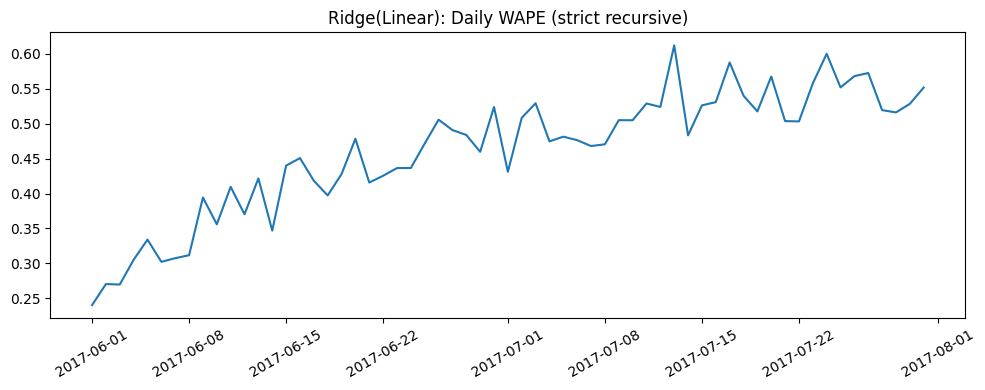

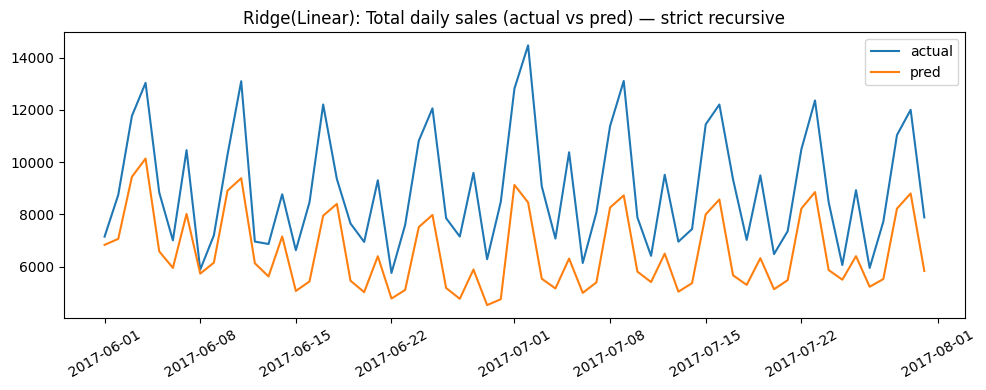


MODEL: GBT
GBT (train): RMSE(log)=0.413775 | MAE(log)=0.276236 | R2=0.9043
GBT (TEST strict recursive): RMSE(log)=0.594185 | MAE(log)=0.430693 | R2=0.7275
GBT (TEST strict recursive): MAE(sales)=16.0660 | RMSE(sales)=38.5833 | WAPE=0.3581


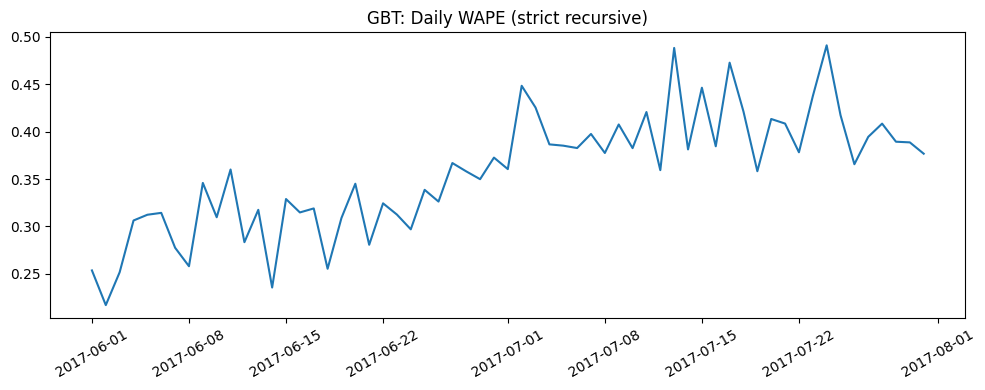

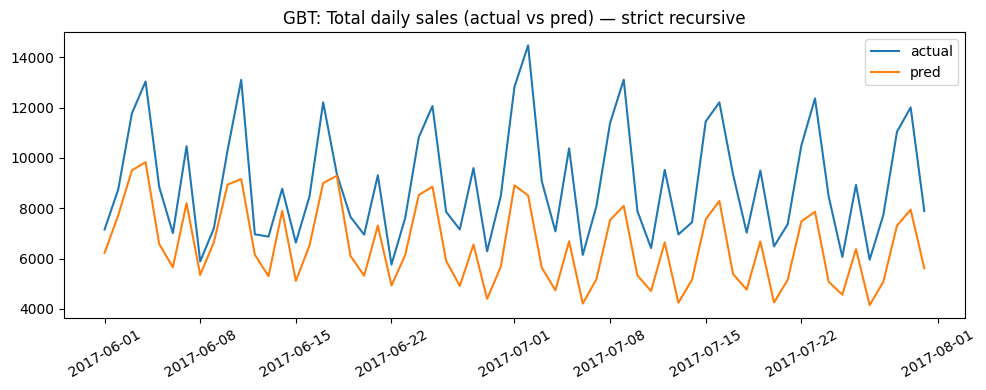


MODEL: RandomForest
RandomForest (train): RMSE(log)=0.467067 | MAE(log)=0.303321 | R2=0.8780
RandomForest (TEST strict recursive): RMSE(log)=0.607156 | MAE(log)=0.422156 | R2=0.7154
RandomForest (TEST strict recursive): MAE(sales)=15.1757 | RMSE(sales)=38.3189 | WAPE=0.3382


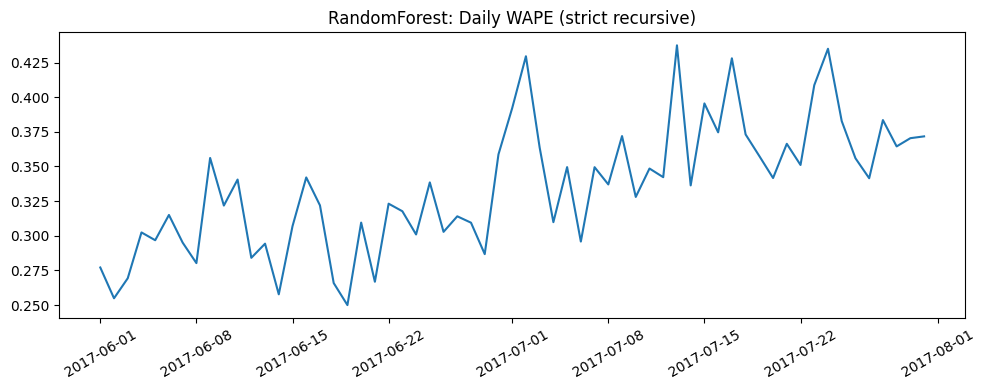

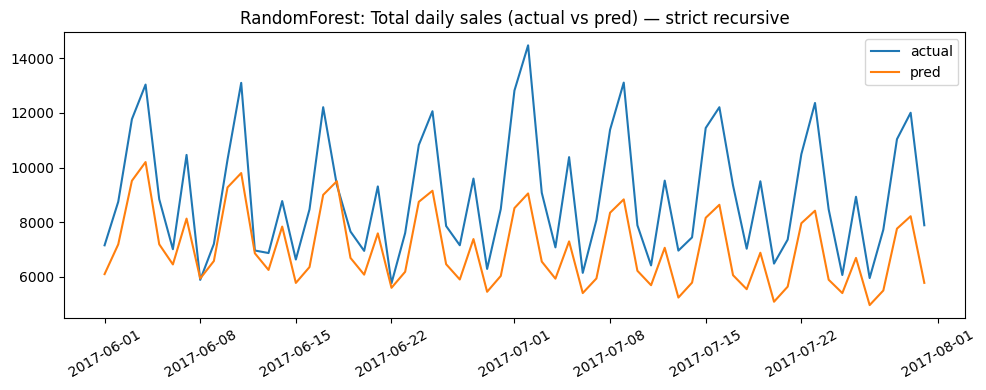


MODEL: XGBoost
XGBoost (train): RMSE(log)=0.390478 | MAE(log)=0.261329 | R2=0.9147
XGBoost (TEST strict recursive): RMSE(log)=0.611569 | MAE(log)=0.445839 | R2=0.7113
XGBoost (TEST strict recursive): MAE(sales)=15.1145 | RMSE(sales)=34.9754 | WAPE=0.3369


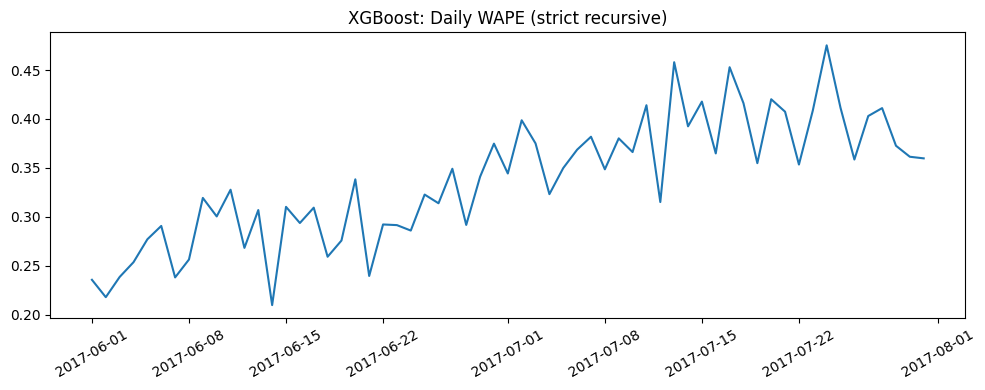

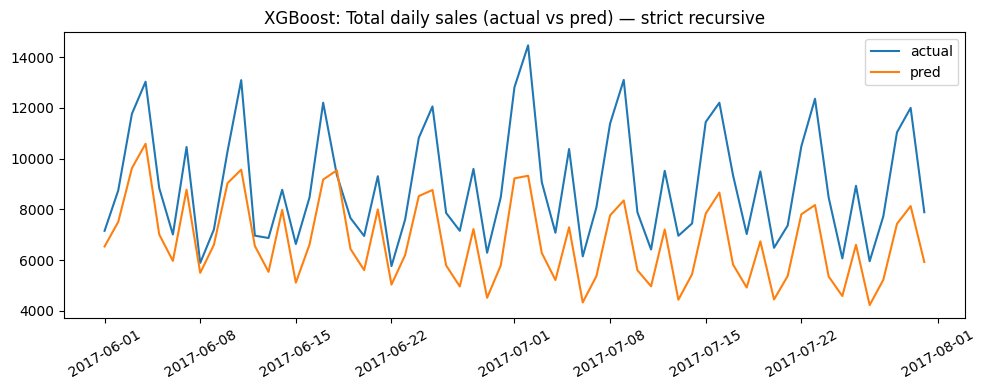


MODEL: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056273 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8892
[LightGBM] [Info] Number of data points in the train set: 322000, number of used features: 75
[LightGBM] [Info] Start training from score 2.949229
LightGBM (train): RMSE(log)=0.374791 | MAE(log)=0.250025 | R2=0.9214
LightGBM (TEST strict recursive): RMSE(log)=0.659183 | MAE(log)=0.499648 | R2=0.6646
LightGBM (TEST strict recursive): MAE(sales)=17.1526 | RMSE(sales)=39.6347 | WAPE=0.3823


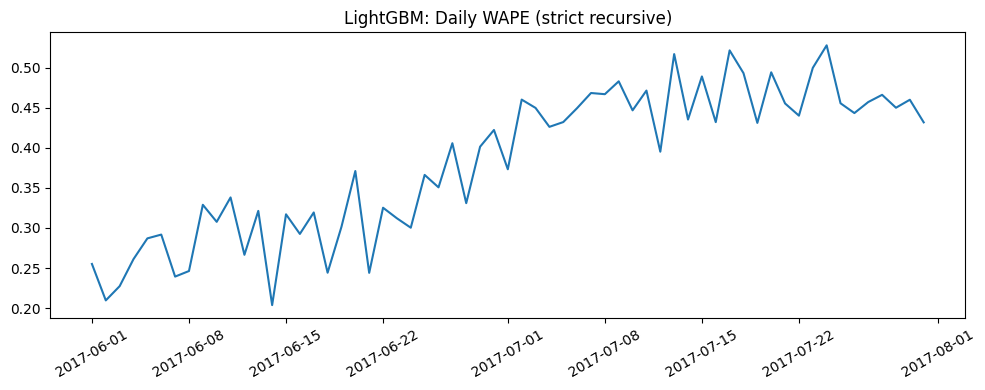

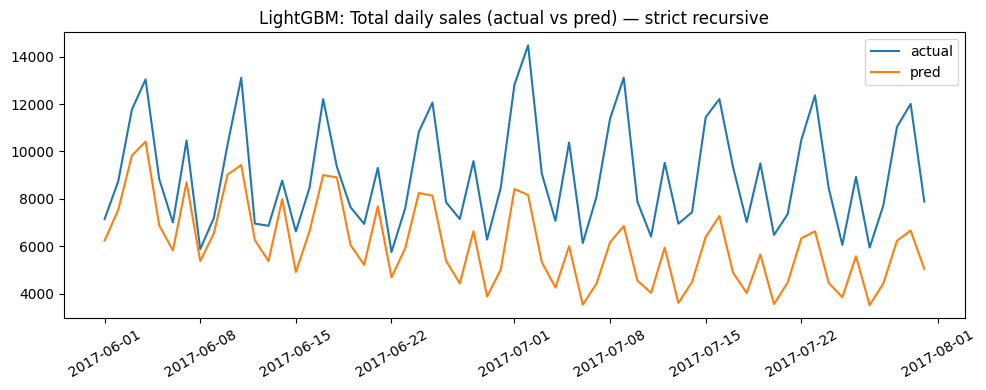


FINAL COMPARISON (STRICT TEST)
           model      rmse       mae        r2      wape
0            GBT  0.594185  0.430693  0.727468  0.358088
1   RandomForest  0.607156  0.422156  0.715440  0.338245
2        XGBoost  0.611569  0.445839  0.711288  0.336882
3  Ridge(Linear)  0.647827  0.476904  0.676040  0.460341
4       LightGBM  0.659183  0.499648  0.664583  0.382308


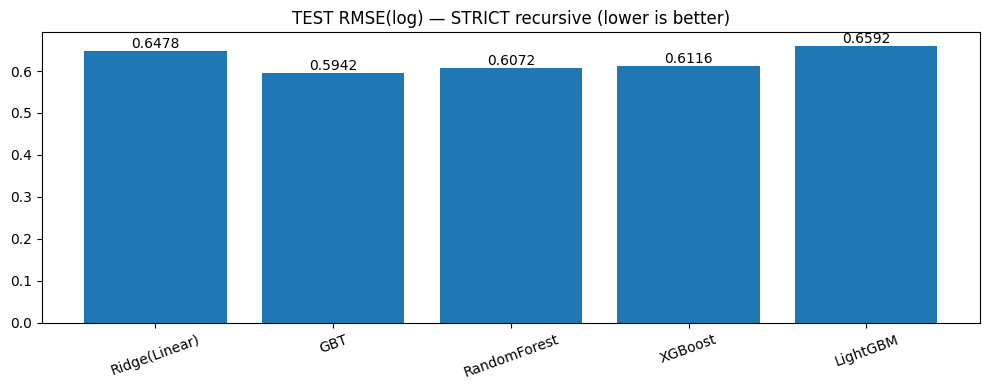

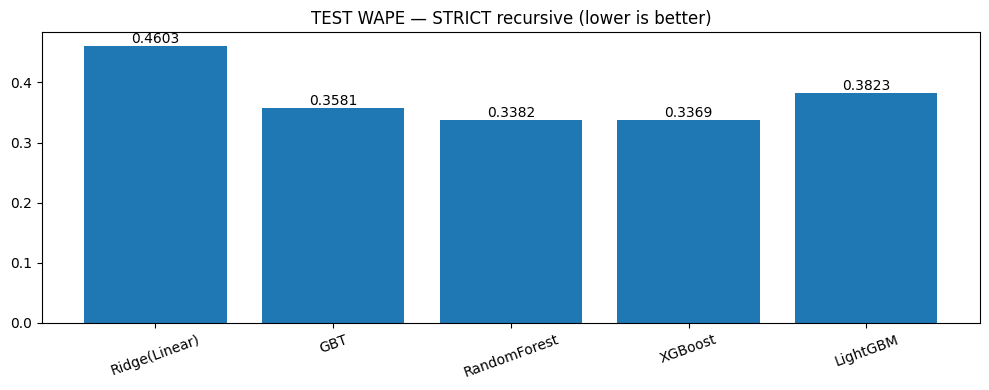


✅ Best model: GBT | RMSE(log)=0.594185 | WAPE=0.3581
✅ Models saved in: /kaggle/working/output_no_spark
✅ Saved model files: ['best_model', 'gbt', 'lr', 'rf']
✅ ZIP bundle: /kaggle/working/models_bundle.zip


In [1]:
import os, glob, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import joblib

# --- Optional deps ---
HAVE_XGB = False
HAVE_LGBM = False
try:
    from xgboost import XGBRegressor
    HAVE_XGB = True
except Exception:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
    HAVE_LGBM = True
except Exception:
    LGBMRegressor = None


TRAIN_CUT = "2017-06-01"
TEST_CUT  = "2017-08-01"

END_DATE   = "2017-08-16"        

K_FAMILIES = 5
K_STORES   = 1
TOP_ITEMS_PER_FAMILY = 40


HORIZON = 1

LAGS = [1,2,3,4,5,6,7,14,28]
ROLL_WINDOWS = [3,7,14,28]
ROLL_INCLUDE_TODAY = True

USE_PROMO_TARGET = True          
USE_TRANSACTIONS_FEATURES = False
USE_OIL_FEATURES = True

TE_ALPHA = 20.0

CHUNKSIZE = 2_000_000
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


CLEAN_OUTPUTS = True
SAVE_ALL_MODELS = False         
JOBLIB_COMPRESS = 3

BASE = "/kaggle/input"  

# ---------------- Helpers ----------------
def find_file(filename: str) -> str:
    for d in glob.glob(os.path.join(BASE, "*")):
        cand = os.path.join(d, filename)
        if os.path.exists(cand):
            return cand
    for root, _, files in os.walk(BASE):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find {filename} under {BASE}")

def min_date_str(a: str, b: str) -> str:
    return str(min(pd.to_datetime(a), pd.to_datetime(b)).date())

def clip_nonneg(x):
    return np.clip(np.asarray(x, dtype=float), 0.0, None)

def eval_log_metrics(y_true, y_pred, name=""):
    y_pred = clip_nonneg(y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    print(f"{name}: RMSE(log)={rmse:.6f} | MAE(log)={mae:.6f} | R2={r2:.4f}")
    return {"model": name, "rmse": rmse, "mae": mae, "r2": r2}

def eval_sales_metrics(y_true_log, y_pred_log, name=""):
    y_pred_log = clip_nonneg(y_pred_log)
    y_true = np.expm1(np.asarray(y_true_log, dtype=float))
    y_pred = np.expm1(y_pred_log)
    abs_err = np.abs(y_pred - y_true)
    se = (y_pred - y_true) ** 2
    mae = float(abs_err.mean())
    rmse = float(np.sqrt(se.mean()))
    sae = float(abs_err.sum())
    sy = float(y_true.sum())
    wape = float(sae / (sy if sy > 0 else 1.0))
    print(f"{name}: MAE(sales)={mae:.4f} | RMSE(sales)={rmse:.4f} | WAPE={wape:.4f}")
    return {"mae_sales": mae, "rmse_sales": rmse, "wape": wape}

def plot_bar_compare(rows, metric="rmse", title=None):
    plt.figure(figsize=(10,4))
    names = [r["model"] for r in rows]
    vals = [r.get(metric, np.nan) for r in rows]
    bars = plt.bar(names, vals)
    plt.title(title or metric)
    for b in bars:
        h = b.get_height()
        if np.isfinite(h):
            plt.text(b.get_x() + b.get_width()/2, h, f"{h:.4f}", ha="center", va="bottom", fontsize=10)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

def parse_onpromotion_series(s: pd.Series) -> np.ndarray:
    return s.astype("string").fillna("false").str.lower().eq("true").astype(np.int8).values

# ---------------- Paths ----------------
train_path  = find_file("train.csv")
items_path  = find_file("items.csv")
stores_path = find_file("stores.csv")
trans_path  = find_file("transactions.csv")
oil_path    = find_file("oil.csv")
hol_path    = find_file("holidays_events.csv")
print("Paths OK")

# ---------------- Load items/stores ----------------
items_full = pd.read_csv(items_path, usecols=["item_nbr","family","class","perishable"])
items_full["item_nbr"] = items_full["item_nbr"].astype(int)
items_full["family"] = items_full["family"].astype(str)
items_full["class"] = items_full["class"].astype(int)
items_full["perishable"] = items_full["perishable"].astype(int)

stores_full = pd.read_csv(stores_path, usecols=["store_nbr","city","state","type","cluster"])
stores_full = stores_full.rename(columns={"type":"store_type"})
stores_full["store_nbr"] = stores_full["store_nbr"].astype(int)
stores_full["cluster"] = stores_full["cluster"].astype(int)

item2family = dict(zip(items_full["item_nbr"].values, items_full["family"].values))

TRAIN_CUT_DT = pd.to_datetime(TRAIN_CUT)
TEST_CUT_DT = pd.to_datetime(TEST_CUT)
END_REQ_DT = pd.to_datetime(END_DATE)

# ==========================================================
# Phase 1: subset selection (TRAIN history only, no snooping)
# (START_DATE більше немає -> використовуємо ВСІ дати < TRAIN_CUT)
# ==========================================================
print("\n--- Phase 1: Select subset (train-only history) ---")

usecols_min = ["date","store_nbr","item_nbr"]
chunk_kwargs_min = dict(
    chunksize=CHUNKSIZE,
    dtype={"store_nbr": "int32", "item_nbr": "int32"},
)

fam_counts = {}
for chunk in pd.read_csv(train_path, usecols=usecols_min, **chunk_kwargs_min):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] < TRAIN_CUT_DT)
    c = chunk.loc[m, ["item_nbr"]]
    if c.empty:
        continue
    fam = c["item_nbr"].map(item2family)
    vc = fam.value_counts(dropna=True)
    for k, v in vc.items():
        fam_counts[k] = fam_counts.get(k, 0) + int(v)

target_families = [k for k,_ in sorted(fam_counts.items(), key=lambda kv: kv[1], reverse=True)[:K_FAMILIES]]
print("Selected families:", target_families)

store_counts = {}
for chunk in pd.read_csv(train_path, usecols=usecols_min, **chunk_kwargs_min):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] < TRAIN_CUT_DT)
    c = chunk.loc[m, ["store_nbr","item_nbr"]]
    if c.empty:
        continue
    fam = c["item_nbr"].map(item2family)
    c = c.loc[fam.isin(target_families)]
    if c.empty:
        continue
    vc = c["store_nbr"].value_counts()
    for k, v in vc.items():
        store_counts[int(k)] = store_counts.get(int(k), 0) + int(v)

target_stores = [k for k,_ in sorted(store_counts.items(), key=lambda kv: kv[1], reverse=True)[:K_STORES]]
print("Selected stores:", target_stores)

item_counts = {fam:{} for fam in target_families}
for chunk in pd.read_csv(train_path, usecols=usecols_min, **chunk_kwargs_min):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] < TRAIN_CUT_DT)
    c = chunk.loc[m, ["store_nbr","item_nbr"]]
    if c.empty:
        continue
    c = c.loc[c["store_nbr"].isin(target_stores)]
    if c.empty:
        continue
    fam = c["item_nbr"].map(item2family)
    c = c.assign(family=fam)
    c = c.loc[c["family"].isin(target_families)]
    if c.empty:
        continue
    for fam_name, sub in c.groupby("family"):
        vc = sub["item_nbr"].value_counts()
        d = item_counts[fam_name]
        for item, v in vc.items():
            it = int(item)
            d[it] = d.get(it, 0) + int(v)

target_items = []
for fam_name in target_families:
    top_items = [k for k,_ in sorted(item_counts[fam_name].items(), key=lambda kv: kv[1], reverse=True)[:TOP_ITEMS_PER_FAMILY]]
    target_items.extend(top_items)

target_items = sorted(set(target_items))
print("Selected items:", len(target_items))

stores = stores_full.loc[stores_full["store_nbr"].isin(target_stores)].copy()
items = items_full.loc[items_full["item_nbr"].isin(target_items)].copy()

# ==========================================================
# Phase 2: load aggregated daily sales+promo for subset up to test end
# (START_DATE авто: найраніша дата в підмножині)
# ==========================================================
print("\n--- Phase 2: Load subset daily sales/promo (chunked) ---")

usecols_train = ["date","store_nbr","item_nbr","unit_sales","onpromotion"]
chunk_kwargs_train = dict(
    chunksize=CHUNKSIZE,
    dtype={"store_nbr": "int32", "item_nbr": "int32", "onpromotion": "string"},
)

factual_min_date = None
factual_max_date = None
for chunk in pd.read_csv(train_path, usecols=usecols_train, **chunk_kwargs_train):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] <= END_REQ_DT)
    c = chunk.loc[m]
    if c.empty:
        continue
    c = c.loc[c["store_nbr"].isin(target_stores) & c["item_nbr"].isin(target_items)]
    if c.empty:
        continue
    mn = c["date"].min()
    mx = c["date"].max()
    factual_min_date = mn if factual_min_date is None else min(factual_min_date, mn)
    factual_max_date = mx if factual_max_date is None else max(factual_max_date, mx)

if factual_max_date is None or factual_min_date is None:
    raise RuntimeError("No rows after filtering subset. Check subset/END_DATE.")

START_DT = pd.to_datetime(factual_min_date).normalize()   # ✅ авто-START
END_DATE_FACT = str(factual_max_date.date())
END_DATE_USED = min_date_str(END_DATE, END_DATE_FACT)
END_USED_DT = pd.to_datetime(END_DATE_USED)

TRAIN_CUT_USED = min_date_str(TRAIN_CUT, END_DATE_USED)
TEST_CUT_USED  = min_date_str(TEST_CUT,  END_DATE_USED)
TRAIN_CUT_USED_DT = pd.to_datetime(TRAIN_CUT_USED)
TEST_CUT_USED_DT  = pd.to_datetime(TEST_CUT_USED)

EVAL_END_DT = min(END_USED_DT, TEST_CUT_USED_DT - pd.Timedelta(days=1))
if EVAL_END_DT < TRAIN_CUT_USED_DT:
    raise RuntimeError("After trimming, test window is empty. Check cuts/end date.")

print(f"Auto START_DT (from subset) = {str(START_DT.date())}")
print(f"END_DATE requested={END_DATE} | factual_max={END_DATE_FACT} | using END_DATE={END_DATE_USED}")
print("Using cuts:", TRAIN_CUT_USED, TEST_CUT_USED)
print("Eval test range:", str(TRAIN_CUT_USED_DT.date()), "to", str(EVAL_END_DT.date()))

aggs = []
for chunk in pd.read_csv(train_path, usecols=usecols_train, **chunk_kwargs_train):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] >= START_DT) & (chunk["date"] <= EVAL_END_DT)
    c = chunk.loc[m].copy()
    if c.empty:
        continue
    c = c.loc[c["store_nbr"].isin(target_stores) & c["item_nbr"].isin(target_items)]
    if c.empty:
        continue

    promo = parse_onpromotion_series(c["onpromotion"])
    sales = pd.to_numeric(c["unit_sales"], errors="coerce").fillna(0.0).astype(float)
    sales = np.clip(sales, 0.0, None)

    c = c.assign(onpromotion_bool=promo, unit_sales_clipped=sales)
    grp = (c.groupby(["date","store_nbr","item_nbr"], as_index=False)
             .agg(sales_sum=("unit_sales_clipped","sum"),
                  onpromotion_bool=("onpromotion_bool","max")))
    aggs.append(grp)

daily = pd.concat(aggs, ignore_index=True)
daily = (daily.groupby(["date","store_nbr","item_nbr"], as_index=False)
              .agg(sales_sum=("sales_sum","sum"),
                   onpromotion_bool=("onpromotion_bool","max")))
daily["label_log"] = np.log1p(daily["sales_sum"].astype(float))

STORE = int(target_stores[0])
daily = daily.loc[daily["store_nbr"] == STORE].copy()

# Build calendar arrays: dates x items
dates_all = pd.date_range(START_DT, EVAL_END_DT, freq="D")
items_list = sorted(target_items)
n_days = len(dates_all)
n_items = len(items_list)
item_to_j = {it: j for j, it in enumerate(items_list)}
date_to_i = {pd.Timestamp(d): i for i, d in enumerate(dates_all)}

y_true = np.zeros((n_days, n_items), dtype=np.float32)      # true log sales
promo_known = np.zeros((n_days, n_items), dtype=np.int8)    # known promo calendar (allowed)

for r in daily.itertuples(index=False):
    i = date_to_i.get(pd.Timestamp(r.date), None)
    j = item_to_j.get(int(r.item_nbr), None)
    if i is None or j is None:
        continue
    y_true[i, j] = float(r.label_log)
    promo_known[i, j] = int(r.onpromotion_bool)

# ==========================================================
# Phase 3: store-date deterministic features
# ==========================================================
print("\n--- Phase 3: Build deterministic store-date features ---")

date_dim = pd.DataFrame({"date": dates_all})
store_date = date_dim.copy()
store_date["store_nbr"] = STORE

store_date["dow"] = store_date["date"].dt.dayofweek + 1
store_date["dom"] = store_date["date"].dt.day
store_date["month"] = store_date["date"].dt.month
store_date["weekofyear"] = store_date["date"].dt.isocalendar().week.astype(int)
store_date["doy"] = store_date["date"].dt.dayofyear
store_date["is_weekend"] = store_date["dow"].isin([6,7]).astype(int)
pi = float(np.pi)
store_date["sin_doy"] = np.sin((2*pi) * store_date["doy"] / 365.0)
store_date["cos_doy"] = np.cos((2*pi) * store_date["doy"] / 365.0)
store_date["time_idx"] = (store_date["date"] - START_DT).dt.days.astype(int)

# Holidays store-specific
hol = pd.read_csv(hol_path)
hol["date"] = pd.to_datetime(hol["date"])
if "locale" not in hol.columns and "lacale" in hol.columns:
    hol = hol.rename(columns={"lacale":"locale"})
hol = hol.loc[(hol["date"] >= START_DT) & (hol["date"] <= EVAL_END_DT)].copy()
if "transferred" in hol.columns:
    hol["transferred"] = hol["transferred"].fillna(False).astype(bool)
    hol = hol.loc[hol["transferred"] == False].copy()

hol = hol[["date","type","locale","locale_name"]].copy()
hol["type"] = hol["type"].astype(str)
hol["locale"] = hol["locale"].astype(str)
hol["locale_name"] = hol["locale_name"].astype(str)

store_row = stores.loc[stores["store_nbr"] == STORE].iloc[0]
store_city = str(store_row["city"])
store_state = str(store_row["state"])

hol_nat = hol.loc[hol["locale"] == "National", ["date","type"]].copy()
hol_nat["store_nbr"] = STORE

hol_reg = hol.loc[(hol["locale"] == "Regional") & (hol["locale_name"] == store_state), ["date","type"]].copy()
hol_reg["store_nbr"] = STORE

hol_loc = hol.loc[(hol["locale"] == "Local") & (hol["locale_name"] == store_city), ["date","type"]].copy()
hol_loc["store_nbr"] = STORE

hol_store = pd.concat([hol_nat, hol_reg, hol_loc], ignore_index=True)

if hol_store.empty:
    holiday_features = pd.DataFrame({"date": dates_all, "store_nbr": STORE,
                                     "holiday_count":0,"is_holiday":0,"is_event":0,"is_additional":0,
                                     "is_bridge":0,"is_workday":0,"is_transfer":0})
else:
    holiday_features = (hol_store.groupby(["date","store_nbr"], as_index=False)
        .agg(
            holiday_count=("type","size"),
            is_holiday=("type", lambda s: int((s == "Holiday").any())),
            is_event=("type", lambda s: int((s == "Event").any())),
            is_additional=("type", lambda s: int((s == "Additional").any())),
            is_bridge=("type", lambda s: int((s == "Bridge").any())),
            is_workday=("type", lambda s: int((s == "Work Day").any())),
            is_transfer=("type", lambda s: int((s == "Transfer").any())),
        ))

store_date = store_date.merge(holiday_features, on=["date","store_nbr"], how="left").fillna(0)

# transactions optional
if USE_TRANSACTIONS_FEATURES:
    tr = pd.read_csv(trans_path, usecols=["date","store_nbr","transactions"])
    tr["date"] = pd.to_datetime(tr["date"])
    tr = tr.loc[(tr["date"] >= START_DT) & (tr["date"] <= EVAL_END_DT)]
    tr = tr.loc[tr["store_nbr"] == STORE]
    tr["transactions"] = tr["transactions"].fillna(0).astype(int)
    store_date = store_date.merge(tr[["date","transactions"]], on="date", how="left")
    store_date["transactions"] = store_date["transactions"].fillna(0).astype(int)
else:
    store_date["transactions"] = 0

# oil optional
if USE_OIL_FEATURES:
    oil = pd.read_csv(oil_path, usecols=["date","dcoilwtico"])
    oil["date"] = pd.to_datetime(oil["date"])
    oil = oil.loc[(oil["date"] >= START_DT) & (oil["date"] <= EVAL_END_DT)]
    oil = oil.set_index("date").reindex(dates_all).sort_index()
    oil["oil_ffill"] = oil["dcoilwtico"].ffill().fillna(0.0).astype(float)
    oil = oil.reset_index().rename(columns={"index":"date"})[["date","oil_ffill"]]
    store_date = store_date.merge(oil, on="date", how="left")
    store_date["oil_ffill"] = store_date["oil_ffill"].fillna(0.0).astype(float)
else:
    store_date["oil_ffill"] = 0.0

# lags/rolls for known series
store_date = store_date.sort_values("date").reset_index(drop=True)
store_date["transactions_lag1"] = store_date["transactions"].shift(1).fillna(0).astype(float)
store_date["transactions_roll7"] = store_date["transactions"].rolling(7, min_periods=1).mean().astype(float)
store_date["transactions_roll28"] = store_date["transactions"].rolling(28, min_periods=1).mean().astype(float)

store_date["oil_lag1"] = store_date["oil_ffill"].shift(1).fillna(0.0).astype(float)
store_date["oil_roll7"] = store_date["oil_ffill"].rolling(7, min_periods=1).mean().astype(float)
store_date["oil_roll28"] = store_date["oil_ffill"].rolling(28, min_periods=1).mean().astype(float)

sd = store_date.set_index("date")
def sd_row(d: pd.Timestamp) -> pd.Series:
    return sd.loc[d]

# ==========================================================
# Phase 4: Time-aware Target Encoding (train only, no same-day)
# ==========================================================
print("\n--- Phase 4: Time-aware Target Encoding (by date, no same-day) ---")

train_end_date = TRAIN_CUT_USED_DT - pd.Timedelta(days=1)
train_end_i = date_to_i[pd.Timestamp(train_end_date)]

global_mean = float(np.mean(y_true[:train_end_i+1, :]))
alpha = float(TE_ALPHA)

# families mapping for items_list -> family_id
item_family = dict(zip(items["item_nbr"].astype(int), items["family"].astype(str)))
families = sorted(set(target_families))
fam_to_id = {f:i for i,f in enumerate(families)}
family_id_arr = np.array([fam_to_id.get(item_family.get(it, families[0]), 0) for it in items_list], dtype=np.int32)
n_fams = len(families)
family_size = np.bincount(family_id_arr, minlength=n_fams).astype(np.int32)

sum_item = np.zeros(n_items, dtype=np.float64)
sum_family = np.zeros(n_fams, dtype=np.float64)

te_item_origin = np.zeros((train_end_i+1, n_items), dtype=np.float32)
te_family_origin = np.zeros((train_end_i+1, n_items), dtype=np.float32)
cnt_family_origin = np.zeros((train_end_i+1, n_items), dtype=np.int32)

for i in range(train_end_i+1):
    cnt_days = i  # history days < i

    te_item = (sum_item + global_mean*alpha) / (cnt_days + alpha)
    te_item_origin[i, :] = te_item.astype(np.float32)

    denom_f = (cnt_days * family_size + alpha).astype(np.float64)
    te_fam_vec = (sum_family + global_mean*alpha) / np.where(denom_f > 0, denom_f, 1.0)
    te_family_origin[i, :] = te_fam_vec[family_id_arr].astype(np.float32)
    cnt_family_origin[i, :] = (cnt_days * family_size[family_id_arr]).astype(np.int32)

    y_day = y_true[i, :].astype(np.float64)
    sum_item += y_day
    sum_family += np.bincount(family_id_arr, weights=y_day, minlength=n_fams)



print("\n--- Phase 5: Build TRAIN dataset (H=1) ---")

item_class = dict(zip(items["item_nbr"].astype(int), items["class"].astype(int)))
item_perish = dict(zip(items["item_nbr"].astype(int), items["perishable"].astype(int)))
store_cluster = int(store_row["cluster"])

num_cols = [
    "horizon_cap","log1p_horizon_cap",
    "class","perishable","cluster",
    "label_today","onpromotion_bool",
    "te_item","te_family",
    "log_cnt_item","log_cnt_family",
    "cnt_item","cnt_family",
]
if USE_PROMO_TARGET:
    num_cols.append("onpromotion_target")

num_cols += [
    *[f"lag{lag}_label" for lag in LAGS],
    *[f"roll{rw}_mean_label" for rw in ROLL_WINDOWS],
    *[f"lag{lag}_promo" for lag in LAGS],
    *[f"roll{rw}_mean_promo" for rw in ROLL_WINDOWS],
    "dow_last4_mean_label",
    "trend_7_28","trend_1_7",
    "dow","dom","month","weekofyear","doy","is_weekend","sin_doy","cos_doy","time_idx",
    "holiday_count","is_holiday","is_event","is_additional","is_bridge","is_workday","is_transfer",
    "transactions_lag1","transactions_roll7","transactions_roll28",
    "oil_lag1","oil_roll7","oil_roll28",
    "dow_t","dom_t","month_t","weekofyear_t","doy_t","is_weekend_t","sin_doy_t","cos_doy_t","time_idx_t",
    "holiday_count_t","is_holiday_t","is_event_t","is_additional_t","is_bridge_t","is_workday_t","is_transfer_t",
]
# safety
if len(num_cols) != len(set(num_cols)):
    dups = [c for c in num_cols if num_cols.count(c) > 1]
    raise RuntimeError(f"Duplicate feature columns detected: {sorted(set(dups))}")

col2k = {c:i for i,c in enumerate(num_cols)}
n_feat = len(num_cols)

train_origin_max_i = train_end_i - 1
train_rows = (train_origin_max_i + 1) * n_items

X_train = np.zeros((train_rows, n_feat), dtype=np.float32)
y_train = np.zeros((train_rows,), dtype=np.float32)

dow_hist = [ {d: deque(maxlen=4) for d in range(1,8)} for _ in range(n_items) ]

item_class_arr = np.array([item_class[it] for it in items_list], dtype=np.float32)
item_perish_arr = np.array([item_perish[it] for it in items_list], dtype=np.float32)
family_size_item = family_size[family_id_arr].astype(np.int32)

for i in range(train_origin_max_i + 1):
    origin_date = dates_all[i]
    target_date = dates_all[i+1]
    o = sd_row(origin_date)
    t = sd_row(target_date)
    origin_dow = int(o["dow"])

    o_vals = {
        "dow": int(o["dow"]), "dom": int(o["dom"]), "month": int(o["month"]), "weekofyear": int(o["weekofyear"]),
        "doy": int(o["doy"]), "is_weekend": int(o["is_weekend"]),
        "sin_doy": float(o["sin_doy"]), "cos_doy": float(o["cos_doy"]), "time_idx": int(o["time_idx"]),
        "holiday_count": int(o["holiday_count"]), "is_holiday": int(o["is_holiday"]), "is_event": int(o["is_event"]),
        "is_additional": int(o["is_additional"]), "is_bridge": int(o["is_bridge"]), "is_workday": int(o["is_workday"]),
        "is_transfer": int(o["is_transfer"]),
        "transactions_lag1": float(o["transactions_lag1"]), "transactions_roll7": float(o["transactions_roll7"]),
        "transactions_roll28": float(o["transactions_roll28"]),
        "oil_lag1": float(o["oil_lag1"]), "oil_roll7": float(o["oil_roll7"]), "oil_roll28": float(o["oil_roll28"]),
    }
    t_vals = {
        "dow_t": int(t["dow"]), "dom_t": int(t["dom"]), "month_t": int(t["month"]), "weekofyear_t": int(t["weekofyear"]),
        "doy_t": int(t["doy"]), "is_weekend_t": int(t["is_weekend"]),
        "sin_doy_t": float(t["sin_doy"]), "cos_doy_t": float(t["cos_doy"]), "time_idx_t": int(t["time_idx"]),
        "holiday_count_t": int(t["holiday_count"]), "is_holiday_t": int(t["is_holiday"]), "is_event_t": int(t["is_event"]),
        "is_additional_t": int(t["is_additional"]), "is_bridge_t": int(t["is_bridge"]), "is_workday_t": int(t["is_workday"]),
        "is_transfer_t": int(t["is_transfer"]),
    }

    y_t = y_true[i, :].astype(np.float32)
    y_tp1 = y_true[i+1, :].astype(np.float32)
    p_t = promo_known[i, :].astype(np.float32)
    p_tp1 = promo_known[i+1, :].astype(np.float32)

    te_item = te_item_origin[i, :].astype(np.float32)
    te_family = te_family_origin[i, :].astype(np.float32)

    cnt_days = float(i)
    cnt_family = (i * family_size_item).astype(np.float32)

    base_r = i * n_items
    rows_idx = np.arange(base_r, base_r + n_items)

    y_train[rows_idx] = y_tp1

    X_train[rows_idx, col2k["horizon_cap"]] = 1.0
    X_train[rows_idx, col2k["log1p_horizon_cap"]] = float(np.log1p(1.0))

    X_train[rows_idx, col2k["class"]] = item_class_arr
    X_train[rows_idx, col2k["perishable"]] = item_perish_arr
    X_train[rows_idx, col2k["cluster"]] = float(store_cluster)

    X_train[rows_idx, col2k["label_today"]] = y_t
    X_train[rows_idx, col2k["onpromotion_bool"]] = p_t

    X_train[rows_idx, col2k["te_item"]] = te_item
    X_train[rows_idx, col2k["te_family"]] = te_family
    X_train[rows_idx, col2k["cnt_item"]] = cnt_days
    X_train[rows_idx, col2k["log_cnt_item"]] = float(np.log1p(cnt_days))
    X_train[rows_idx, col2k["cnt_family"]] = cnt_family
    X_train[rows_idx, col2k["log_cnt_family"]] = np.log1p(cnt_family)

    if USE_PROMO_TARGET:
        X_train[rows_idx, col2k["onpromotion_target"]] = p_tp1

    for lag in LAGS:
        y_l = y_true[i-lag, :] if (i-lag) >= 0 else 0.0
        p_l = promo_known[i-lag, :] if (i-lag) >= 0 else 0.0
        X_train[rows_idx, col2k[f"lag{lag}_label"]] = y_l
        X_train[rows_idx, col2k[f"lag{lag}_promo"]] = p_l

    for rw in ROLL_WINDOWS:
        if ROLL_INCLUDE_TODAY:
            a = max(0, i-rw+1); b = i+1
        else:
            a = max(0, i-rw); b = i
        if b <= a:
            y_m = np.zeros(n_items, dtype=np.float32)
            p_m = np.zeros(n_items, dtype=np.float32)
        else:
            y_m = np.mean(y_true[a:b, :], axis=0).astype(np.float32)
            p_m = np.mean(promo_known[a:b, :], axis=0).astype(np.float32)
        X_train[rows_idx, col2k[f"roll{rw}_mean_label"]] = y_m
        X_train[rows_idx, col2k[f"roll{rw}_mean_promo"]] = p_m

    for j in range(n_items):
        dq = dow_hist[j][origin_dow]
        X_train[base_r + j, col2k["dow_last4_mean_label"]] = float(np.mean(dq)) if len(dq) else 0.0

    lag7 = y_true[i-7, :] if (i-7) >= 0 else 0.0
    lag28 = y_true[i-28, :] if (i-28) >= 0 else 0.0
    lag1 = y_true[i-1, :] if (i-1) >= 0 else 0.0
    X_train[rows_idx, col2k["trend_7_28"]] = (lag7 - lag28)
    X_train[rows_idx, col2k["trend_1_7"]]  = (lag1 - lag7)

    for k, v in o_vals.items():
        X_train[rows_idx, col2k[k]] = float(v)
    for k, v in t_vals.items():
        X_train[rows_idx, col2k[k]] = float(v)

    for j in range(n_items):
        dow_hist[j][origin_dow].append(float(y_true[i, j]))

X_train_df = pd.DataFrame(X_train, columns=num_cols)
print("Train dataset:", X_train_df.shape, "| y:", y_train.shape)

# ==========================================================
# Phase 6-7: For each model: TRAIN -> STRICT TEST -> PLOTS
# ==========================================================
print("\n--- Phase 6-7: Train+Test each model (in order) ---")

test_start = TRAIN_CUT_USED_DT
test_end = EVAL_END_DT
test_dates = pd.date_range(test_start, test_end, freq="D")
test_is = [date_to_i[pd.Timestamp(d)] for d in test_dates]

hist_len = max(max(LAGS)+1, max(ROLL_WINDOWS)+1, 90)

def init_histories():
    start_i = max(0, train_end_i - hist_len + 1)
    y_hist0 = [deque([float(y_true[i, j]) for i in range(start_i, train_end_i+1)], maxlen=hist_len)
               for j in range(n_items)]
    p_hist0 = [deque([int(promo_known[i, j]) for i in range(start_i, train_end_i+1)], maxlen=hist_len)
               for j in range(n_items)]

    dow_hist0 = [ {d: deque(maxlen=4) for d in range(1,8)} for _ in range(n_items) ]
    for i in range(0, train_end_i):
        dow_i = int(sd_row(dates_all[i])["dow"])
        y_day = y_true[i, :]
        for j in range(n_items):
            dow_hist0[j][dow_i].append(float(y_day[j]))

    sum_item_state = y_true[:train_end_i, :].sum(axis=0).astype(np.float64)  # days < train_end_i
    sum_family_state = np.bincount(family_id_arr, weights=sum_item_state, minlength=n_fams).astype(np.float64)
    cnt_days_state = int(train_end_i)

    return y_hist0, p_hist0, dow_hist0, sum_item_state, sum_family_state, cnt_days_state

def build_features_for_day(
    origin_i: int,
    target_i: int,
    y_hist_state,
    p_hist_state,
    dow_hist_state,
    sum_item_state,
    sum_family_state,
    cnt_days_state
):
    origin_date = dates_all[origin_i]
    target_date = dates_all[target_i]

    o = sd_row(origin_date)
    t = sd_row(target_date)
    origin_dow = int(o["dow"])

    o_vals = {
        "dow": int(o["dow"]), "dom": int(o["dom"]), "month": int(o["month"]), "weekofyear": int(o["weekofyear"]),
        "doy": int(o["doy"]), "is_weekend": int(o["is_weekend"]),
        "sin_doy": float(o["sin_doy"]), "cos_doy": float(o["cos_doy"]), "time_idx": int(o["time_idx"]),
        "holiday_count": int(o["holiday_count"]), "is_holiday": int(o["is_holiday"]), "is_event": int(o["is_event"]),
        "is_additional": int(o["is_additional"]), "is_bridge": int(o["is_bridge"]), "is_workday": int(o["is_workday"]),
        "is_transfer": int(o["is_transfer"]),
        "transactions_lag1": float(o["transactions_lag1"]), "transactions_roll7": float(o["transactions_roll7"]),
        "transactions_roll28": float(o["transactions_roll28"]),
        "oil_lag1": float(o["oil_lag1"]), "oil_roll7": float(o["oil_roll7"]), "oil_roll28": float(o["oil_roll28"]),
    }
    t_vals = {
        "dow_t": int(t["dow"]), "dom_t": int(t["dom"]), "month_t": int(t["month"]), "weekofyear_t": int(t["weekofyear"]),
        "doy_t": int(t["doy"]), "is_weekend_t": int(t["is_weekend"]),
        "sin_doy_t": float(t["sin_doy"]), "cos_doy_t": float(t["cos_doy"]), "time_idx_t": int(t["time_idx"]),
        "holiday_count_t": int(t["holiday_count"]), "is_holiday_t": int(t["is_holiday"]), "is_event_t": int(t["is_event"]),
        "is_additional_t": int(t["is_additional"]), "is_bridge_t": int(t["is_bridge"]), "is_workday_t": int(t["is_workday"]),
        "is_transfer_t": int(t["is_transfer"]),
    }

    X = np.zeros((n_items, n_feat), dtype=np.float32)
    X[:, col2k["horizon_cap"]] = 1.0
    X[:, col2k["log1p_horizon_cap"]] = float(np.log1p(1.0))
    X[:, col2k["cluster"]] = float(store_cluster)

    X[:, col2k["class"]] = item_class_arr
    X[:, col2k["perishable"]] = item_perish_arr

    for k, v in o_vals.items():
        X[:, col2k[k]] = float(v)
    for k, v in t_vals.items():
        X[:, col2k[k]] = float(v)

    te_item = (sum_item_state + global_mean*alpha) / (cnt_days_state + alpha)
    denom_f = (cnt_days_state * family_size + alpha).astype(np.float64)
    te_fam_vec = (sum_family_state + global_mean*alpha) / np.where(denom_f > 0, denom_f, 1.0)
    te_family = te_fam_vec[family_id_arr]

    cnt_item = float(cnt_days_state)
    cnt_family_vec = (cnt_days_state * family_size_item).astype(np.float32)

    X[:, col2k["te_item"]] = te_item.astype(np.float32)
    X[:, col2k["te_family"]] = te_family.astype(np.float32)
    X[:, col2k["cnt_item"]] = cnt_item
    X[:, col2k["log_cnt_item"]] = float(np.log1p(cnt_item))
    X[:, col2k["cnt_family"]] = cnt_family_vec
    X[:, col2k["log_cnt_family"]] = np.log1p(cnt_family_vec)

    if USE_PROMO_TARGET:
        X[:, col2k["onpromotion_target"]] = promo_known[target_i, :].astype(np.float32)

    for j in range(n_items):
        y_t = float(y_hist_state[j][-1]) if len(y_hist_state[j]) else 0.0
        p_t = float(p_hist_state[j][-1]) if len(p_hist_state[j]) else 0.0
        X[j, col2k["label_today"]] = y_t
        X[j, col2k["onpromotion_bool"]] = p_t

        for lag in LAGS:
            idx = -(lag+1)
            y_l = float(y_hist_state[j][idx]) if len(y_hist_state[j]) >= (lag+1) else 0.0
            p_l = float(p_hist_state[j][idx]) if len(p_hist_state[j]) >= (lag+1) else 0.0
            X[j, col2k[f"lag{lag}_label"]] = y_l
            X[j, col2k[f"lag{lag}_promo"]] = p_l

        for rw in ROLL_WINDOWS:
            if ROLL_INCLUDE_TODAY:
                tail = list(y_hist_state[j])[-rw:]
                tailp = list(p_hist_state[j])[-rw:]
            else:
                tail = list(y_hist_state[j])[-(rw+1):-1]
                tailp = list(p_hist_state[j])[-(rw+1):-1]
            X[j, col2k[f"roll{rw}_mean_label"]] = float(np.mean(tail)) if len(tail) else 0.0
            X[j, col2k[f"roll{rw}_mean_promo"]] = float(np.mean(tailp)) if len(tailp) else 0.0

        dq = dow_hist_state[j][origin_dow]
        X[j, col2k["dow_last4_mean_label"]] = float(np.mean(dq)) if len(dq) else 0.0

        lag7 = float(y_hist_state[j][-(7+1)]) if len(y_hist_state[j]) >= 8 else 0.0
        lag28 = float(y_hist_state[j][-(28+1)]) if len(y_hist_state[j]) >= 29 else 0.0
        lag1 = float(y_hist_state[j][-(1+1)]) if len(y_hist_state[j]) >= 2 else 0.0
        X[j, col2k["trend_7_28"]] = lag7 - lag28
        X[j, col2k["trend_1_7"]]  = lag1 - lag7

    return pd.DataFrame(X, columns=num_cols), origin_dow

def strict_recursive_test(model, name):
    y_hist, p_hist, dow_hist_state, sum_item_state, sum_family_state, cnt_days_state = init_histories()

    preds = []
    trues = []
    dates_out = []

    for target_i in test_is:
        origin_i = target_i - 1
        X_step_df, origin_dow = build_features_for_day(
            origin_i, target_i,
            y_hist, p_hist, dow_hist_state,
            sum_item_state, sum_family_state, cnt_days_state
        )

        y_pred = clip_nonneg(model.predict(X_step_df)).astype(np.float32)
        y_true_day = y_true[target_i, :].astype(np.float32)

        preds.append(y_pred)
        trues.append(y_true_day)
        dates_out.append(dates_all[target_i])

        y_origin_vec = np.array([float(dq[-1]) if len(dq) else 0.0 for dq in y_hist], dtype=np.float64)

        for j in range(n_items):
            dow_hist_state[j][origin_dow].append(float(y_origin_vec[j]))

        sum_item_state += y_origin_vec
        sum_family_state += np.bincount(family_id_arr, weights=y_origin_vec, minlength=n_fams).astype(np.float64)
        cnt_days_state += 1

        for j in range(n_items):
            y_hist[j].append(float(y_pred[j]))
            p_hist[j].append(int(promo_known[target_i, j]))

    P = np.vstack(preds)
    T = np.vstack(trues)

    m = eval_log_metrics(T.ravel(), P.ravel(), f"{name} (TEST strict recursive)")
    ms = eval_sales_metrics(T.ravel(), P.ravel(), f"{name} (TEST strict recursive)")

    y_true_sales = np.expm1(T)
    y_pred_sales = np.expm1(P)
    sae = np.abs(y_pred_sales - y_true_sales).sum(axis=1)
    sy = y_true_sales.sum(axis=1)
    wape_day = sae / np.where(sy > 0, sy, 1.0)

    plt.figure(figsize=(10,4))
    plt.plot(dates_out, wape_day)
    plt.title(f"{name}: Daily WAPE (strict recursive)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(dates_out, y_true_sales.sum(axis=1), label="actual")
    plt.plot(dates_out, y_pred_sales.sum(axis=1), label="pred")
    plt.title(f"{name}: Total daily sales (actual vs pred) — strict recursive")
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    out = {**m, **{"wape": ms["wape"]}}
    return out

# ---------------- Models list ----------------
models = []

models.append(("Ridge(Linear)", Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("model", Ridge(alpha=0.01))  # ✅ random_state прибрано
])))

models.append(("GBT", HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=320,
    min_samples_leaf=60,
    l2_regularization=0.2,
    random_state=RANDOM_SEED
)))

models.append(("RandomForest", RandomForestRegressor(
    n_estimators=350,
    max_depth=14,
    min_samples_leaf=60,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_SEED
)))

if HAVE_XGB:
    models.append(("XGBoost", XGBRegressor(
        n_estimators=1100,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,
        reg_alpha=0.0,
        min_child_weight=25,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_SEED
    )))
else:
    print("⚠️ XGBoost not installed -> skipping")

if HAVE_LGBM:
    models.append(("LightGBM", LGBMRegressor(
        n_estimators=2400,
        learning_rate=0.02,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=120,
        reg_lambda=2.0,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )))
else:
    print("⚠️ LightGBM not installed -> skipping")

# ==========================================================
# Run: per model => train -> train metrics -> strict test -> plots
# ==========================================================
train_results = []
test_results = []
trained_models = {}

for name, mdl in models:
    print("\n" + "="*70)
    print(f"MODEL: {name}")
    print("="*70)

    mdl.fit(X_train_df, y_train)
    trained_models[name] = mdl

    pred_tr = mdl.predict(X_train_df)
    mtr = eval_log_metrics(y_train, pred_tr, f"{name} (train)")
    train_results.append({"model": name, "rmse": mtr["rmse"], "mae": mtr["mae"], "r2": mtr["r2"]})

    mte = strict_recursive_test(mdl, name)
    test_results.append({"model": name, "rmse": mte["rmse"], "mae": mte["mae"], "r2": mte["r2"], "wape": mte["wape"]})


print("\n" + "="*70)
print("FINAL COMPARISON (STRICT TEST)")
print("="*70)

df_cmp = pd.DataFrame(test_results).sort_values("rmse").reset_index(drop=True)
print(df_cmp)

plot_bar_compare(
    [{"model": r["model"], "rmse": r["rmse"]} for r in test_results],
    metric="rmse",
    title="TEST RMSE(log) — STRICT recursive (lower is better)"
)

plot_bar_compare(
    [{"model": r["model"], "wape": r["wape"]} for r in test_results],
    metric="wape",
    title="TEST WAPE — STRICT recursive (lower is better)"
)

best_row = df_cmp.iloc[0]
BEST_NAME = best_row["model"]
BEST_MODEL = trained_models[BEST_NAME]
print(f"\n✅ Best model: {BEST_NAME} | RMSE(log)={best_row['rmse']:.6f} | WAPE={best_row['wape']:.4f}")




from zipfile import ZipFile

# 1) Папка, яку ти потім просто кинеш в проект
out_dir = Path("./output_no_spark")  # <-- IMPORTANT: matches backend default
if CLEAN_OUTPUTS:
    shutil.rmtree(out_dir, ignore_errors=True)
out_dir.mkdir(parents=True, exist_ok=True)

# 2) Мапа "людська назва -> ідентифікатор файлу"
NAME_TO_ID = {
    "Ridge(Linear)": "lr",
    "GBT": "gbt",
    "RandomForest": "rf",
    "XGBoost": "xgb",
    "LightGBM": "lgbm"
}

# 3) Обов'язково зберігаємо хоча б ці 3 моделі
required_ids = {"lr", "gbt", "rf"}

saved = []
for name, mdl in trained_models.items():
    mid = NAME_TO_ID.get(name)
    if mid is None:
        continue

    # зберігаємо required + (опціонально) інші якщо хочеш
    if mid in required_ids or SAVE_ALL_MODELS:
        joblib.dump(mdl, out_dir / f"{mid}.joblib", compress=JOBLIB_COMPRESS)
        saved.append(mid)

# 4) best_model.joblib теж кладемо (для model_id="best_model")
joblib.dump(BEST_MODEL, out_dir / "best_model.joblib", compress=JOBLIB_COMPRESS)

# 5) Готуємо meta у форматі, який бекенд реально очікує
#    (feature_cols + start_date)
meta = {
    "best_model_name": BEST_NAME,
    "best_rmse_log": float(best_row["rmse"]),
    "best_wape": float(best_row["wape"]),
    "train_cut": TRAIN_CUT_USED,
    "test_cut": TEST_CUT_USED,
    "eval_test_end": str(EVAL_END_DT.date()),

    # ✅ ключі, які потрібні backend
    "start_date": str(START_DT.date()),
    "end_date": str(EVAL_END_DT.date()),
    "feature_cols": num_cols,

    # корисно для UI/context
    "subset_store": STORE,
    "items_list": items_list,
    "target_families": target_families,
    "models_saved": sorted(set(saved + ["best_model"])),
    "target_transform": "log1p",
}

(out_dir / "model_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

print("✅ Models saved in:", out_dir.resolve())
print("✅ Saved model files:", meta["models_saved"])

# 6) ZIP bundle
zip_path = Path("./models_bundle.zip")
if zip_path.exists():
    zip_path.unlink()

with ZipFile(zip_path, "w") as z:
    for p in out_dir.rglob("*"):
        z.write(p, arcname=p.relative_to(out_dir.parent))

print("✅ ZIP bundle:", zip_path.resolve())


In [2]:
import numpy as np

# 1) store_date.csv (всі колонки, які ти використовував у фічах)
store_date.to_csv(out_dir / "store_date.csv", index=False)

# 2) runtime_state.npz (ключі, які очікує бекенд нижче)
np.savez_compressed(
    out_dir / "runtime_state.npz",
    y_log=y_true.astype(np.float32),
    promo=promo_known.astype(np.int8),
    items_list=np.array(items_list, dtype=np.int32),
    family_id_arr=family_id_arr.astype(np.int32),
    family_size=family_size.astype(np.int32),
    family_size_item=family_size_item.astype(np.int32),
    item_class_arr=item_class_arr.astype(np.float32),
    item_perish_arr=item_perish_arr.astype(np.float32),
    store_cluster=np.array([store_cluster], dtype=np.int32),
    global_mean=np.array([global_mean], dtype=np.float32),
    te_alpha=np.array([alpha], dtype=np.float32),
    lags=np.array(LAGS, dtype=np.int32),
    roll_windows=np.array(ROLL_WINDOWS, dtype=np.int32),
    roll_include_today=np.array([1 if ROLL_INCLUDE_TODAY else 0], dtype=np.int8),
)

print("✅ runtime_state.npz + store_date.csv saved into", out_dir)


✅ runtime_state.npz + store_date.csv saved into output_no_spark


/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


Paths OK

--- Phase 1: Select subset (train-only history) ---
Selected families: ['GROCERY I', 'BEVERAGES', 'CLEANING', 'DAIRY', 'PRODUCE']
Selected stores: [45]
Selected items: 200

--- Phase 2: Load subset daily sales/promo (chunked, array fill) ---
END_DATE requested=2017-08-16 | factual_max=2017-08-15 | using truth end=2017-08-15
Using cuts: 2017-06-01 2017-08-01
Strict test range: 2017-06-01 to 2017-07-31
Forecast calendar until: 2017-08-31

--- Phase 3: Build deterministic store-date features ---

--- Phase 4: Time-aware Target Encoding (TRAIN only, time-causal) ---

--- Phase 5: Build TRAIN dataset (H=1) ---
Train dataset: (176200, 81) | y: (176200,)

--- Baselines (STRICT TEST) ---
Baseline Persistence (TEST strict): RMSE(log)=0.783985 | MAE(log)=0.576289 | R2=0.4371
Baseline Persistence (TEST strict): MAE(sales)=17.0329 | RMSE(sales)=34.4172 | WAPE=0.4657


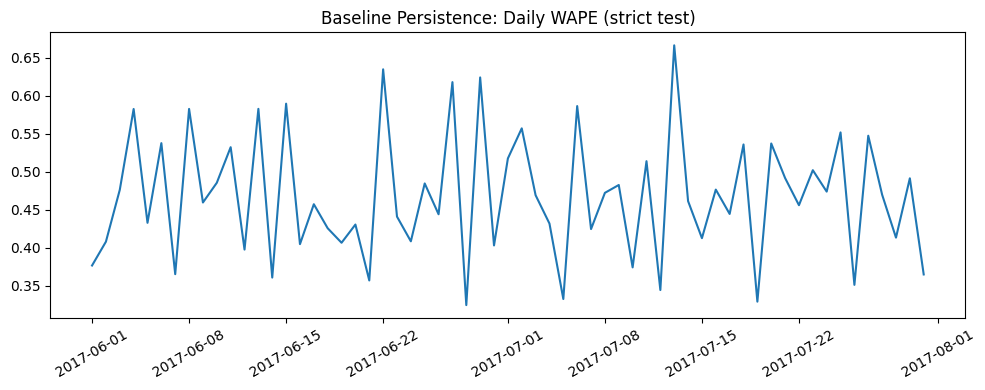


CV splits (train-internal strict):
  val: 2017-03-09 -> 2017-04-05 | as_of: 2017-03-08
  val: 2017-04-06 -> 2017-05-03 | as_of: 2017-04-05
  val: 2017-05-04 -> 2017-05-31 | as_of: 2017-05-03

--- Phase 6-7: Train+Test each model (in order) ---

MODEL: Ridge (Linear)
Ridge (train): RMSE(log)=0.473090 | MAE(log)=0.323626 | R2=0.8184
Ridge (TEST strict recursive): RMSE(log)=0.578554 | MAE(log)=0.432439 | R2=0.6935
Ridge (TEST strict recursive): MAE(sales)=14.1855 | RMSE(sales)=32.1180 | WAPE=0.3879


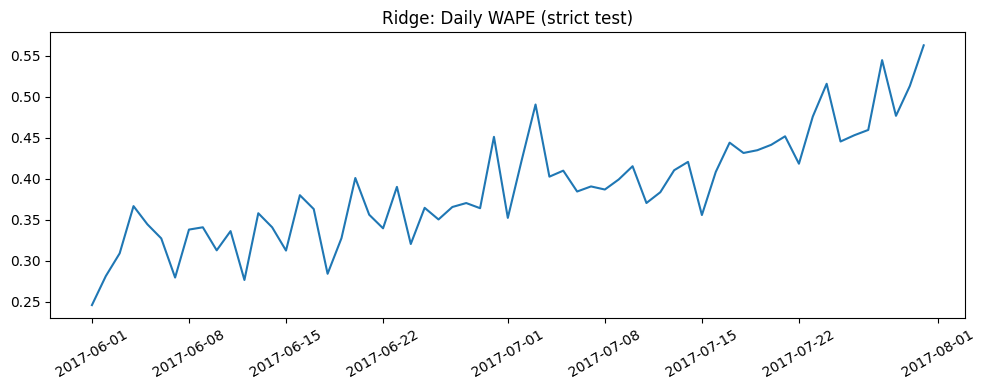


MODEL: HistGradientBoosting
GBT-trial1 (CV 2017-03-09..2017-04-05): RMSE(log)=0.637441 | MAE(log)=0.398526 | R2=0.6529
GBT-trial1 (CV): MAE(sales)=11.3908 | RMSE(sales)=25.7159 | WAPE=0.3103
GBT-trial1 (CV 2017-04-06..2017-05-03): RMSE(log)=0.741243 | MAE(log)=0.590084 | R2=0.4276
GBT-trial1 (CV): MAE(sales)=21.3658 | RMSE(sales)=49.9976 | WAPE=0.5757
GBT-trial1 (CV 2017-05-04..2017-05-31): RMSE(log)=0.466140 | MAE(log)=0.338811 | R2=0.7805
GBT-trial1 (CV): MAE(sales)=9.8099 | RMSE(sales)=20.0604 | WAPE=0.2844
  -> GBT trial 1/12: avg_CV_RMSE=0.614942 | avg_CV_WAPE=0.3901 | params={'max_depth': 6, 'learning_rate': 0.03, 'max_iter': 250, 'min_samples_leaf': 120, 'l2_regularization': 0.5}
GBT-trial2 (CV 2017-03-09..2017-04-05): RMSE(log)=0.646392 | MAE(log)=0.407783 | R2=0.6431
GBT-trial2 (CV): MAE(sales)=11.9064 | RMSE(sales)=26.8174 | WAPE=0.3243
GBT-trial2 (CV 2017-04-06..2017-05-03): RMSE(log)=0.912511 | MAE(log)=0.744603 | R2=0.1326
GBT-trial2 (CV): MAE(sales)=24.4604 | RMSE(sales)

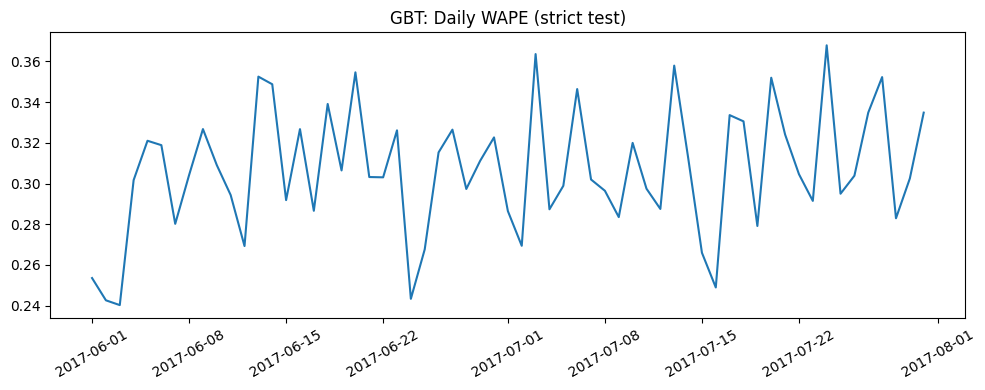


MODEL: RandomForest
RandomForest (train): RMSE(log)=0.446651 | MAE(log)=0.301426 | R2=0.8382
RandomForest (TEST strict recursive): RMSE(log)=0.571960 | MAE(log)=0.400054 | R2=0.7004
RandomForest (TEST strict recursive): MAE(sales)=12.1474 | RMSE(sales)=26.7586 | WAPE=0.3322


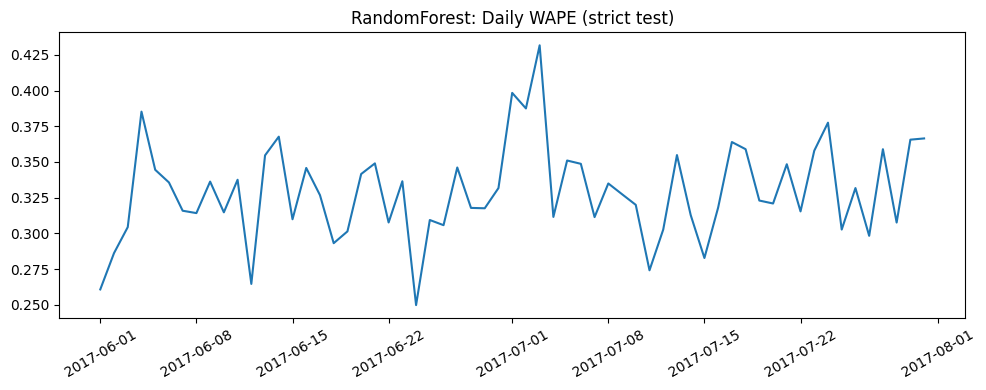


MODEL: XGBoost
XGBoost-trial1 (CV 2017-03-09..2017-04-05): RMSE(log)=0.627659 | MAE(log)=0.398789 | R2=0.6635
XGBoost-trial1 (CV): MAE(sales)=11.4167 | RMSE(sales)=25.9746 | WAPE=0.3110
XGBoost-trial1 (CV 2017-04-06..2017-05-03): RMSE(log)=0.644147 | MAE(log)=0.480479 | R2=0.5678
XGBoost-trial1 (CV): MAE(sales)=15.4470 | RMSE(sales)=37.7771 | WAPE=0.4162
XGBoost-trial1 (CV 2017-05-04..2017-05-31): RMSE(log)=0.449706 | MAE(log)=0.325778 | R2=0.7957
XGBoost-trial1 (CV): MAE(sales)=9.2007 | RMSE(sales)=18.3623 | WAPE=0.2667
  -> XGBoost trial 1/12: avg_CV_RMSE=0.573838 | avg_CV_WAPE=0.3313 | params={'n_estimators': 1200, 'learning_rate': 0.02, 'max_depth': 6, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 60, 'reg_lambda': 1.0, 'reg_alpha': 0.5}
XGBoost-trial2 (CV 2017-03-09..2017-04-05): RMSE(log)=0.634275 | MAE(log)=0.403295 | R2=0.6564
XGBoost-trial2 (CV): MAE(sales)=11.4927 | RMSE(sales)=25.7350 | WAPE=0.3130
XGBoost-trial2 (CV 2017-04-06..2017-05-03): RMSE(log)=0.492

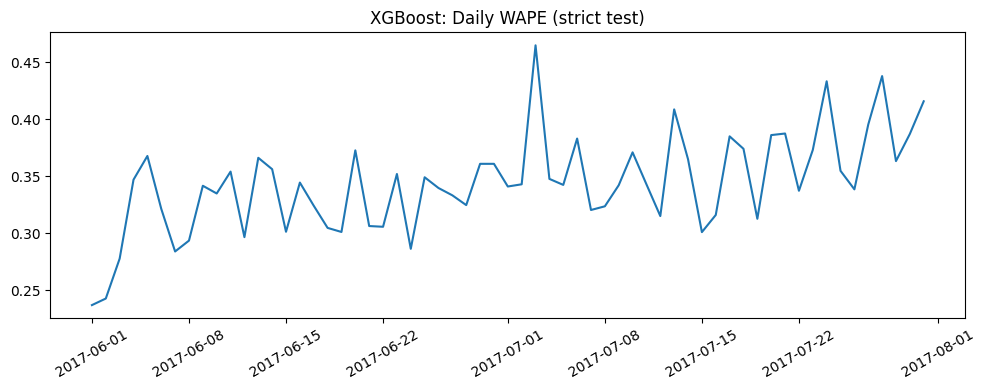


MODEL: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029452 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8953
[LightGBM] [Info] Number of data points in the train set: 159400, number of used features: 75
[LightGBM] [Info] Start training from score 2.976278
LightGBM-trial1 (CV 2017-03-09..2017-04-05): RMSE(log)=0.628867 | MAE(log)=0.413651 | R2=0.6622
LightGBM-trial1 (CV): MAE(sales)=12.4838 | RMSE(sales)=27.8331 | WAPE=0.3400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029934 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8935
[LightGBM] [Info] Number of data points in the train set: 165000, number of used features: 75
[LightGBM] [Info] Start training from score 2.977

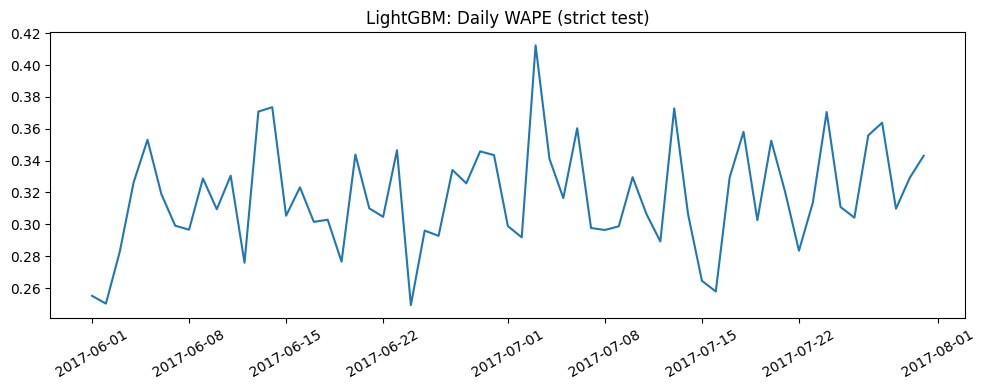


FINAL COMPARISON (STRICT TEST)
          model      rmse       mae        r2      wape
0           GBT  0.539885  0.373320  0.733060  0.302827
1      LightGBM  0.543269  0.386161  0.729703  0.315078
2       XGBoost  0.565513  0.414506  0.707115  0.343563
3  RandomForest  0.571960  0.400054  0.700399  0.332153
4         Ridge  0.578554  0.432439  0.693452  0.387882


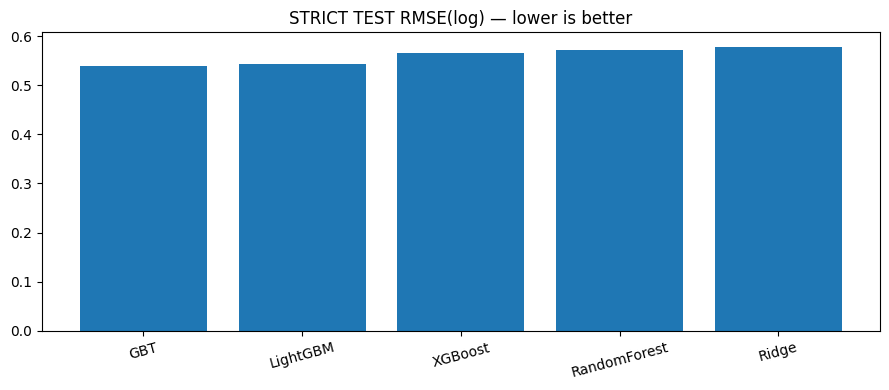


✅ Best model: GBT | RMSE(log)=0.539885 | WAPE=0.3028
✅ Saved best model to: output_tuned_strict/best_model.joblib

Forecast example (7 days ahead from last truth day):
        date  store_nbr  item_nbr  pred_log1p  pred_sales  promo
0 2017-08-22         45    115891    2.842238   16.154117      1
1 2017-08-22         45    153267    2.634244   12.932771      0
2 2017-08-22         45    158842    2.677463   13.548139      1
3 2017-08-22         45    164036    2.049552    6.764425      0
4 2017-08-22         45    164037    2.452017   10.611748      0

Done.


In [1]:
import os, glob, json, shutil, random
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import joblib

# --- Optional deps ---
HAVE_XGB = False
HAVE_LGBM = False
try:
    from xgboost import XGBRegressor
    HAVE_XGB = True
except Exception:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
    HAVE_LGBM = True
except Exception:
    LGBMRegressor = None


# ==============================
# USER SETTINGS
# ==============================
TRAIN_CUT = "2017-06-01"
TEST_CUT  = "2017-08-01"

START_DATE = "2015-01-01"
END_DATE_REQUESTED = "2017-08-16"       # will auto-trim to factual max date in train.csv (subset)
FORECAST_END_DATE   = "2017-08-31"      # calendar end for forecasting

K_FAMILIES = 5
K_STORES   = 1
TOP_ITEMS_PER_FAMILY = 40

# 1-step training + recursive forecasting (any n supported)
HORIZON = 1

LAGS = [1,2,3,4,5,6,7,14,28]
ROLL_WINDOWS = [3,7,14,28]
ROLL_INCLUDE_TODAY = True

USE_PROMO_TARGET = True          # allowed exogenous (if we have promo calendar)
USE_TRANSACTIONS_FEATURES = False
USE_OIL_FEATURES = True

# Target Encoding smoothing
TE_ALPHA = 20.0

# IO / chunking
CHUNKSIZE = 2_000_000
RANDOM_SEED = 42

# TUNING controls
DO_TUNING = True
TUNE_TRIALS = 12
CV_SPLITS = 3
CV_VAL_DAYS = 28
CV_MIN_TRAIN_DAYS = 365

# which model families to tune
TUNE_GBT = True
TUNE_XGB = True
TUNE_LGBM = True

# saving
SAVE_DIR = Path("./output_tuned_strict")
CLEAN_OUTPUTS = True
JOBLIB_COMPRESS = 3

# Kaggle base
BASE = "/kaggle/input"


# ==============================
# Helpers
# ==============================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

seed_everything(RANDOM_SEED)

def find_file(filename: str) -> str:
    for d in glob.glob(os.path.join(BASE, "*")):
        cand = os.path.join(d, filename)
        if os.path.exists(cand):
            return cand
    for root, _, files in os.walk(BASE):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find {filename} under {BASE}")

def min_date_str(a: str, b: str) -> str:
    return str(min(pd.to_datetime(a), pd.to_datetime(b)).date())

def clip_nonneg(x):
    return np.clip(np.asarray(x, dtype=float), 0.0, None)

def eval_log_metrics(y_true, y_pred, name=""):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_nonneg(y_pred)
    # IMPORTANT: this expects no NaNs
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    print(f"{name}: RMSE(log)={rmse:.6f} | MAE(log)={mae:.6f} | R2={r2:.4f}")
    return {"model": name, "rmse": rmse, "mae": mae, "r2": r2}

def eval_sales_metrics(y_true_log, y_pred_log, name=""):
    y_true_log = np.asarray(y_true_log, dtype=float)
    y_pred_log = clip_nonneg(y_pred_log)
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    abs_err = np.abs(y_pred - y_true)
    se = (y_pred - y_true) ** 2
    mae = float(abs_err.mean())
    rmse = float(np.sqrt(se.mean()))
    sae = float(abs_err.sum())
    sy = float(y_true.sum())
    wape = float(sae / (sy if sy > 0 else 1.0))
    print(f"{name}: MAE(sales)={mae:.4f} | RMSE(sales)={rmse:.4f} | WAPE={wape:.4f}")
    return {"mae_sales": mae, "rmse_sales": rmse, "wape": wape}

def plot_daily_wape(dates, y_true_log_2d, y_pred_log_2d, title):
    T = np.asarray(y_true_log_2d, dtype=float)
    P = np.asarray(y_pred_log_2d, dtype=float)
    y_true = np.expm1(T)
    y_pred = np.expm1(clip_nonneg(P))
    sae = np.abs(y_pred - y_true).sum(axis=1)
    sy = y_true.sum(axis=1)
    wape = sae / np.where(sy > 0, sy, 1.0)

    plt.figure(figsize=(10,4))
    plt.plot(dates, wape)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

def plot_compare_bar(rows, metric="rmse", title="Comparison"):
    df = pd.DataFrame(rows).copy().sort_values(metric)
    plt.figure(figsize=(9,4))
    plt.bar(df["model"], df[metric])
    plt.title(title)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
    return df

def parse_onpromotion_series(s: pd.Series) -> np.ndarray:
    return s.astype("string").fillna("false").str.lower().eq("true").astype(np.int8).values


# ==============================
# Paths
# ==============================
train_path  = find_file("train.csv")
items_path  = find_file("items.csv")
stores_path = find_file("stores.csv")
trans_path  = find_file("transactions.csv")
oil_path    = find_file("oil.csv")
hol_path    = find_file("holidays_events.csv")

test_path = None
try:
    test_path = find_file("test.csv")
except Exception:
    test_path = None

print("Paths OK")


# ==============================
# Load items/stores
# ==============================
items_full = pd.read_csv(items_path, usecols=["item_nbr","family","class","perishable"])
items_full["item_nbr"] = items_full["item_nbr"].astype(int)
items_full["family"] = items_full["family"].astype(str)
items_full["class"] = items_full["class"].astype(int)
items_full["perishable"] = items_full["perishable"].astype(int)

stores_full = pd.read_csv(stores_path, usecols=["store_nbr","city","state","type","cluster"])
stores_full = stores_full.rename(columns={"type":"store_type"})
stores_full["store_nbr"] = stores_full["store_nbr"].astype(int)
stores_full["cluster"] = stores_full["cluster"].astype(int)

item2family = dict(zip(items_full["item_nbr"].values, items_full["family"].values))

START_DT = pd.to_datetime(START_DATE)
TRAIN_CUT_DT = pd.to_datetime(TRAIN_CUT)
TEST_CUT_DT  = pd.to_datetime(TEST_CUT)
END_REQ_DT   = pd.to_datetime(END_DATE_REQUESTED)
FORECAST_END_REQ_DT = pd.to_datetime(FORECAST_END_DATE)


# ==========================================================
# Phase 1: subset selection (NO SNOOPING => only history < TRAIN_CUT)
# ==========================================================
print("\n--- Phase 1: Select subset (train-only history) ---")

usecols_min = ["date","store_nbr","item_nbr"]
chunk_kwargs_min = dict(
    chunksize=CHUNKSIZE,
    dtype={"store_nbr": "int32", "item_nbr": "int32"},
)

# 1) families by row counts in TRAIN history only
fam_counts = {}
for chunk in pd.read_csv(train_path, usecols=usecols_min, **chunk_kwargs_min):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] >= START_DT) & (chunk["date"] < TRAIN_CUT_DT)
    c = chunk.loc[m, ["item_nbr"]]
    if c.empty:
        continue
    fam = c["item_nbr"].map(item2family)
    vc = fam.value_counts(dropna=True)
    for k, v in vc.items():
        fam_counts[k] = fam_counts.get(k, 0) + int(v)

target_families = [k for k,_ in sorted(fam_counts.items(), key=lambda kv: kv[1], reverse=True)[:K_FAMILIES]]
print("Selected families:", target_families)

# 2) store by row counts for those families in TRAIN history only
store_counts = {}
for chunk in pd.read_csv(train_path, usecols=usecols_min, **chunk_kwargs_min):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] >= START_DT) & (chunk["date"] < TRAIN_CUT_DT)
    c = chunk.loc[m, ["store_nbr","item_nbr"]]
    if c.empty:
        continue
    fam = c["item_nbr"].map(item2family)
    c = c.loc[fam.isin(target_families)]
    if c.empty:
        continue
    vc = c["store_nbr"].value_counts()
    for k, v in vc.items():
        store_counts[int(k)] = store_counts.get(int(k), 0) + int(v)

target_stores = [k for k,_ in sorted(store_counts.items(), key=lambda kv: kv[1], reverse=True)[:K_STORES]]
print("Selected stores:", target_stores)

# 3) items per family by row counts for chosen store in TRAIN history only
item_counts = {fam:{} for fam in target_families}
for chunk in pd.read_csv(train_path, usecols=usecols_min, **chunk_kwargs_min):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] >= START_DT) & (chunk["date"] < TRAIN_CUT_DT)
    c = chunk.loc[m, ["store_nbr","item_nbr"]]
    if c.empty:
        continue
    c = c.loc[c["store_nbr"].isin(target_stores)]
    if c.empty:
        continue
    fam = c["item_nbr"].map(item2family)
    c = c.assign(family=fam)
    c = c.loc[c["family"].isin(target_families)]
    if c.empty:
        continue
    for fam_name, sub in c.groupby("family"):
        vc = sub["item_nbr"].value_counts()
        d = item_counts[fam_name]
        for item, v in vc.items():
            it = int(item)
            d[it] = d.get(it, 0) + int(v)

target_items = []
for fam_name in target_families:
    top_items = [k for k,_ in sorted(item_counts[fam_name].items(), key=lambda kv: kv[1], reverse=True)[:TOP_ITEMS_PER_FAMILY]]
    target_items.extend(top_items)

target_items = sorted(set(target_items))
print("Selected items:", len(target_items))

stores = stores_full.loc[stores_full["store_nbr"].isin(target_stores)].copy()
items  = items_full.loc[items_full["item_nbr"].isin(target_items)].copy()

STORE = int(target_stores[0])
items_list = sorted(target_items)
n_items = len(items_list)
item_to_j = {it: j for j, it in enumerate(items_list)}

store_row = stores.loc[stores["store_nbr"] == STORE].iloc[0]
store_city = str(store_row["city"])
store_state = str(store_row["state"])
store_cluster = int(store_row["cluster"])

item_class = dict(zip(items["item_nbr"].astype(int), items["class"].astype(int)))
item_perish = dict(zip(items["item_nbr"].astype(int), items["perishable"].astype(int)))
item_family = dict(zip(items["item_nbr"].astype(int), items["family"].astype(str)))


# ==========================================================
# Phase 2: build truth sales + promo calendar (strict)
# - truth sales available up to factual max date in train.csv (subset)
# - promo calendar can be extended by test.csv; else promo=0 beyond truth
# ==========================================================
print("\n--- Phase 2: Load subset daily sales/promo (chunked, array fill) ---")

# 2.1 find factual max date for subset (within requested end)
factual_max_date = None
for chunk in pd.read_csv(train_path, usecols=usecols_min, **chunk_kwargs_min):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] >= START_DT) & (chunk["date"] <= END_REQ_DT)
    c = chunk.loc[m]
    if c.empty:
        continue
    c = c.loc[(c["store_nbr"] == STORE) & (c["item_nbr"].isin(items_list))]
    if c.empty:
        continue
    mx = c["date"].max()
    factual_max_date = mx if factual_max_date is None else max(factual_max_date, mx)

if factual_max_date is None:
    raise RuntimeError("No rows found for the subset. Check STORE/items/dates.")

END_DATE_FACT = str(factual_max_date.date())
END_DATE_USED = min_date_str(END_DATE_REQUESTED, END_DATE_FACT)
END_USED_DT = pd.to_datetime(END_DATE_USED)

TRAIN_CUT_USED = min_date_str(TRAIN_CUT, END_DATE_USED)
TEST_CUT_USED  = min_date_str(TEST_CUT,  END_DATE_USED)

TRAIN_CUT_USED_DT = pd.to_datetime(TRAIN_CUT_USED)
TEST_CUT_USED_DT  = pd.to_datetime(TEST_CUT_USED)

STRICT_TEST_END_DT = min(END_USED_DT, TEST_CUT_USED_DT - pd.Timedelta(days=1))
if STRICT_TEST_END_DT < TRAIN_CUT_USED_DT:
    raise RuntimeError("Test window empty after trimming. Check cuts/end.")

FORECAST_END_USED_DT = max(STRICT_TEST_END_DT, FORECAST_END_REQ_DT)

print(f"END_DATE requested={END_DATE_REQUESTED} | factual_max={END_DATE_FACT} | using truth end={END_DATE_USED}")
print("Using cuts:", TRAIN_CUT_USED, TEST_CUT_USED)
print("Strict test range:", str(TRAIN_CUT_USED_DT.date()), "to", str(STRICT_TEST_END_DT.date()))
print("Forecast calendar until:", str(FORECAST_END_USED_DT.date()))

# Build full date index for calendar
dates_all = pd.date_range(START_DT, FORECAST_END_USED_DT, freq="D")
date_to_i = {pd.Timestamp(d): i for i, d in enumerate(dates_all)}
n_days_all = len(dates_all)

truth_end_i = date_to_i[pd.Timestamp(END_USED_DT)]

# Arrays:
sales_sum = np.zeros((truth_end_i + 1, n_items), dtype=np.float32)     # truth sales sum
promo_known = np.zeros((n_days_all, n_items), dtype=np.int8)          # promo known for whole calendar
y_true_log = np.full((n_days_all, n_items), np.nan, dtype=np.float32) # log1p truth (NaN beyond truth end)

usecols_train = ["date","store_nbr","item_nbr","unit_sales","onpromotion"]
chunk_kwargs_train = dict(
    chunksize=CHUNKSIZE,
    dtype={"store_nbr": "int32", "item_nbr": "int32", "onpromotion": "string"},
)

# 2.2 fill truth sales_sum + promo_known inside truth range
for chunk in pd.read_csv(train_path, usecols=usecols_train, **chunk_kwargs_train):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] >= START_DT) & (chunk["date"] <= END_USED_DT)
    c = chunk.loc[m]
    if c.empty:
        continue
    c = c.loc[(c["store_nbr"] == STORE) & (c["item_nbr"].isin(items_list))].copy()
    if c.empty:
        continue

    promo = parse_onpromotion_series(c["onpromotion"])
    sales = pd.to_numeric(c["unit_sales"], errors="coerce").fillna(0.0).astype(float)
    sales = np.clip(sales, 0.0, None)

    c["onpromotion_bool"] = promo
    c["unit_sales_clipped"] = sales

    grp = (c.groupby(["date","item_nbr"], as_index=False)
             .agg(sales_sum=("unit_sales_clipped","sum"),
                  promo_max=("onpromotion_bool","max")))

    for r in grp.itertuples(index=False):
        ii = date_to_i.get(pd.Timestamp(r.date), None)
        jj = item_to_j.get(int(r.item_nbr), None)
        if ii is None or jj is None:
            continue
        if ii <= truth_end_i:
            sales_sum[ii, jj] += float(r.sales_sum)
            promo_known[ii, jj] = max(promo_known[ii, jj], int(r.promo_max))

# 2.3 compute log1p truth (and keep zeros for missing rows inside truth)
y_true_log[:truth_end_i+1, :] = np.log1p(sales_sum.astype(np.float32))

# 2.4 promo calendar for future days beyond truth end from test.csv if present
if test_path is not None:
    try:
        tdf = pd.read_csv(
            test_path,
            usecols=["date","store_nbr","item_nbr","onpromotion"],
            dtype={"store_nbr":"int32","item_nbr":"int32","onpromotion":"string"}
        )
        tdf["date"] = pd.to_datetime(tdf["date"])
        tdf = tdf.loc[(tdf["store_nbr"] == STORE) & (tdf["item_nbr"].isin(items_list))].copy()
        tdf = tdf.loc[(tdf["date"] > END_USED_DT) & (tdf["date"] <= FORECAST_END_USED_DT)]
        if not tdf.empty:
            tdf["onpromotion_bool"] = parse_onpromotion_series(tdf["onpromotion"])
            for r in tdf[["date","item_nbr","onpromotion_bool"]].itertuples(index=False):
                ii = date_to_i.get(pd.Timestamp(r.date), None)
                jj = item_to_j.get(int(r.item_nbr), None)
                if ii is None or jj is None:
                    continue
                promo_known[ii, jj] = max(promo_known[ii, jj], int(r.onpromotion_bool))
    except Exception as e:
        print("⚠️ test.csv promo read failed -> promo beyond truth stays 0. Error:", str(e))

# Train end index:
train_end_date = TRAIN_CUT_USED_DT - pd.Timedelta(days=1)
if train_end_date < START_DT:
    raise RuntimeError("TRAIN_CUT too early vs START_DATE")
train_end_i = date_to_i[pd.Timestamp(train_end_date)]


# ==========================================================
# Phase 3: deterministic store-date features (calendar + holidays + oil/trx)
# ==========================================================
print("\n--- Phase 3: Build deterministic store-date features ---")

store_date = pd.DataFrame({"date": dates_all})
store_date["store_nbr"] = STORE

store_date["dow"] = store_date["date"].dt.dayofweek + 1
store_date["dom"] = store_date["date"].dt.day
store_date["month"] = store_date["date"].dt.month
store_date["weekofyear"] = store_date["date"].dt.isocalendar().week.astype(int)
store_date["doy"] = store_date["date"].dt.dayofyear
store_date["is_weekend"] = store_date["dow"].isin([6,7]).astype(int)
pi = float(np.pi)
store_date["sin_doy"] = np.sin((2*pi) * store_date["doy"] / 365.0)
store_date["cos_doy"] = np.cos((2*pi) * store_date["doy"] / 365.0)
store_date["time_idx"] = (store_date["date"] - START_DT).dt.days.astype(int)

# holidays store-specific
hol = pd.read_csv(hol_path)
hol["date"] = pd.to_datetime(hol["date"])
if "locale" not in hol.columns and "lacale" in hol.columns:
    hol = hol.rename(columns={"lacale":"locale"})
hol = hol.loc[(hol["date"] >= START_DT) & (hol["date"] <= FORECAST_END_USED_DT)].copy()

if "transferred" in hol.columns:
    hol["transferred"] = hol["transferred"].fillna(False).astype(bool)
    hol = hol.loc[hol["transferred"] == False].copy()

hol = hol[["date","type","locale","locale_name"]].copy()
hol["type"] = hol["type"].astype(str)
hol["locale"] = hol["locale"].astype(str)
hol["locale_name"] = hol["locale_name"].astype(str)

hol_nat = hol.loc[hol["locale"] == "National", ["date","type"]].copy()
hol_nat["store_nbr"] = STORE

hol_reg = hol.loc[(hol["locale"] == "Regional") & (hol["locale_name"] == store_state), ["date","type"]].copy()
hol_reg["store_nbr"] = STORE

hol_loc = hol.loc[(hol["locale"] == "Local") & (hol["locale_name"] == store_city), ["date","type"]].copy()
hol_loc["store_nbr"] = STORE

hol_store = pd.concat([hol_nat, hol_reg, hol_loc], ignore_index=True)

if hol_store.empty:
    holiday_features = pd.DataFrame({
        "date": dates_all,
        "store_nbr": STORE,
        "holiday_count":0,"is_holiday":0,"is_event":0,"is_additional":0,
        "is_bridge":0,"is_workday":0,"is_transfer":0
    })
else:
    holiday_features = (hol_store.groupby(["date","store_nbr"], as_index=False)
        .agg(
            holiday_count=("type","size"),
            is_holiday=("type", lambda s: int((s == "Holiday").any())),
            is_event=("type", lambda s: int((s == "Event").any())),
            is_additional=("type", lambda s: int((s == "Additional").any())),
            is_bridge=("type", lambda s: int((s == "Bridge").any())),
            is_workday=("type", lambda s: int((s == "Work Day").any())),
            is_transfer=("type", lambda s: int((s == "Transfer").any())),
        ))

store_date = store_date.merge(holiday_features, on=["date","store_nbr"], how="left").fillna(0)

# transactions (unknown future -> 0)
if USE_TRANSACTIONS_FEATURES:
    tr = pd.read_csv(trans_path, usecols=["date","store_nbr","transactions"])
    tr["date"] = pd.to_datetime(tr["date"])
    tr = tr.loc[(tr["date"] >= START_DT) & (tr["date"] <= FORECAST_END_USED_DT)]
    tr = tr.loc[tr["store_nbr"] == STORE].copy()
    tr["transactions"] = tr["transactions"].fillna(0).astype(int)
    store_date = store_date.merge(tr[["date","transactions"]], on="date", how="left")
    store_date["transactions"] = store_date["transactions"].fillna(0).astype(int)
else:
    store_date["transactions"] = 0

# oil (IMPORTANT: reindex + ffill; beyond last known oil -> ffill last)
# oil (ffill future) — FIX: keep 'date' column after reindex
if USE_OIL_FEATURES:
    oil = pd.read_csv(oil_path, usecols=["date", "dcoilwtico"])
    oil["date"] = pd.to_datetime(oil["date"])
    oil = oil.loc[(oil["date"] >= START_DT) & (oil["date"] <= FORECAST_END_USED_DT)].copy()

    # set index, reindex with a named DatetimeIndex -> reset_index will create 'date' column
    oil = oil.set_index("date").sort_index()
    oil = oil.reindex(pd.DatetimeIndex(dates_all, name="date"))

    oil["oil_ffill"] = oil["dcoilwtico"].ffill().fillna(0.0).astype(float)
    oil = oil.reset_index()[["date", "oil_ffill"]]

    store_date = store_date.merge(oil, on="date", how="left")
    store_date["oil_ffill"] = store_date["oil_ffill"].fillna(0.0).astype(float)
else:
    store_date["oil_ffill"] = 0.0


# rolling/lags for known exogenous
store_date = store_date.sort_values("date").reset_index(drop=True)
store_date["transactions_lag1"] = store_date["transactions"].shift(1).fillna(0).astype(float)
store_date["transactions_roll7"] = store_date["transactions"].rolling(7, min_periods=1).mean().astype(float)
store_date["transactions_roll28"] = store_date["transactions"].rolling(28, min_periods=1).mean().astype(float)

store_date["oil_lag1"] = store_date["oil_ffill"].shift(1).fillna(0.0).astype(float)
store_date["oil_roll7"] = store_date["oil_ffill"].rolling(7, min_periods=1).mean().astype(float)
store_date["oil_roll28"] = store_date["oil_ffill"].rolling(28, min_periods=1).mean().astype(float)

sd = store_date.set_index("date")
def sd_row(d: pd.Timestamp) -> pd.Series:
    return sd.loc[d]


# ==========================================================
# Phase 4: STRICT Time-aware Target Encoding (TRAIN only, and time-causal)
# - NO intra-train lookahead: global mean is computed from PAST ONLY
# - TE snapshot per day i uses days < i
# ==========================================================
print("\n--- Phase 4: Time-aware Target Encoding (TRAIN only, time-causal) ---")

alpha = float(TE_ALPHA)
families = sorted(set(target_families))
fam_to_idxs = {f: [item_to_j[it] for it in items_list if item_family.get(it, "UNKNOWN") == f] for f in families}

sum_item = np.zeros(n_items, dtype=np.float64)
sum_family = {f: 0.0 for f in families}
sum_global = 0.0  # total sum across items and days < i

te_item_origin = np.zeros((train_end_i+1, n_items), dtype=np.float32)     # day i uses history < i
te_family_origin = np.zeros((train_end_i+1, n_items), dtype=np.float32)
cnt_family_origin = np.zeros((train_end_i+1, n_items), dtype=np.int32)

for i in range(0, train_end_i+1):
    # global mean from PAST ONLY (days < i)
    if i == 0:
        global_mean_i = 0.0
    else:
        global_mean_i = sum_global / float(i * n_items)

    # per-item TE
    cnt_item = i
    te_item_origin[i, :] = ((sum_item + global_mean_i*alpha) / (cnt_item + alpha)).astype(np.float32)

    # per-family TE
    for f, idxs in fam_to_idxs.items():
        n_f = len(idxs)
        cnt_f = i * n_f
        te_f = (sum_family[f] + global_mean_i*alpha) / (cnt_f + alpha) if (cnt_f + alpha) > 0 else global_mean_i
        te_family_origin[i, idxs] = np.float32(te_f)
        cnt_family_origin[i, idxs] = cnt_f

    # update sums with TRUE day i
    y_day = y_true_log[i, :].astype(np.float64)  # guaranteed defined within truth
    sum_item += y_day
    sum_global += float(np.sum(y_day))
    for f, idxs in fam_to_idxs.items():
        sum_family[f] += float(np.sum(y_day[idxs]))

# For strict test/forecast: freeze TE at last TRAIN day origin (train_end_i), excluding same-day (days < train_end_i)
TE_FREEZE_I = train_end_i
TE_FROZEN_ITEM = te_item_origin[TE_FREEZE_I, :].copy()
TE_FROZEN_FAMILY = te_family_origin[TE_FREEZE_I, :].copy()
CNT_FROZEN_ITEM = int(TE_FREEZE_I)
CNT_FROZEN_FAMILY = cnt_family_origin[TE_FREEZE_I, :].copy()


# ==========================================================
# Phase 5: Build TRAIN dataset (H=1)
# ==========================================================
print("\n--- Phase 5: Build TRAIN dataset (H=1) ---")

# Build feature list WITHOUT duplicates
num_cols = [
    "horizon_cap","log1p_horizon_cap",
    "class","perishable","cluster",
    "label_today",
    "onpromotion_bool",
    "te_item","te_family",
    "log_cnt_item","log_cnt_family",
    "cnt_item","cnt_family",
]
if USE_PROMO_TARGET:
    num_cols.append("onpromotion_target")

num_cols += (
    [f"lag{lag}_label" for lag in LAGS] +
    [f"roll{rw}_mean_label" for rw in ROLL_WINDOWS] +
    [f"lag{lag}_promo" for lag in LAGS] +
    [f"roll{rw}_mean_promo" for rw in ROLL_WINDOWS] +
    ["dow_last4_mean_label","trend_7_28","trend_1_7"] +
    ["dow","dom","month","weekofyear","doy","is_weekend","sin_doy","cos_doy","time_idx",
     "holiday_count","is_holiday","is_event","is_additional","is_bridge","is_workday","is_transfer",
     "transactions_lag1","transactions_roll7","transactions_roll28",
     "oil_lag1","oil_roll7","oil_roll28"] +
    ["dow_t","dom_t","month_t","weekofyear_t","doy_t","is_weekend_t","sin_doy_t","cos_doy_t","time_idx_t",
     "holiday_count_t","is_holiday_t","is_event_t","is_additional_t","is_bridge_t","is_workday_t","is_transfer_t"]
)

# safety check
if len(num_cols) != len(set(num_cols)):
    dups = [c for c in num_cols if num_cols.count(c) > 1]
    raise RuntimeError(f"Duplicate feature columns detected: {sorted(set(dups))}")

col2k = {c:i for i,c in enumerate(num_cols)}
n_feat = len(num_cols)

train_origin_max_i = train_end_i - 1  # origin i -> target i+1 <= train_end_i
n_train_rows = (train_origin_max_i + 1) * n_items

X_train = np.zeros((n_train_rows, n_feat), dtype=np.float32)
y_train = np.zeros((n_train_rows,), dtype=np.float32)
origin_i_col = np.zeros((n_train_rows,), dtype=np.int32)  # for CV slicing

# dow last4 history (exclude today)
dow_hist = [ {d: deque(maxlen=4) for d in range(1,8)} for _ in range(n_items) ]

for i in range(0, train_origin_max_i + 1):
    origin_date = dates_all[i]
    target_date = dates_all[i+1]

    o = sd_row(origin_date)
    t = sd_row(target_date)

    o_vals = {
        "dow": int(o["dow"]), "dom": int(o["dom"]), "month": int(o["month"]), "weekofyear": int(o["weekofyear"]),
        "doy": int(o["doy"]), "is_weekend": int(o["is_weekend"]),
        "sin_doy": float(o["sin_doy"]), "cos_doy": float(o["cos_doy"]), "time_idx": int(o["time_idx"]),
        "holiday_count": int(o["holiday_count"]), "is_holiday": int(o["is_holiday"]), "is_event": int(o["is_event"]),
        "is_additional": int(o["is_additional"]), "is_bridge": int(o["is_bridge"]), "is_workday": int(o["is_workday"]),
        "is_transfer": int(o["is_transfer"]),
        "transactions_lag1": float(o["transactions_lag1"]), "transactions_roll7": float(o["transactions_roll7"]),
        "transactions_roll28": float(o["transactions_roll28"]),
        "oil_lag1": float(o["oil_lag1"]), "oil_roll7": float(o["oil_roll7"]), "oil_roll28": float(o["oil_roll28"]),
    }
    t_vals = {
        "dow_t": int(t["dow"]), "dom_t": int(t["dom"]), "month_t": int(t["month"]), "weekofyear_t": int(t["weekofyear"]),
        "doy_t": int(t["doy"]), "is_weekend_t": int(t["is_weekend"]),
        "sin_doy_t": float(t["sin_doy"]), "cos_doy_t": float(t["cos_doy"]), "time_idx_t": int(t["time_idx"]),
        "holiday_count_t": int(t["holiday_count"]), "is_holiday_t": int(t["is_holiday"]), "is_event_t": int(t["is_event"]),
        "is_additional_t": int(t["is_additional"]), "is_bridge_t": int(t["is_bridge"]), "is_workday_t": int(t["is_workday"]),
        "is_transfer_t": int(t["is_transfer"]),
    }
    origin_dow = int(o["dow"])

    for j, item in enumerate(items_list):
        r = i * n_items + j
        origin_i_col[r] = i

        y_t = float(y_true_log[i, j])
        y_tp1 = float(y_true_log[i+1, j])
        p_t = int(promo_known[i, j])
        p_tp1 = int(promo_known[i+1, j])

        y_train[r] = np.float32(y_tp1)

        X_train[r, col2k["horizon_cap"]] = 1.0
        X_train[r, col2k["log1p_horizon_cap"]] = float(np.log1p(1.0))
        X_train[r, col2k["cluster"]] = float(store_cluster)

        X_train[r, col2k["class"]] = float(item_class[item])
        X_train[r, col2k["perishable"]] = float(item_perish[item])

        X_train[r, col2k["label_today"]] = y_t
        X_train[r, col2k["onpromotion_bool"]] = float(p_t)

        te_i = float(te_item_origin[i, j])
        te_f = float(te_family_origin[i, j])
        cnt_i = int(i)
        cnt_f = int(cnt_family_origin[i, j])

        X_train[r, col2k["te_item"]] = te_i
        X_train[r, col2k["te_family"]] = te_f
        X_train[r, col2k["cnt_item"]] = float(cnt_i)
        X_train[r, col2k["cnt_family"]] = float(cnt_f)
        X_train[r, col2k["log_cnt_item"]] = float(np.log1p(cnt_i))
        X_train[r, col2k["log_cnt_family"]] = float(np.log1p(cnt_f))

        if USE_PROMO_TARGET:
            X_train[r, col2k["onpromotion_target"]] = float(p_tp1)

        # lags
        for lag in LAGS:
            y_l = float(y_true_log[i-lag, j]) if (i-lag) >= 0 else 0.0
            p_l = float(promo_known[i-lag, j]) if (i-lag) >= 0 else 0.0
            X_train[r, col2k[f"lag{lag}_label"]] = y_l
            X_train[r, col2k[f"lag{lag}_promo"]] = p_l

        # rolls
        for rw in ROLL_WINDOWS:
            if ROLL_INCLUDE_TODAY:
                a = max(0, i-rw+1); b = i+1
            else:
                a = max(0, i-rw); b = i
            if b <= a:
                y_m, p_m = 0.0, 0.0
            else:
                y_m = float(np.mean(y_true_log[a:b, j]))
                p_m = float(np.mean(promo_known[a:b, j]))
            X_train[r, col2k[f"roll{rw}_mean_label"]] = y_m
            X_train[r, col2k[f"roll{rw}_mean_promo"]] = p_m

        dq = dow_hist[j][origin_dow]
        X_train[r, col2k["dow_last4_mean_label"]] = float(np.mean(dq)) if len(dq) else 0.0

        lag7  = float(y_true_log[i-7, j]) if (i-7) >= 0 else 0.0
        lag28 = float(y_true_log[i-28, j]) if (i-28) >= 0 else 0.0
        lag1  = float(y_true_log[i-1, j]) if (i-1) >= 0 else 0.0
        X_train[r, col2k["trend_7_28"]] = lag7 - lag28
        X_train[r, col2k["trend_1_7"]]  = lag1 - lag7

        for k,v in o_vals.items():
            X_train[r, col2k[k]] = float(v)
        for k,v in t_vals.items():
            X_train[r, col2k[k]] = float(v)

    # update dow_hist with TRUE origin day
    for j in range(n_items):
        dow_hist[j][origin_dow].append(float(y_true_log[i, j]))

X_train_df = pd.DataFrame(X_train, columns=num_cols)
y_train = y_train.astype(np.float32)
print("Train dataset:", X_train_df.shape, "| y:", y_train.shape)


# ==========================================================
# STRICT recursive evaluator (used for CV + Test + Forecast)
# ==========================================================
def init_histories(as_of_i: int):
    """Initialize per-item histories using TRUE data up to as_of_i (inclusive)."""
    hist_len = max(max(LAGS)+2, max(ROLL_WINDOWS)+2, 60)
    start_i = max(0, as_of_i - hist_len + 1)

    # sanitize NaNs to 0 (in case user passes as_of beyond truth end)
    y_hist = []
    p_hist = []
    for j in range(n_items):
        ys = []
        ps = []
        for ii in range(start_i, as_of_i+1):
            v = float(y_true_log[ii, j]) if not np.isnan(y_true_log[ii, j]) else 0.0
            ys.append(v)
            ps.append(int(promo_known[ii, j]))
        y_hist.append(deque(ys, maxlen=hist_len))
        p_hist.append(deque(ps, maxlen=hist_len))

    dow_hist = [ {d: deque(maxlen=4) for d in range(1,8)} for _ in range(n_items) ]
    # fill dow history from days < as_of_i (exclude same-day)
    for ii in range(0, as_of_i):
        d = dates_all[ii]
        dow = int(sd_row(d)["dow"])
        for j in range(n_items):
            v = float(y_true_log[ii, j]) if not np.isnan(y_true_log[ii, j]) else 0.0
            dow_hist[j][dow].append(v)
    return y_hist, p_hist, dow_hist

def build_step_features(origin_i: int, target_i: int, y_hist, p_hist, dow_hist,
                        te_item_vec, te_family_vec, cnt_item_scalar, cnt_family_vec):
    """Build X (n_items x n_feat) for predicting target_i from origin_i, using histories + frozen TE snapshot."""
    origin_date = dates_all[origin_i]
    target_date = dates_all[target_i]
    o = sd_row(origin_date)
    t = sd_row(target_date)
    origin_dow = int(o["dow"])

    o_vals = {
        "dow": int(o["dow"]), "dom": int(o["dom"]), "month": int(o["month"]), "weekofyear": int(o["weekofyear"]),
        "doy": int(o["doy"]), "is_weekend": int(o["is_weekend"]),
        "sin_doy": float(o["sin_doy"]), "cos_doy": float(o["cos_doy"]), "time_idx": int(o["time_idx"]),
        "holiday_count": int(o["holiday_count"]), "is_holiday": int(o["is_holiday"]), "is_event": int(o["is_event"]),
        "is_additional": int(o["is_additional"]), "is_bridge": int(o["is_bridge"]), "is_workday": int(o["is_workday"]),
        "is_transfer": int(o["is_transfer"]),
        "transactions_lag1": float(o["transactions_lag1"]), "transactions_roll7": float(o["transactions_roll7"]),
        "transactions_roll28": float(o["transactions_roll28"]),
        "oil_lag1": float(o["oil_lag1"]), "oil_roll7": float(o["oil_roll7"]), "oil_roll28": float(o["oil_roll28"]),
    }
    t_vals = {
        "dow_t": int(t["dow"]), "dom_t": int(t["dom"]), "month_t": int(t["month"]), "weekofyear_t": int(t["weekofyear"]),
        "doy_t": int(t["doy"]), "is_weekend_t": int(t["is_weekend"]),
        "sin_doy_t": float(t["sin_doy"]), "cos_doy_t": float(t["cos_doy"]), "time_idx_t": int(t["time_idx"]),
        "holiday_count_t": int(t["holiday_count"]), "is_holiday_t": int(t["is_holiday"]), "is_event_t": int(t["is_event"]),
        "is_additional_t": int(t["is_additional"]), "is_bridge_t": int(t["is_bridge"]), "is_workday_t": int(t["is_workday"]),
        "is_transfer_t": int(t["is_transfer"]),
    }

    X = np.zeros((n_items, n_feat), dtype=np.float32)
    X[:, col2k["horizon_cap"]] = 1.0
    X[:, col2k["log1p_horizon_cap"]] = float(np.log1p(1.0))
    X[:, col2k["cluster"]] = float(store_cluster)

    for k,v in o_vals.items():
        X[:, col2k[k]] = float(v)
    for k,v in t_vals.items():
        X[:, col2k[k]] = float(v)

    for j, item in enumerate(items_list):
        X[j, col2k["class"]] = float(item_class[item])
        X[j, col2k["perishable"]] = float(item_perish[item])

        y_t = float(y_hist[j][-1]) if len(y_hist[j]) else 0.0
        p_t = float(p_hist[j][-1]) if len(p_hist[j]) else 0.0
        X[j, col2k["label_today"]] = y_t
        X[j, col2k["onpromotion_bool"]] = p_t

        X[j, col2k["te_item"]] = float(te_item_vec[j])
        X[j, col2k["te_family"]] = float(te_family_vec[j])
        X[j, col2k["cnt_item"]] = float(cnt_item_scalar)
        X[j, col2k["log_cnt_item"]] = float(np.log1p(cnt_item_scalar))

        cf = int(cnt_family_vec[j])
        X[j, col2k["cnt_family"]] = float(cf)
        X[j, col2k["log_cnt_family"]] = float(np.log1p(cf))

        if USE_PROMO_TARGET:
            X[j, col2k["onpromotion_target"]] = float(promo_known[target_i, j])

        for lag in LAGS:
            idx = -(lag+1)
            y_l = float(y_hist[j][idx]) if len(y_hist[j]) >= (lag+1) else 0.0
            p_l = float(p_hist[j][idx]) if len(p_hist[j]) >= (lag+1) else 0.0
            X[j, col2k[f"lag{lag}_label"]] = y_l
            X[j, col2k[f"lag{lag}_promo"]] = p_l

        for rw in ROLL_WINDOWS:
            if ROLL_INCLUDE_TODAY:
                tail = list(y_hist[j])[-rw:]
                tailp = list(p_hist[j])[-rw:]
            else:
                tail = list(y_hist[j])[-(rw+1):-1]
                tailp = list(p_hist[j])[-(rw+1):-1]
            X[j, col2k[f"roll{rw}_mean_label"]] = float(np.mean(tail)) if len(tail) else 0.0
            X[j, col2k[f"roll{rw}_mean_promo"]] = float(np.mean(tailp)) if len(tailp) else 0.0

        dq = dow_hist[j][origin_dow]
        X[j, col2k["dow_last4_mean_label"]] = float(np.mean(dq)) if len(dq) else 0.0

        lag7  = float(y_hist[j][-(7+1)]) if len(y_hist[j]) >= 8 else 0.0
        lag28 = float(y_hist[j][-(28+1)]) if len(y_hist[j]) >= 29 else 0.0
        lag1  = float(y_hist[j][-(1+1)]) if len(y_hist[j]) >= 2 else 0.0
        X[j, col2k["trend_7_28"]] = lag7 - lag28
        X[j, col2k["trend_1_7"]]  = lag1 - lag7

    return pd.DataFrame(X, columns=num_cols), origin_dow

def te_snapshot_for_asof(as_of_i: int):
    """
    Freeze TE as-of a given date index.
    IMPORTANT: to avoid leakage in CV, TE must be frozen to THAT split's as_of, not global train end.
    If as_of_i > train_end_i, we still freeze to train_end_i (train-only).
    """
    ref_i = min(as_of_i, TE_FREEZE_I)
    te_item_vec = te_item_origin[ref_i, :].copy()
    te_family_vec = te_family_origin[ref_i, :].copy()
    cnt_item_scalar = int(ref_i)
    cnt_family_vec = cnt_family_origin[ref_i, :].copy()
    return te_item_vec, te_family_vec, cnt_item_scalar, cnt_family_vec

def strict_recursive_predict(model, start_date, end_date, as_of_date):
    """
    Predict from start_date..end_date inclusive.
    as_of_date = last date with TRUE values allowed in history.
    STRICT rule enforced: start_date MUST equal as_of_date + 1 day (no gaps).
    During prediction window, we append predictions and NEVER use true y inside features.
    """
    start_date = pd.to_datetime(start_date)
    end_date   = pd.to_datetime(end_date)
    as_of_date = pd.to_datetime(as_of_date)

    if end_date < start_date:
        raise ValueError("end_date must be >= start_date")
    if start_date != as_of_date + pd.Timedelta(days=1):
        raise ValueError("STRICT: start_date must equal as_of_date + 1 day (to avoid feature gaps/leak).")
    if start_date < START_DT or end_date > dates_all.max():
        raise ValueError("Requested dates outside prepared calendar. Increase FORECAST_END_DATE.")

    as_of_i = date_to_i[pd.Timestamp(as_of_date)]
    y_hist, p_hist, dow_hist = init_histories(as_of_i)

    te_item_vec, te_family_vec, cnt_item_scalar, cnt_family_vec = te_snapshot_for_asof(as_of_i)

    dates_pred = pd.date_range(start_date, end_date, freq="D")
    preds = []
    trues = []
    dates_out = []

    for d in dates_pred:
        target_i = date_to_i[pd.Timestamp(d)]
        origin_i = target_i - 1

        X_step_df, origin_dow = build_step_features(
            origin_i, target_i, y_hist, p_hist, dow_hist,
            te_item_vec, te_family_vec, cnt_item_scalar, cnt_family_vec
        )
        y_pred = clip_nonneg(model.predict(X_step_df)).astype(np.float32)
        preds.append(y_pred)
        dates_out.append(pd.Timestamp(d))

        # true is only available inside truth range; else keep NaN (forecast)
        if target_i <= truth_end_i:
            y_true_day = y_true_log[target_i, :].astype(np.float32)
        else:
            y_true_day = np.full((n_items,), np.nan, dtype=np.float32)
        trues.append(y_true_day)

        # update dow history with origin day's y (the last element in y_hist)
        for j in range(n_items):
            y_origin = float(y_hist[j][-1]) if len(y_hist[j]) else 0.0
            dow_hist[j][origin_dow].append(y_origin)

        # append predicted day
        for j in range(n_items):
            y_hist[j].append(float(y_pred[j]))
            p_hist[j].append(int(promo_known[target_i, j]))

    P = np.vstack(preds)
    T = np.vstack(trues)
    return dates_out, T, P


# ==========================================================
# Baselines on strict test (for reference)
# ==========================================================
print("\n--- Baselines (STRICT TEST) ---")

test_dates = pd.date_range(TRAIN_CUT_USED_DT, STRICT_TEST_END_DT, freq="D")
as_of = TRAIN_CUT_USED_DT - pd.Timedelta(days=1)
as_of_i = date_to_i[pd.Timestamp(as_of)]
y_hist_b, p_hist_b, _ = init_histories(as_of_i)

preds_b = []
trues_b = []
for d in test_dates:
    target_i = date_to_i[pd.Timestamp(d)]
    y_pred = np.array([float(y_hist_b[j][-1]) for j in range(n_items)], dtype=np.float32)
    preds_b.append(y_pred)
    trues_b.append(y_true_log[target_i, :].astype(np.float32))
    for j in range(n_items):
        y_hist_b[j].append(float(y_pred[j]))
        p_hist_b[j].append(int(promo_known[target_i, j]))

P_b = np.vstack(preds_b)
T_b = np.vstack(trues_b)

_ = eval_log_metrics(T_b.ravel(), P_b.ravel(), "Baseline Persistence (TEST strict)")
_ = eval_sales_metrics(T_b.ravel(), P_b.ravel(), "Baseline Persistence (TEST strict)")
plot_daily_wape(list(test_dates), T_b, P_b, "Baseline Persistence: Daily WAPE (strict test)")


# ==========================================================
# Tuning: time splits inside TRAIN only (STRICT)
# ==========================================================
def build_cv_splits():
    """
    Build CV validation windows inside TRAIN (< TRAIN_CUT).
    Each split:
      - train uses targets < val_start
      - validate predicts val_start..val_end strictly (recursive), with as_of = val_start-1
    """
    train_last = TRAIN_CUT_USED_DT - pd.Timedelta(days=1)
    splits = []
    cursor_end = train_last
    min_train_start = START_DT + pd.Timedelta(days=CV_MIN_TRAIN_DAYS)

    for _ in range(CV_SPLITS):
        val_end = cursor_end
        val_start = val_end - pd.Timedelta(days=CV_VAL_DAYS-1)
        if val_start < min_train_start:
            break
        as_of = val_start - pd.Timedelta(days=1)
        splits.append((val_start, val_end, as_of))
        cursor_end = val_start - pd.Timedelta(days=1)

    return list(reversed(splits))

cv_splits = build_cv_splits()
print("\nCV splits (train-internal strict):")
if len(cv_splits) == 0:
    print("  (none) -> CV disabled (not enough history vs CV_MIN_TRAIN_DAYS).")
else:
    for a,b,asof in cv_splits:
        print("  val:", str(a.date()), "->", str(b.date()), "| as_of:", str(asof.date()))

def score_model_on_cv(model, model_name, X_df, y, origin_i_col):
    """Fit/evaluate model across CV splits. Return avg RMSE(log) and avg WAPE."""
    if len(cv_splits) == 0:
        return np.inf, np.inf

    rmses = []
    wapes = []

    for (val_start, val_end, as_of) in cv_splits:
        val_start_i = date_to_i[pd.Timestamp(val_start)]
        max_origin_train = val_start_i - 2  # target=i+1 < val_start => i <= val_start-2
        mask = origin_i_col <= max_origin_train

        Xtr = X_df.loc[mask]
        ytr = y[mask]
        model.fit(Xtr, ytr)

        dates_out, T, P = strict_recursive_predict(
            model=model,
            start_date=val_start,
            end_date=val_end,
            as_of_date=as_of
        )
        m = eval_log_metrics(T.ravel(), P.ravel(), f"{model_name} (CV {val_start.date()}..{val_end.date()})")
        s = eval_sales_metrics(T.ravel(), P.ravel(), f"{model_name} (CV)")
        rmses.append(m["rmse"])
        wapes.append(s["wape"])

    return float(np.mean(rmses)), float(np.mean(wapes))

def sample_params(space: dict) -> dict:
    out = {}
    for k, v in space.items():
        if isinstance(v, list):
            out[k] = random.choice(v)
        elif isinstance(v, tuple) and len(v)==2:
            lo, hi = v
            if isinstance(lo, int) and isinstance(hi, int):
                out[k] = random.randint(lo, hi)
            else:
                out[k] = float(lo + (hi-lo)*random.random())
        else:
            out[k] = v
    return out


# ==========================================================
# Model factories + parameter spaces
# ==========================================================
def make_ridge():
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", Ridge(alpha=0.01))
    ])

GBT_SPACE = {
    "max_depth": [4,5,6],
    "learning_rate": [0.03, 0.05, 0.07],
    "max_iter": [250, 350, 500],
    "min_samples_leaf": [50, 80, 120],
    "l2_regularization": [0.0, 0.1, 0.5, 1.0],
}

XGB_SPACE = {
    "n_estimators": [600, 900, 1200],
    "learning_rate": [0.02, 0.03, 0.05],
    "max_depth": [4,5,6],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [20, 40, 60],
    "reg_lambda": [1.0, 2.0, 4.0],
    "reg_alpha": [0.0, 0.5, 1.0],
}

LGBM_SPACE = {
    "n_estimators": [1200, 1800, 2400],
    "learning_rate": [0.02, 0.03, 0.05],
    "num_leaves": [31, 63, 127],
    "min_child_samples": [60, 100, 140],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_lambda": [1.0, 2.0, 4.0],
}

def make_gbt(params):
    return HistGradientBoostingRegressor(
        max_depth=int(params["max_depth"]),
        learning_rate=float(params["learning_rate"]),
        max_iter=int(params["max_iter"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        l2_regularization=float(params["l2_regularization"]),
        random_state=RANDOM_SEED
    )

def make_xgb(params):
    return XGBRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        colsample_bytree=float(params["colsample_bytree"]),
        min_child_weight=float(params["min_child_weight"]),
        reg_lambda=float(params["reg_lambda"]),
        reg_alpha=float(params["reg_alpha"]),
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_SEED
    )

def make_lgbm(params):
    return LGBMRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        num_leaves=int(params["num_leaves"]),
        min_child_samples=int(params["min_child_samples"]),
        subsample=float(params["subsample"]),
        colsample_bytree=float(params["colsample_bytree"]),
        reg_lambda=float(params["reg_lambda"]),
        random_state=RANDOM_SEED,
        n_jobs=-1
    )


# ==========================================================
# Phase 6-7: Train+Test each model (with optional tuning)
# ==========================================================
print("\n--- Phase 6-7: Train+Test each model (in order) ---")

def strict_test_for_model(mdl, name):
    as_of = TRAIN_CUT_USED_DT - pd.Timedelta(days=1)
    dates_out, T, P = strict_recursive_predict(
        model=mdl,
        start_date=TRAIN_CUT_USED_DT,
        end_date=STRICT_TEST_END_DT,
        as_of_date=as_of
    )
    m = eval_log_metrics(T.ravel(), P.ravel(), f"{name} (TEST strict recursive)")
    s = eval_sales_metrics(T.ravel(), P.ravel(), f"{name} (TEST strict recursive)")
    plot_daily_wape(dates_out, T, P, f"{name}: Daily WAPE (strict test)")
    return m, s

def tune_family(family_name, make_model_fn, space, trials):
    best_params = None
    best_rmse = np.inf
    best_wape = np.inf

    for t in range(trials):
        params = sample_params(space)
        mdl = make_model_fn(params)
        rmse, wape = score_model_on_cv(mdl, f"{family_name}-trial{t+1}", X_train_df, y_train, origin_i_col)
        print(f"  -> {family_name} trial {t+1}/{trials}: avg_CV_RMSE={rmse:.6f} | avg_CV_WAPE={wape:.4f} | params={params}")
        if rmse < best_rmse:
            best_rmse = rmse
            best_wape = wape
            best_params = params

    return best_params, float(best_rmse), float(best_wape)

results = []
trained_models = {}

# 1) Ridge
print("\n" + "="*70)
print("MODEL: Ridge (Linear)")
print("="*70)
lr = make_ridge()
lr.fit(X_train_df, y_train)
pred_tr = lr.predict(X_train_df)
_ = eval_log_metrics(y_train, pred_tr, "Ridge (train)")
m_te, s_te = strict_test_for_model(lr, "Ridge")
results.append({"model":"Ridge", "rmse":m_te["rmse"], "mae":m_te["mae"], "r2":m_te["r2"], "wape":s_te["wape"]})
trained_models["Ridge"] = lr

# 2) GBT
print("\n" + "="*70)
print("MODEL: HistGradientBoosting")
print("="*70)
if DO_TUNING and TUNE_GBT and len(cv_splits) > 0:
    gbt_params, cv_rmse, cv_wape = tune_family("GBT", make_gbt, GBT_SPACE, TUNE_TRIALS)
    print(f"✅ Best GBT params by CV: RMSE={cv_rmse:.6f} | WAPE={cv_wape:.4f} | {gbt_params}")
    gbt = make_gbt(gbt_params)
else:
    gbt = make_gbt({"max_depth":6,"learning_rate":0.05,"max_iter":350,"min_samples_leaf":80,"l2_regularization":0.1})

gbt.fit(X_train_df, y_train)
pred_tr = gbt.predict(X_train_df)
_ = eval_log_metrics(y_train, pred_tr, "GBT (train)")
m_te, s_te = strict_test_for_model(gbt, "GBT")
results.append({"model":"GBT", "rmse":m_te["rmse"], "mae":m_te["mae"], "r2":m_te["r2"], "wape":s_te["wape"]})
trained_models["GBT"] = gbt

# 3) RandomForest
print("\n" + "="*70)
print("MODEL: RandomForest")
print("="*70)
rf = RandomForestRegressor(
    n_estimators=350,
    max_depth=14,
    min_samples_leaf=60,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_SEED
)
rf.fit(X_train_df, y_train)
pred_tr = rf.predict(X_train_df)
_ = eval_log_metrics(y_train, pred_tr, "RandomForest (train)")
m_te, s_te = strict_test_for_model(rf, "RandomForest")
results.append({"model":"RandomForest", "rmse":m_te["rmse"], "mae":m_te["mae"], "r2":m_te["r2"], "wape":s_te["wape"]})
trained_models["RandomForest"] = rf

# 4) XGBoost
if HAVE_XGB:
    print("\n" + "="*70)
    print("MODEL: XGBoost")
    print("="*70)
    if DO_TUNING and TUNE_XGB and len(cv_splits) > 0:
        xgb_params, cv_rmse, cv_wape = tune_family("XGBoost", make_xgb, XGB_SPACE, TUNE_TRIALS)
        print(f"✅ Best XGB params by CV: RMSE={cv_rmse:.6f} | WAPE={cv_wape:.4f} | {xgb_params}")
        xgb = make_xgb(xgb_params)
    else:
        xgb = make_xgb({
            "n_estimators":900,"learning_rate":0.03,"max_depth":5,
            "subsample":0.8,"colsample_bytree":0.8,"min_child_weight":40,
            "reg_lambda":2.0,"reg_alpha":0.5
        })

    xgb.fit(X_train_df, y_train)
    pred_tr = xgb.predict(X_train_df)
    _ = eval_log_metrics(y_train, pred_tr, "XGBoost (train)")
    m_te, s_te = strict_test_for_model(xgb, "XGBoost")
    results.append({"model":"XGBoost", "rmse":m_te["rmse"], "mae":m_te["mae"], "r2":m_te["r2"], "wape":s_te["wape"]})
    trained_models["XGBoost"] = xgb
else:
    print("\n⚠️ XGBoost not installed -> skipping")

# 5) LightGBM
if HAVE_LGBM:
    print("\n" + "="*70)
    print("MODEL: LightGBM")
    print("="*70)
    if DO_TUNING and TUNE_LGBM and len(cv_splits) > 0:
        lgbm_params, cv_rmse, cv_wape = tune_family("LightGBM", make_lgbm, LGBM_SPACE, TUNE_TRIALS)
        print(f"✅ Best LGBM params by CV: RMSE={cv_rmse:.6f} | WAPE={cv_wape:.4f} | {lgbm_params}")
        lgbm = make_lgbm(lgbm_params)
    else:
        lgbm = make_lgbm({
            "n_estimators":1800,"learning_rate":0.03,"num_leaves":63,
            "min_child_samples":120,"subsample":0.8,"colsample_bytree":0.8,"reg_lambda":2.0
        })

    lgbm.fit(X_train_df, y_train)
    pred_tr = lgbm.predict(X_train_df)
    _ = eval_log_metrics(y_train, pred_tr, "LightGBM (train)")
    m_te, s_te = strict_test_for_model(lgbm, "LightGBM")
    results.append({"model":"LightGBM", "rmse":m_te["rmse"], "mae":m_te["mae"], "r2":m_te["r2"], "wape":s_te["wape"]})
    trained_models["LightGBM"] = lgbm
else:
    print("\n⚠️ LightGBM not installed -> skipping")


# ==========================================================
# Final comparison
# ==========================================================
print("\n" + "="*70)
print("FINAL COMPARISON (STRICT TEST)")
print("="*70)
df_cmp = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
print(df_cmp)

plot_compare_bar(results, metric="rmse", title="STRICT TEST RMSE(log) — lower is better")

best_row = df_cmp.iloc[0].to_dict()
BEST_NAME = best_row["model"]
BEST_MODEL = trained_models[BEST_NAME]
print(f"\n✅ Best model: {BEST_NAME} | RMSE(log)={best_row['rmse']:.6f} | WAPE={best_row['wape']:.4f}")


# ==========================================================
# Save
# ==========================================================
if CLEAN_OUTPUTS:
    shutil.rmtree(SAVE_DIR, ignore_errors=True)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

meta = {
    "best_model_name": BEST_NAME,
    "train_cut": TRAIN_CUT_USED,
    "test_cut": TEST_CUT_USED,
    "truth_end": END_DATE_USED,
    "strict_test_end": str(STRICT_TEST_END_DT.date()),
    "forecast_calendar_end": str(FORECAST_END_USED_DT.date()),
    "subset_store": STORE,
    "target_families": target_families,
    "n_items": int(n_items),
    "features": num_cols,
    "target_transform": "log1p",
    "evaluation": "STRICT recursive walk-forward (no sales leakage in features)",
    "note": "Promo uses train.csv and test.csv if available; else promo beyond truth assumed 0."
}
(SAVE_DIR / "model_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
joblib.dump(BEST_MODEL, SAVE_DIR / "best_model.joblib", compress=JOBLIB_COMPRESS)
print(f"✅ Saved best model to: {SAVE_DIR/'best_model.joblib'}")


# ==========================================================
# Forecast API: any day N or any target date (recursive)
# ==========================================================
def forecast_to_date(target_date, as_of_date=None, model=None):
    """
    Forecast for a specific target_date.
    as_of_date = last date treated as known truth for initializing history (default: END_USED_DT).
    Recursively simulates all days until target_date.
    Returns DataFrame of predictions for target_date (all items).
    """
    if model is None:
        model = BEST_MODEL
    if as_of_date is None:
        as_of_date = END_USED_DT  # last available truth day (trimmed)
    target_date = pd.to_datetime(target_date)
    as_of_date = pd.to_datetime(as_of_date)

    if target_date <= as_of_date:
        raise ValueError("target_date must be after as_of_date for forecasting.")
    if target_date > dates_all.max():
        raise ValueError("target_date beyond prepared calendar. Increase FORECAST_END_DATE.")

    start = as_of_date + pd.Timedelta(days=1)
    dates_out, T, P = strict_recursive_predict(model, start, target_date, as_of_date)

    pred_last_log = P[-1, :]
    out = pd.DataFrame({
        "date": [target_date]*n_items,
        "store_nbr": [STORE]*n_items,
        "item_nbr": items_list,
        "pred_log1p": pred_last_log.astype(float),
        "pred_sales": np.expm1(clip_nonneg(pred_last_log)).astype(float),
        "promo": promo_known[date_to_i[pd.Timestamp(target_date)], :].astype(int)
    })

    ti = date_to_i.get(pd.Timestamp(target_date))
    if ti is not None and ti <= truth_end_i:
        out["actual_sales"] = np.expm1(y_true_log[ti, :]).astype(float)

    return out.sort_values("item_nbr").reset_index(drop=True)

def forecast_n_days_ahead(n_days: int, as_of_date=None, model=None):
    """
    Forecast N days ahead from as_of_date (default: END_USED_DT).
    Returns predictions for that target day (all items).
    """
    if model is None:
        model = BEST_MODEL
    if as_of_date is None:
        as_of_date = END_USED_DT
    as_of_date = pd.to_datetime(as_of_date)
    target_date = as_of_date + pd.Timedelta(days=int(n_days))
    return forecast_to_date(target_date, as_of_date=as_of_date, model=model)

print("\nForecast example (7 days ahead from last truth day):")
ex1 = forecast_n_days_ahead(7)
print(ex1.head())

print("\nDone.")

Paths OK

--- Phase 1: Select subset (train-only history) ---
Selected families: ['GROCERY I', 'BEVERAGES', 'CLEANING', 'DAIRY', 'PRODUCE']
Selected stores: [44]
Selected items: 200

--- Phase 2: Auto-detect date range + load truth sales/promo ---
Auto date range for STORE=44: START_DT=2013-01-02 | factual END_USED_DT=2017-08-15
Using cuts (trimmed if needed): TRAIN_CUT_USED=2017-06-01 | TEST_CUT_USED=2017-08-01
Strict test range: 2017-06-01 -> 2017-07-31
Forecast calendar until: 2017-08-31

--- Phase 3: Build deterministic store-date features ---

--- Phase 4: Time-aware Target Encoding (TRAIN only, time-causal) ---

--- Phase 5: Build TRAIN dataset (H=1) ---
Train dataset: (322000, 81) | y: (322000,)

--- Baselines (STRICT TEST) ---
Baseline Persistence (TEST strict): RMSE(log)=0.807635 | MAE(log)=0.578688 | R2=0.4965
Baseline Persistence (TEST strict): MAE(sales)=22.4637 | RMSE(sales)=53.5116 | WAPE=0.5007


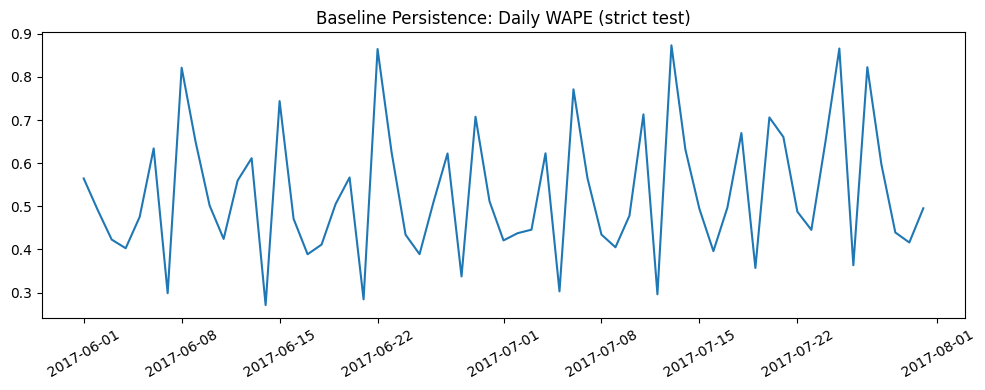


CV splits (train-internal strict):
  val: 2017-03-09 -> 2017-04-05 | as_of: 2017-03-08
  val: 2017-04-06 -> 2017-05-03 | as_of: 2017-04-05
  val: 2017-05-04 -> 2017-05-31 | as_of: 2017-05-03

--- Phase 6-7: Train+Test each model ---

MODEL: Ridge (Linear)
Ridge (train): RMSE(log)=0.525789 | MAE(log)=0.347512 | R2=0.8454
Ridge (TEST strict recursive): RMSE(log)=0.648757 | MAE(log)=0.477617 | R2=0.6751
Ridge (TEST strict recursive): MAE(sales)=20.7060 | RMSE(sales)=55.8125 | WAPE=0.4615


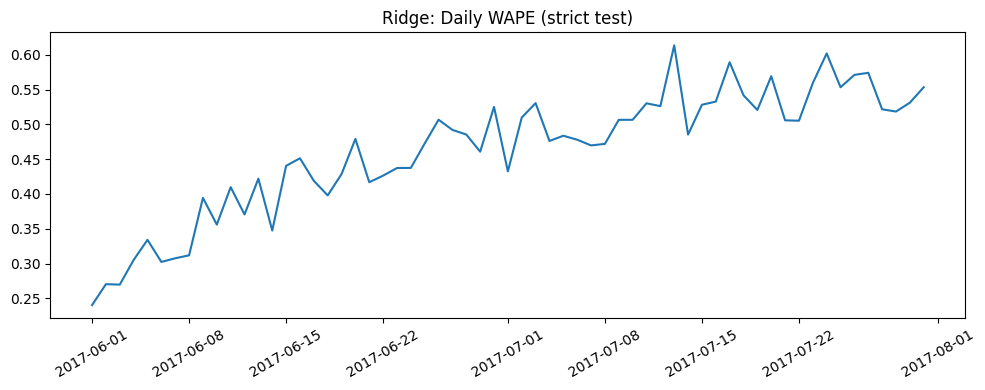


MODEL: HistGradientBoosting
GBT-trial1 (CV 2017-03-09..2017-04-05): RMSE(log)=0.526012 | MAE(log)=0.370839 | R2=0.7773
GBT-trial1 (CV): MAE(sales)=14.3975 | RMSE(sales)=36.3858 | WAPE=0.3193
GBT-trial1 (CV 2017-04-06..2017-05-03): RMSE(log)=0.553326 | MAE(log)=0.417732 | R2=0.7427
GBT-trial1 (CV): MAE(sales)=16.6580 | RMSE(sales)=38.9979 | WAPE=0.3796
GBT-trial1 (CV 2017-05-04..2017-05-31): RMSE(log)=0.552993 | MAE(log)=0.378825 | R2=0.7636
GBT-trial1 (CV): MAE(sales)=13.6387 | RMSE(sales)=36.3107 | WAPE=0.3123
  -> GBT trial 1/12: avg_CV_RMSE=0.544110 | avg_CV_WAPE=0.3371 | params={'max_depth': 6, 'learning_rate': 0.03, 'max_iter': 250, 'min_samples_leaf': 120, 'l2_regularization': 0.5}
GBT-trial2 (CV 2017-03-09..2017-04-05): RMSE(log)=0.544328 | MAE(log)=0.380435 | R2=0.7615
GBT-trial2 (CV): MAE(sales)=15.3114 | RMSE(sales)=38.6107 | WAPE=0.3395
GBT-trial2 (CV 2017-04-06..2017-05-03): RMSE(log)=0.518702 | MAE(log)=0.373997 | R2=0.7739
GBT-trial2 (CV): MAE(sales)=14.5868 | RMSE(sales

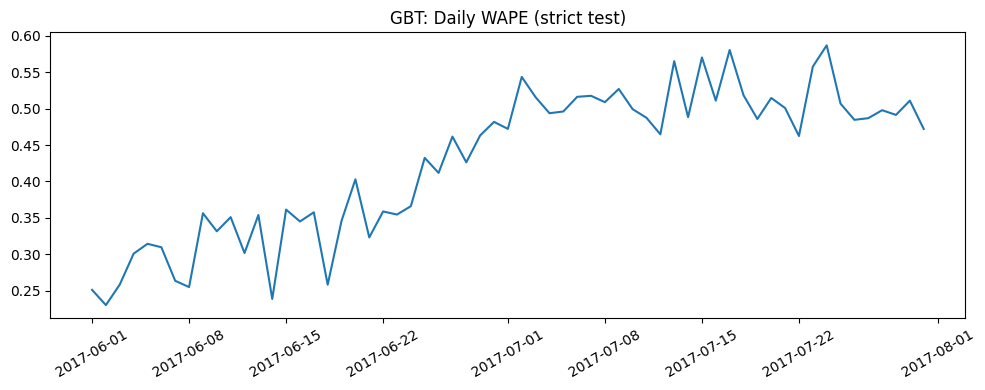


MODEL: RandomForest
RandomForest (train): RMSE(log)=0.467103 | MAE(log)=0.303476 | R2=0.8780
RandomForest (TEST strict recursive): RMSE(log)=0.609564 | MAE(log)=0.423604 | R2=0.7132
RandomForest (TEST strict recursive): MAE(sales)=15.2124 | RMSE(sales)=38.9270 | WAPE=0.3391


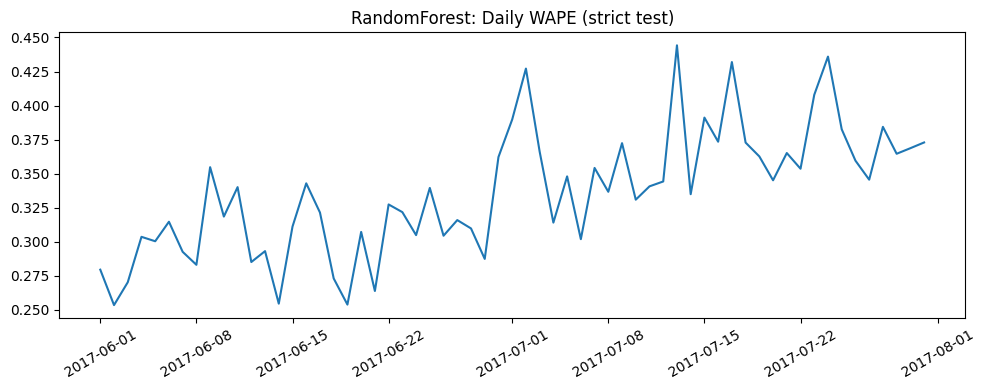


MODEL: XGBoost
XGBoost-trial1 (CV 2017-03-09..2017-04-05): RMSE(log)=0.520809 | MAE(log)=0.379554 | R2=0.7817
XGBoost-trial1 (CV): MAE(sales)=15.1037 | RMSE(sales)=38.0023 | WAPE=0.3349
XGBoost-trial1 (CV 2017-04-06..2017-05-03): RMSE(log)=0.522001 | MAE(log)=0.391982 | R2=0.7711
XGBoost-trial1 (CV): MAE(sales)=14.7341 | RMSE(sales)=34.0181 | WAPE=0.3357
XGBoost-trial1 (CV 2017-05-04..2017-05-31): RMSE(log)=0.551755 | MAE(log)=0.385700 | R2=0.7646
XGBoost-trial1 (CV): MAE(sales)=13.6204 | RMSE(sales)=34.7853 | WAPE=0.3119
  -> XGBoost trial 1/12: avg_CV_RMSE=0.531522 | avg_CV_WAPE=0.3275 | params={'n_estimators': 1200, 'learning_rate': 0.02, 'max_depth': 6, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 60, 'reg_lambda': 1.0, 'reg_alpha': 0.5}
XGBoost-trial2 (CV 2017-03-09..2017-04-05): RMSE(log)=0.538001 | MAE(log)=0.385750 | R2=0.7670
XGBoost-trial2 (CV): MAE(sales)=15.7610 | RMSE(sales)=41.4577 | WAPE=0.3495
XGBoost-trial2 (CV 2017-04-06..2017-05-03): RMSE(log)=0.56

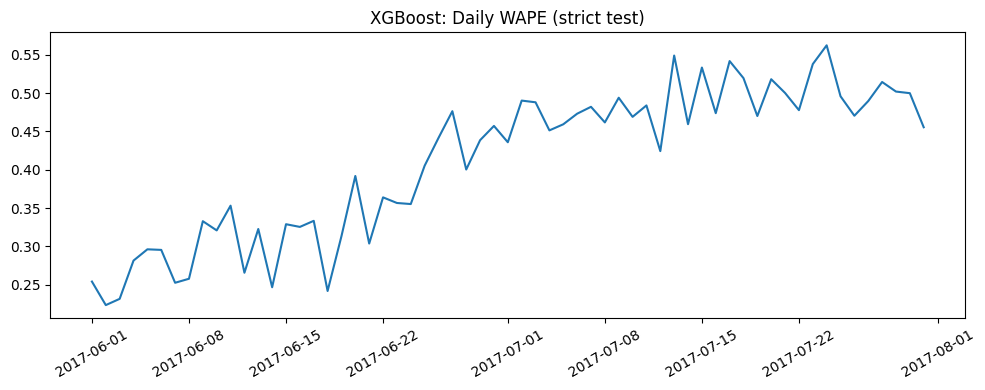


MODEL: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057681 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8890
[LightGBM] [Info] Number of data points in the train set: 305200, number of used features: 75
[LightGBM] [Info] Start training from score 2.939694
LightGBM-trial1 (CV 2017-03-09..2017-04-05): RMSE(log)=0.559824 | MAE(log)=0.422915 | R2=0.7477
LightGBM-trial1 (CV): MAE(sales)=16.7374 | RMSE(sales)=39.3178 | WAPE=0.3712
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8876
[LightGBM] [Info] Number of data points in the train set: 310800, number of used features: 75
[LightGBM] [Info] Start training from score 2.943

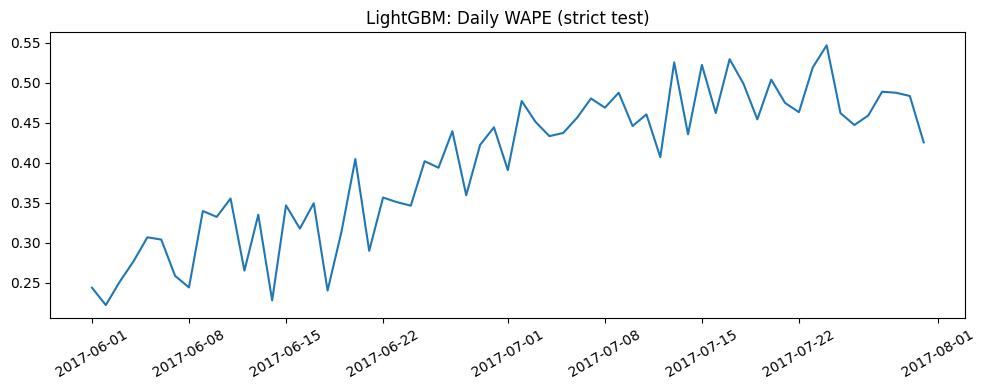


FINAL COMPARISON (STRICT TEST)
          model      rmse       mae        r2      wape
0  RandomForest  0.609564  0.423604  0.713178  0.339064
1         Ridge  0.648757  0.477617  0.675109  0.461510
2      LightGBM  0.680064  0.521977  0.642996  0.399945
3           GBT  0.680099  0.526124  0.642959  0.429815
4       XGBoost  0.717163  0.555278  0.602983  0.411324


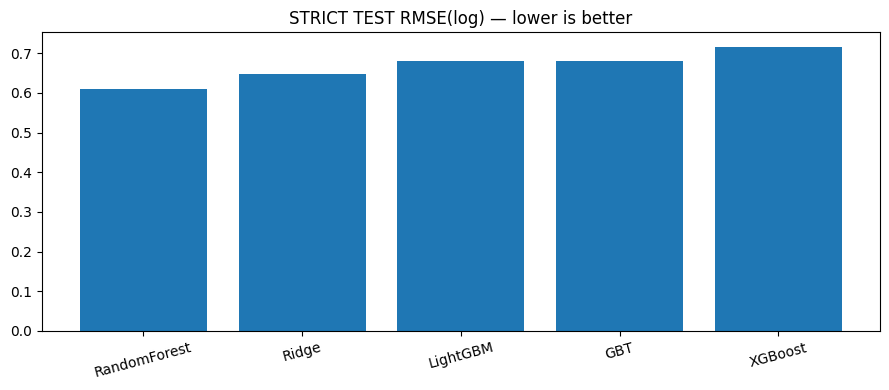


✅ Best model: RandomForest | RMSE(log)=0.609564 | WAPE=0.3391
✅ Saved best model to: output_tuned_strict/best_model.joblib

Forecast example: 7 days ahead from last truth date
        date  store_nbr  item_nbr  pred_log1p  pred_sales  promo
0 2017-08-22         44    105575    3.062072   20.371784      0
1 2017-08-22         44    108786    1.568136    3.797696      0
2 2017-08-22         44    108797    2.495713   11.130385      1
3 2017-08-22         44    114790    3.160810   22.589696      0
4 2017-08-22         44    115267    1.860488    5.426871      0

Done.


In [2]:


import os, glob, json, shutil, random
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import joblib

# --- Optional deps ---
HAVE_XGB = False
HAVE_LGBM = False
try:
    from xgboost import XGBRegressor
    HAVE_XGB = True
except Exception:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
    HAVE_LGBM = True
except Exception:
    LGBMRegressor = None


# ==============================
# USER SETTINGS (NO START/END HERE)
# ==============================
TRAIN_CUT = "2017-06-01"
TEST_CUT  = "2017-08-01"

K_FAMILIES = 5
K_STORES   = 1
TOP_ITEMS_PER_FAMILY = 40

# 1-step training + recursive forecasting
HORIZON = 1

LAGS = [1,2,3,4,5,6,7,14,28]
ROLL_WINDOWS = [3,7,14,28]
ROLL_INCLUDE_TODAY = True

USE_PROMO_TARGET = True
USE_TRANSACTIONS_FEATURES = False
USE_OIL_FEATURES = True

TE_ALPHA = 20.0

CHUNKSIZE = 2_000_000
RANDOM_SEED = 42

# TUNING controls
DO_TUNING = True
TUNE_TRIALS = 12
CV_SPLITS = 3
CV_VAL_DAYS = 28
CV_MIN_TRAIN_DAYS = 365

TUNE_GBT = True
TUNE_XGB = True
TUNE_LGBM = True

SAVE_DIR = Path("./output_tuned_strict")
CLEAN_OUTPUTS = True
JOBLIB_COMPRESS = 3

# Kaggle base
BASE = "/kaggle/input"


# ==============================
# Helpers
# ==============================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

seed_everything(RANDOM_SEED)

def find_file(filename: str) -> str:
    for d in glob.glob(os.path.join(BASE, "*")):
        cand = os.path.join(d, filename)
        if os.path.exists(cand):
            return cand
    for root, _, files in os.walk(BASE):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find {filename} under {BASE}")

def clip_nonneg(x):
    return np.clip(np.asarray(x, dtype=float), 0.0, None)

def eval_log_metrics(y_true, y_pred, name=""):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_nonneg(y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    print(f"{name}: RMSE(log)={rmse:.6f} | MAE(log)={mae:.6f} | R2={r2:.4f}")
    return {"model": name, "rmse": rmse, "mae": mae, "r2": r2}

def eval_sales_metrics(y_true_log, y_pred_log, name=""):
    y_true_log = np.asarray(y_true_log, dtype=float)
    y_pred_log = clip_nonneg(y_pred_log)
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    abs_err = np.abs(y_pred - y_true)
    se = (y_pred - y_true) ** 2
    mae = float(abs_err.mean())
    rmse = float(np.sqrt(se.mean()))
    sae = float(abs_err.sum())
    sy = float(y_true.sum())
    wape = float(sae / (sy if sy > 0 else 1.0))
    print(f"{name}: MAE(sales)={mae:.4f} | RMSE(sales)={rmse:.4f} | WAPE={wape:.4f}")
    return {"mae_sales": mae, "rmse_sales": rmse, "wape": wape}

def plot_daily_wape(dates, y_true_log_2d, y_pred_log_2d, title):
    T = np.asarray(y_true_log_2d, dtype=float)
    P = np.asarray(y_pred_log_2d, dtype=float)
    y_true = np.expm1(T)
    y_pred = np.expm1(clip_nonneg(P))
    sae = np.abs(y_pred - y_true).sum(axis=1)
    sy = y_true.sum(axis=1)
    wape = sae / np.where(sy > 0, sy, 1.0)

    plt.figure(figsize=(10,4))
    plt.plot(dates, wape)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

def plot_compare_bar(rows, metric="rmse", title="Comparison"):
    df = pd.DataFrame(rows).copy().sort_values(metric)
    plt.figure(figsize=(9,4))
    plt.bar(df["model"], df[metric])
    plt.title(title)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
    return df

def parse_onpromotion_series(s: pd.Series) -> np.ndarray:
    # handles strings/bools/nans safely
    return s.astype("string").fillna("false").str.lower().eq("true").astype(np.int8).values


# ==============================
# Paths
# ==============================
train_path  = find_file("train.csv")
items_path  = find_file("items.csv")
stores_path = find_file("stores.csv")
trans_path  = find_file("transactions.csv")
oil_path    = find_file("oil.csv")
hol_path    = find_file("holidays_events.csv")

test_path = None
try:
    test_path = find_file("test.csv")
except Exception:
    test_path = None

print("Paths OK")


# ==============================
# Load items/stores
# ==============================
items_full = pd.read_csv(items_path, usecols=["item_nbr","family","class","perishable"])
items_full["item_nbr"] = items_full["item_nbr"].astype(int)
items_full["family"] = items_full["family"].astype(str)
items_full["class"] = items_full["class"].astype(int)
items_full["perishable"] = items_full["perishable"].astype(int)

stores_full = pd.read_csv(stores_path, usecols=["store_nbr","city","state","type","cluster"])
stores_full = stores_full.rename(columns={"type":"store_type"})
stores_full["store_nbr"] = stores_full["store_nbr"].astype(int)
stores_full["cluster"] = stores_full["cluster"].astype(int)

item2family = dict(zip(items_full["item_nbr"].values, items_full["family"].values))

TRAIN_CUT_DT = pd.to_datetime(TRAIN_CUT)
TEST_CUT_DT  = pd.to_datetime(TEST_CUT)


# ==========================================================
# Phase 1: subset selection (NO SNOOPING => only history < TRAIN_CUT)
# ==========================================================
print("\n--- Phase 1: Select subset (train-only history) ---")

usecols_min = ["date","store_nbr","item_nbr"]
chunk_kwargs_min = dict(
    chunksize=CHUNKSIZE,
    dtype={"store_nbr": "int32", "item_nbr": "int32"},
)

# 1) families by row counts in TRAIN history only (date < TRAIN_CUT)
fam_counts = {}
for chunk in pd.read_csv(train_path, usecols=usecols_min, **chunk_kwargs_min):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] < TRAIN_CUT_DT)
    c = chunk.loc[m, ["item_nbr"]]
    if c.empty:
        continue
    fam = c["item_nbr"].map(item2family)
    vc = fam.value_counts(dropna=True)
    for k, v in vc.items():
        fam_counts[k] = fam_counts.get(k, 0) + int(v)

target_families = [k for k,_ in sorted(fam_counts.items(), key=lambda kv: kv[1], reverse=True)[:K_FAMILIES]]
print("Selected families:", target_families)

# 2) store by row counts for those families in TRAIN history only
store_counts = {}
for chunk in pd.read_csv(train_path, usecols=usecols_min, **chunk_kwargs_min):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] < TRAIN_CUT_DT)
    c = chunk.loc[m, ["store_nbr","item_nbr"]]
    if c.empty:
        continue
    fam = c["item_nbr"].map(item2family)
    c = c.loc[fam.isin(target_families)]
    if c.empty:
        continue
    vc = c["store_nbr"].value_counts()
    for k, v in vc.items():
        store_counts[int(k)] = store_counts.get(int(k), 0) + int(v)

target_stores = [k for k,_ in sorted(store_counts.items(), key=lambda kv: kv[1], reverse=True)[:K_STORES]]
print("Selected stores:", target_stores)

# 3) items per family by row counts for chosen store in TRAIN history only
item_counts = {fam:{} for fam in target_families}
for chunk in pd.read_csv(train_path, usecols=usecols_min, **chunk_kwargs_min):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] < TRAIN_CUT_DT)
    c = chunk.loc[m, ["store_nbr","item_nbr"]]
    if c.empty:
        continue
    c = c.loc[c["store_nbr"].isin(target_stores)]
    if c.empty:
        continue
    fam = c["item_nbr"].map(item2family)
    c = c.assign(family=fam)
    c = c.loc[c["family"].isin(target_families)]
    if c.empty:
        continue
    for fam_name, sub in c.groupby("family"):
        vc = sub["item_nbr"].value_counts()
        d = item_counts[fam_name]
        for item, v in vc.items():
            it = int(item)
            d[it] = d.get(it, 0) + int(v)

target_items = []
for fam_name in target_families:
    top_items = [k for k,_ in sorted(item_counts[fam_name].items(), key=lambda kv: kv[1], reverse=True)[:TOP_ITEMS_PER_FAMILY]]
    target_items.extend(top_items)

target_items = sorted(set(target_items))
print("Selected items:", len(target_items))

stores = stores_full.loc[stores_full["store_nbr"].isin(target_stores)].copy()
items  = items_full.loc[items_full["item_nbr"].isin(target_items)].copy()

STORE = int(target_stores[0])
items_list = sorted(target_items)
n_items = len(items_list)
item_to_j = {it: j for j, it in enumerate(items_list)}

store_row = stores.loc[stores["store_nbr"] == STORE].iloc[0]
store_city = str(store_row["city"])
store_state = str(store_row["state"])
store_cluster = int(store_row["cluster"])

item_class = dict(zip(items["item_nbr"].astype(int), items["class"].astype(int)))
item_perish = dict(zip(items["item_nbr"].astype(int), items["perishable"].astype(int)))
item_family = dict(zip(items["item_nbr"].astype(int), items["family"].astype(str)))


# ==========================================================
# Phase 2: AUTO-detect START_DT and factual END_USED_DT for this STORE+ITEMS
# + build truth sales + promo calendar (strict)
# ==========================================================
print("\n--- Phase 2: Auto-detect date range + load truth sales/promo ---")

# 2.0 detect min/max date for the subset (STORE + items_list) from train.csv
subset_min_date = None
subset_max_date = None

for chunk in pd.read_csv(train_path, usecols=usecols_min, **chunk_kwargs_min):
    chunk["date"] = pd.to_datetime(chunk["date"])
    c = chunk.loc[(chunk["store_nbr"] == STORE) & (chunk["item_nbr"].isin(items_list)), ["date"]]
    if c.empty:
        continue
    mn = c["date"].min()
    mx = c["date"].max()
    subset_min_date = mn if subset_min_date is None else min(subset_min_date, mn)
    subset_max_date = mx if subset_max_date is None else max(subset_max_date, mx)

if subset_min_date is None or subset_max_date is None:
    raise RuntimeError("No rows found for chosen STORE/items in train.csv. Check selection.")

START_DT = pd.to_datetime(subset_min_date.date())
END_USED_DT = pd.to_datetime(subset_max_date.date())

print(f"Auto date range for STORE={STORE}: START_DT={START_DT.date()} | factual END_USED_DT={END_USED_DT.date()}")

# auto-trim cuts if they exceed factual end (keeps logic stable)
TRAIN_CUT_USED_DT = min(pd.to_datetime(TRAIN_CUT), END_USED_DT + pd.Timedelta(days=1))
TEST_CUT_USED_DT  = min(pd.to_datetime(TEST_CUT),  END_USED_DT + pd.Timedelta(days=1))

# strict test end is min(factual end, TEST_CUT-1)
STRICT_TEST_END_DT = min(END_USED_DT, TEST_CUT_USED_DT - pd.Timedelta(days=1))

if STRICT_TEST_END_DT < TRAIN_CUT_USED_DT:
    raise RuntimeError(
        f"Test window empty after trimming.\n"
        f"TRAIN_CUT_USED={TRAIN_CUT_USED_DT.date()} | TEST_CUT_USED={TEST_CUT_USED_DT.date()} | END={END_USED_DT.date()}"
    )

print("Using cuts (trimmed if needed):",
      f"TRAIN_CUT_USED={TRAIN_CUT_USED_DT.date()} | TEST_CUT_USED={TEST_CUT_USED_DT.date()}")
print("Strict test range:",
      f"{TRAIN_CUT_USED_DT.date()} -> {STRICT_TEST_END_DT.date()}")

# Forecast calendar end: use max date from test.csv (promo calendar), else end at factual end
max_test_date = None
if test_path is not None:
    try:
        tmin = pd.read_csv(test_path, usecols=["date"], nrows=5)
        # we must scan properly for store/items, but that is heavy; do chunked scan minimal:
        test_cols = ["date","store_nbr","item_nbr"]
        for tchunk in pd.read_csv(test_path, usecols=test_cols, chunksize=CHUNKSIZE,
                                  dtype={"store_nbr":"int32","item_nbr":"int32"}):
            tchunk["date"] = pd.to_datetime(tchunk["date"])
            cc = tchunk.loc[(tchunk["store_nbr"] == STORE) & (tchunk["item_nbr"].isin(items_list)), ["date"]]
            if cc.empty:
                continue
            mx = cc["date"].max()
            max_test_date = mx if max_test_date is None else max(max_test_date, mx)
    except Exception:
        max_test_date = None

FORECAST_END_USED_DT = max(STRICT_TEST_END_DT, END_USED_DT)
if max_test_date is not None:
    FORECAST_END_USED_DT = max(FORECAST_END_USED_DT, pd.to_datetime(max_test_date.date()))

print("Forecast calendar until:", str(FORECAST_END_USED_DT.date()))

# Build full date index for calendar
dates_all = pd.date_range(START_DT, FORECAST_END_USED_DT, freq="D")
date_to_i = {pd.Timestamp(d): i for i, d in enumerate(dates_all)}
n_days_all = len(dates_all)

truth_end_i = date_to_i[pd.Timestamp(END_USED_DT)]

# Arrays:
sales_sum = np.zeros((truth_end_i + 1, n_items), dtype=np.float32)     # truth sales sum (only truth range)
promo_known = np.zeros((n_days_all, n_items), dtype=np.int8)          # promo known for whole calendar
y_true_log = np.full((n_days_all, n_items), np.nan, dtype=np.float32) # log1p truth (NaN beyond truth)

usecols_train = ["date","store_nbr","item_nbr","unit_sales","onpromotion"]
chunk_kwargs_train = dict(
    chunksize=CHUNKSIZE,
    dtype={"store_nbr": "int32", "item_nbr": "int32", "onpromotion": "string"},
)

# 2.1 fill truth sales_sum + promo_known inside truth range
for chunk in pd.read_csv(train_path, usecols=usecols_train, **chunk_kwargs_train):
    chunk["date"] = pd.to_datetime(chunk["date"])
    m = (chunk["date"] >= START_DT) & (chunk["date"] <= END_USED_DT)
    c = chunk.loc[m]
    if c.empty:
        continue
    c = c.loc[(c["store_nbr"] == STORE) & (c["item_nbr"].isin(items_list))].copy()
    if c.empty:
        continue

    promo = parse_onpromotion_series(c["onpromotion"])
    sales = pd.to_numeric(c["unit_sales"], errors="coerce").fillna(0.0).astype(float)
    sales = np.clip(sales, 0.0, None)

    c["onpromotion_bool"] = promo
    c["unit_sales_clipped"] = sales

    grp = (c.groupby(["date","item_nbr"], as_index=False)
             .agg(sales_sum=("unit_sales_clipped","sum"),
                  promo_max=("onpromotion_bool","max")))

    for r in grp.itertuples(index=False):
        ii = date_to_i.get(pd.Timestamp(r.date), None)
        jj = item_to_j.get(int(r.item_nbr), None)
        if ii is None or jj is None:
            continue
        if ii <= truth_end_i:
            sales_sum[ii, jj] += float(r.sales_sum)
            promo_known[ii, jj] = max(promo_known[ii, jj], int(r.promo_max))

# 2.2 compute log1p truth
y_true_log[:truth_end_i+1, :] = np.log1p(sales_sum.astype(np.float32))

# 2.3 promo beyond truth end from test.csv if present
if test_path is not None:
    try:
        tdf = pd.read_csv(
            test_path,
            usecols=["date","store_nbr","item_nbr","onpromotion"],
            dtype={"store_nbr":"int32","item_nbr":"int32","onpromotion":"string"}
        )
        tdf["date"] = pd.to_datetime(tdf["date"])
        tdf = tdf.loc[(tdf["store_nbr"] == STORE) & (tdf["item_nbr"].isin(items_list))].copy()
        tdf = tdf.loc[(tdf["date"] > END_USED_DT) & (tdf["date"] <= FORECAST_END_USED_DT)]
        if not tdf.empty:
            tdf["onpromotion_bool"] = parse_onpromotion_series(tdf["onpromotion"])
            for r in tdf[["date","item_nbr","onpromotion_bool"]].itertuples(index=False):
                ii = date_to_i.get(pd.Timestamp(r.date), None)
                jj = item_to_j.get(int(r.item_nbr), None)
                if ii is None or jj is None:
                    continue
                promo_known[ii, jj] = max(promo_known[ii, jj], int(r.onpromotion_bool))
    except Exception as e:
        print("⚠️ test.csv promo read failed -> promo beyond truth stays 0. Error:", str(e))

# Train end index
train_end_date = TRAIN_CUT_USED_DT - pd.Timedelta(days=1)
if train_end_date < START_DT:
    raise RuntimeError(f"TRAIN_CUT_USED ({TRAIN_CUT_USED_DT.date()}) too early vs START_DT ({START_DT.date()}).")
train_end_i = date_to_i[pd.Timestamp(train_end_date)]


# ==========================================================
# Phase 3: deterministic store-date features (calendar + holidays + oil/trx)
# ==========================================================
print("\n--- Phase 3: Build deterministic store-date features ---")

store_date = pd.DataFrame({"date": dates_all})
store_date["store_nbr"] = STORE

store_date["dow"] = store_date["date"].dt.dayofweek + 1
store_date["dom"] = store_date["date"].dt.day
store_date["month"] = store_date["date"].dt.month
store_date["weekofyear"] = store_date["date"].dt.isocalendar().week.astype(int)
store_date["doy"] = store_date["date"].dt.dayofyear
store_date["is_weekend"] = store_date["dow"].isin([6,7]).astype(int)
pi = float(np.pi)
store_date["sin_doy"] = np.sin((2*pi) * store_date["doy"] / 365.0)
store_date["cos_doy"] = np.cos((2*pi) * store_date["doy"] / 365.0)
store_date["time_idx"] = (store_date["date"] - START_DT).dt.days.astype(int)

# holidays store-specific
hol = pd.read_csv(hol_path)
hol["date"] = pd.to_datetime(hol["date"])
if "locale" not in hol.columns and "lacale" in hol.columns:
    hol = hol.rename(columns={"lacale":"locale"})
hol = hol.loc[(hol["date"] >= START_DT) & (hol["date"] <= FORECAST_END_USED_DT)].copy()

if "transferred" in hol.columns:
    hol["transferred"] = hol["transferred"].fillna(False).astype(bool)
    hol = hol.loc[hol["transferred"] == False].copy()

hol = hol[["date","type","locale","locale_name"]].copy()
hol["type"] = hol["type"].astype(str)
hol["locale"] = hol["locale"].astype(str)
hol["locale_name"] = hol["locale_name"].astype(str)

hol_nat = hol.loc[hol["locale"] == "National", ["date","type"]].copy()
hol_nat["store_nbr"] = STORE

hol_reg = hol.loc[(hol["locale"] == "Regional") & (hol["locale_name"] == store_state), ["date","type"]].copy()
hol_reg["store_nbr"] = STORE

hol_loc = hol.loc[(hol["locale"] == "Local") & (hol["locale_name"] == store_city), ["date","type"]].copy()
hol_loc["store_nbr"] = STORE

hol_store = pd.concat([hol_nat, hol_reg, hol_loc], ignore_index=True)

if hol_store.empty:
    holiday_features = pd.DataFrame({
        "date": dates_all,
        "store_nbr": STORE,
        "holiday_count":0,"is_holiday":0,"is_event":0,"is_additional":0,
        "is_bridge":0,"is_workday":0,"is_transfer":0
    })
else:
    holiday_features = (hol_store.groupby(["date","store_nbr"], as_index=False)
        .agg(
            holiday_count=("type","size"),
            is_holiday=("type", lambda s: int((s == "Holiday").any())),
            is_event=("type", lambda s: int((s == "Event").any())),
            is_additional=("type", lambda s: int((s == "Additional").any())),
            is_bridge=("type", lambda s: int((s == "Bridge").any())),
            is_workday=("type", lambda s: int((s == "Work Day").any())),
            is_transfer=("type", lambda s: int((s == "Transfer").any())),
        ))

store_date = store_date.merge(holiday_features, on=["date","store_nbr"], how="left").fillna(0)

# transactions (unknown future -> 0)
if USE_TRANSACTIONS_FEATURES:
    tr = pd.read_csv(trans_path, usecols=["date","store_nbr","transactions"])
    tr["date"] = pd.to_datetime(tr["date"])
    tr = tr.loc[(tr["date"] >= START_DT) & (tr["date"] <= FORECAST_END_USED_DT)]
    tr = tr.loc[tr["store_nbr"] == STORE].copy()
    tr["transactions"] = tr["transactions"].fillna(0).astype(int)
    store_date = store_date.merge(tr[["date","transactions"]], on="date", how="left")
    store_date["transactions"] = store_date["transactions"].fillna(0).astype(int)
else:
    store_date["transactions"] = 0

# oil (ffill future) — FIX: keep 'date' column after reindex
if USE_OIL_FEATURES:
    oil = pd.read_csv(oil_path, usecols=["date", "dcoilwtico"])
    oil["date"] = pd.to_datetime(oil["date"])
    oil = oil.loc[(oil["date"] >= START_DT) & (oil["date"] <= FORECAST_END_USED_DT)].copy()

    oil = oil.set_index("date").sort_index()
    oil = oil.reindex(pd.DatetimeIndex(dates_all, name="date"))
    oil["oil_ffill"] = oil["dcoilwtico"].ffill().fillna(0.0).astype(float)
    oil = oil.reset_index()[["date", "oil_ffill"]]

    store_date = store_date.merge(oil, on="date", how="left")
    store_date["oil_ffill"] = store_date["oil_ffill"].fillna(0.0).astype(float)
else:
    store_date["oil_ffill"] = 0.0

# rolling/lags for exogenous
store_date = store_date.sort_values("date").reset_index(drop=True)
store_date["transactions_lag1"] = store_date["transactions"].shift(1).fillna(0).astype(float)
store_date["transactions_roll7"] = store_date["transactions"].rolling(7, min_periods=1).mean().astype(float)
store_date["transactions_roll28"] = store_date["transactions"].rolling(28, min_periods=1).mean().astype(float)

store_date["oil_lag1"] = store_date["oil_ffill"].shift(1).fillna(0.0).astype(float)
store_date["oil_roll7"] = store_date["oil_ffill"].rolling(7, min_periods=1).mean().astype(float)
store_date["oil_roll28"] = store_date["oil_ffill"].rolling(28, min_periods=1).mean().astype(float)

sd = store_date.set_index("date")
def sd_row(d: pd.Timestamp) -> pd.Series:
    return sd.loc[d]


# ==========================================================
# Phase 4: STRICT Time-aware Target Encoding (TRAIN only, time-causal)
# ==========================================================
print("\n--- Phase 4: Time-aware Target Encoding (TRAIN only, time-causal) ---")

alpha = float(TE_ALPHA)
families = sorted(set(target_families))
fam_to_idxs = {f: [item_to_j[it] for it in items_list if item_family.get(it, "UNKNOWN") == f] for f in families}

sum_item = np.zeros(n_items, dtype=np.float64)
sum_family = {f: 0.0 for f in families}
sum_global = 0.0

te_item_origin = np.zeros((train_end_i+1, n_items), dtype=np.float32)
te_family_origin = np.zeros((train_end_i+1, n_items), dtype=np.float32)
cnt_family_origin = np.zeros((train_end_i+1, n_items), dtype=np.int32)

for i in range(0, train_end_i+1):
    if i == 0:
        global_mean_i = 0.0
    else:
        global_mean_i = sum_global / float(i * n_items)

    cnt_item = i
    te_item_origin[i, :] = ((sum_item + global_mean_i*alpha) / (cnt_item + alpha)).astype(np.float32)

    for f, idxs in fam_to_idxs.items():
        n_f = len(idxs)
        cnt_f = i * n_f
        te_f = (sum_family[f] + global_mean_i*alpha) / (cnt_f + alpha) if (cnt_f + alpha) > 0 else global_mean_i
        te_family_origin[i, idxs] = np.float32(te_f)
        cnt_family_origin[i, idxs] = cnt_f

    y_day = y_true_log[i, :].astype(np.float64)
    sum_item += y_day
    sum_global += float(np.sum(y_day))
    for f, idxs in fam_to_idxs.items():
        sum_family[f] += float(np.sum(y_day[idxs]))

TE_FREEZE_I = train_end_i
CNT_FROZEN_ITEM = int(TE_FREEZE_I)


# ==========================================================
# Phase 5: Build TRAIN dataset (H=1)
# ==========================================================
print("\n--- Phase 5: Build TRAIN dataset (H=1) ---")

num_cols = [
    "horizon_cap","log1p_horizon_cap",
    "class","perishable","cluster",
    "label_today",
    "onpromotion_bool",
    "te_item","te_family",
    "log_cnt_item","log_cnt_family",
    "cnt_item","cnt_family",
]
if USE_PROMO_TARGET:
    num_cols.append("onpromotion_target")

num_cols += (
    [f"lag{lag}_label" for lag in LAGS] +
    [f"roll{rw}_mean_label" for rw in ROLL_WINDOWS] +
    [f"lag{lag}_promo" for lag in LAGS] +
    [f"roll{rw}_mean_promo" for rw in ROLL_WINDOWS] +
    ["dow_last4_mean_label","trend_7_28","trend_1_7"] +
    ["dow","dom","month","weekofyear","doy","is_weekend","sin_doy","cos_doy","time_idx",
     "holiday_count","is_holiday","is_event","is_additional","is_bridge","is_workday","is_transfer",
     "transactions_lag1","transactions_roll7","transactions_roll28",
     "oil_lag1","oil_roll7","oil_roll28"] +
    ["dow_t","dom_t","month_t","weekofyear_t","doy_t","is_weekend_t","sin_doy_t","cos_doy_t","time_idx_t",
     "holiday_count_t","is_holiday_t","is_event_t","is_additional_t","is_bridge_t","is_workday_t","is_transfer_t"]
)

if len(num_cols) != len(set(num_cols)):
    dups = [c for c in num_cols if num_cols.count(c) > 1]
    raise RuntimeError(f"Duplicate feature columns detected: {sorted(set(dups))}")

col2k = {c:i for i,c in enumerate(num_cols)}
n_feat = len(num_cols)

train_origin_max_i = train_end_i - 1
n_train_rows = (train_origin_max_i + 1) * n_items

X_train = np.zeros((n_train_rows, n_feat), dtype=np.float32)
y_train = np.zeros((n_train_rows,), dtype=np.float32)
origin_i_col = np.zeros((n_train_rows,), dtype=np.int32)

dow_hist = [ {d: deque(maxlen=4) for d in range(1,8)} for _ in range(n_items) ]

for i in range(0, train_origin_max_i + 1):
    origin_date = dates_all[i]
    target_date = dates_all[i+1]

    o = sd_row(origin_date)
    t = sd_row(target_date)

    o_vals = {
        "dow": int(o["dow"]), "dom": int(o["dom"]), "month": int(o["month"]), "weekofyear": int(o["weekofyear"]),
        "doy": int(o["doy"]), "is_weekend": int(o["is_weekend"]),
        "sin_doy": float(o["sin_doy"]), "cos_doy": float(o["cos_doy"]), "time_idx": int(o["time_idx"]),
        "holiday_count": int(o["holiday_count"]), "is_holiday": int(o["is_holiday"]), "is_event": int(o["is_event"]),
        "is_additional": int(o["is_additional"]), "is_bridge": int(o["is_bridge"]), "is_workday": int(o["is_workday"]),
        "is_transfer": int(o["is_transfer"]),
        "transactions_lag1": float(o["transactions_lag1"]), "transactions_roll7": float(o["transactions_roll7"]),
        "transactions_roll28": float(o["transactions_roll28"]),
        "oil_lag1": float(o["oil_lag1"]), "oil_roll7": float(o["oil_roll7"]), "oil_roll28": float(o["oil_roll28"]),
    }
    t_vals = {
        "dow_t": int(t["dow"]), "dom_t": int(t["dom"]), "month_t": int(t["month"]), "weekofyear_t": int(t["weekofyear"]),
        "doy_t": int(t["doy"]), "is_weekend_t": int(t["is_weekend"]),
        "sin_doy_t": float(t["sin_doy"]), "cos_doy_t": float(t["cos_doy"]), "time_idx_t": int(t["time_idx"]),
        "holiday_count_t": int(t["holiday_count"]), "is_holiday_t": int(t["is_holiday"]), "is_event_t": int(t["is_event"]),
        "is_additional_t": int(t["is_additional"]), "is_bridge_t": int(t["is_bridge"]), "is_workday_t": int(t["is_workday"]),
        "is_transfer_t": int(t["is_transfer"]),
    }
    origin_dow = int(o["dow"])

    for j, item in enumerate(items_list):
        r = i * n_items + j
        origin_i_col[r] = i

        y_t = float(y_true_log[i, j])
        y_tp1 = float(y_true_log[i+1, j])
        p_t = int(promo_known[i, j])
        p_tp1 = int(promo_known[i+1, j])

        y_train[r] = np.float32(y_tp1)

        X_train[r, col2k["horizon_cap"]] = 1.0
        X_train[r, col2k["log1p_horizon_cap"]] = float(np.log1p(1.0))
        X_train[r, col2k["cluster"]] = float(store_cluster)

        X_train[r, col2k["class"]] = float(item_class[item])
        X_train[r, col2k["perishable"]] = float(item_perish[item])

        X_train[r, col2k["label_today"]] = y_t
        X_train[r, col2k["onpromotion_bool"]] = float(p_t)

        te_i = float(te_item_origin[i, j])
        te_f = float(te_family_origin[i, j])
        cnt_i = int(i)
        cnt_f = int(cnt_family_origin[i, j])

        X_train[r, col2k["te_item"]] = te_i
        X_train[r, col2k["te_family"]] = te_f
        X_train[r, col2k["cnt_item"]] = float(cnt_i)
        X_train[r, col2k["cnt_family"]] = float(cnt_f)
        X_train[r, col2k["log_cnt_item"]] = float(np.log1p(cnt_i))
        X_train[r, col2k["log_cnt_family"]] = float(np.log1p(cnt_f))

        if USE_PROMO_TARGET:
            X_train[r, col2k["onpromotion_target"]] = float(p_tp1)

        for lag in LAGS:
            y_l = float(y_true_log[i-lag, j]) if (i-lag) >= 0 else 0.0
            p_l = float(promo_known[i-lag, j]) if (i-lag) >= 0 else 0.0
            X_train[r, col2k[f"lag{lag}_label"]] = y_l
            X_train[r, col2k[f"lag{lag}_promo"]] = p_l

        for rw in ROLL_WINDOWS:
            if ROLL_INCLUDE_TODAY:
                a = max(0, i-rw+1); b = i+1
            else:
                a = max(0, i-rw); b = i
            if b <= a:
                y_m, p_m = 0.0, 0.0
            else:
                y_m = float(np.mean(y_true_log[a:b, j]))
                p_m = float(np.mean(promo_known[a:b, j]))
            X_train[r, col2k[f"roll{rw}_mean_label"]] = y_m
            X_train[r, col2k[f"roll{rw}_mean_promo"]] = p_m

        dq = dow_hist[j][origin_dow]
        X_train[r, col2k["dow_last4_mean_label"]] = float(np.mean(dq)) if len(dq) else 0.0

        lag7  = float(y_true_log[i-7, j]) if (i-7) >= 0 else 0.0
        lag28 = float(y_true_log[i-28, j]) if (i-28) >= 0 else 0.0
        lag1  = float(y_true_log[i-1, j]) if (i-1) >= 0 else 0.0
        X_train[r, col2k["trend_7_28"]] = lag7 - lag28
        X_train[r, col2k["trend_1_7"]]  = lag1 - lag7

        for k,v in o_vals.items():
            X_train[r, col2k[k]] = float(v)
        for k,v in t_vals.items():
            X_train[r, col2k[k]] = float(v)

    for j in range(n_items):
        dow_hist[j][origin_dow].append(float(y_true_log[i, j]))

X_train_df = pd.DataFrame(X_train, columns=num_cols)
y_train = y_train.astype(np.float32)
print("Train dataset:", X_train_df.shape, "| y:", y_train.shape)


# ==========================================================
# STRICT recursive evaluator (CV + Test + Forecast)
# ==========================================================
def init_histories(as_of_i: int):
    hist_len = max(max(LAGS)+2, max(ROLL_WINDOWS)+2, 60)
    start_i = max(0, as_of_i - hist_len + 1)

    y_hist = []
    p_hist = []
    for j in range(n_items):
        ys = []
        ps = []
        for ii in range(start_i, as_of_i+1):
            v = float(y_true_log[ii, j]) if not np.isnan(y_true_log[ii, j]) else 0.0
            ys.append(v)
            ps.append(int(promo_known[ii, j]))
        y_hist.append(deque(ys, maxlen=hist_len))
        p_hist.append(deque(ps, maxlen=hist_len))

    dow_hist = [ {d: deque(maxlen=4) for d in range(1,8)} for _ in range(n_items) ]
    for ii in range(0, as_of_i):
        d = dates_all[ii]
        dow = int(sd_row(d)["dow"])
        for j in range(n_items):
            v = float(y_true_log[ii, j]) if not np.isnan(y_true_log[ii, j]) else 0.0
            dow_hist[j][dow].append(v)
    return y_hist, p_hist, dow_hist

def te_snapshot_for_asof(as_of_i: int):
    ref_i = min(as_of_i, TE_FREEZE_I)
    te_item_vec = te_item_origin[ref_i, :].copy()
    te_family_vec = te_family_origin[ref_i, :].copy()
    cnt_item_scalar = int(ref_i)
    cnt_family_vec = cnt_family_origin[ref_i, :].copy()
    return te_item_vec, te_family_vec, cnt_item_scalar, cnt_family_vec

def build_step_features(origin_i: int, target_i: int, y_hist, p_hist, dow_hist,
                        te_item_vec, te_family_vec, cnt_item_scalar, cnt_family_vec):
    origin_date = dates_all[origin_i]
    target_date = dates_all[target_i]
    o = sd_row(origin_date)
    t = sd_row(target_date)
    origin_dow = int(o["dow"])

    o_vals = {
        "dow": int(o["dow"]), "dom": int(o["dom"]), "month": int(o["month"]), "weekofyear": int(o["weekofyear"]),
        "doy": int(o["doy"]), "is_weekend": int(o["is_weekend"]),
        "sin_doy": float(o["sin_doy"]), "cos_doy": float(o["cos_doy"]), "time_idx": int(o["time_idx"]),
        "holiday_count": int(o["holiday_count"]), "is_holiday": int(o["is_holiday"]), "is_event": int(o["is_event"]),
        "is_additional": int(o["is_additional"]), "is_bridge": int(o["is_bridge"]), "is_workday": int(o["is_workday"]),
        "is_transfer": int(o["is_transfer"]),
        "transactions_lag1": float(o["transactions_lag1"]), "transactions_roll7": float(o["transactions_roll7"]),
        "transactions_roll28": float(o["transactions_roll28"]),
        "oil_lag1": float(o["oil_lag1"]), "oil_roll7": float(o["oil_roll7"]), "oil_roll28": float(o["oil_roll28"]),
    }
    t_vals = {
        "dow_t": int(t["dow"]), "dom_t": int(t["dom"]), "month_t": int(t["month"]), "weekofyear_t": int(t["weekofyear"]),
        "doy_t": int(t["doy"]), "is_weekend_t": int(t["is_weekend"]),
        "sin_doy_t": float(t["sin_doy"]), "cos_doy_t": float(t["cos_doy"]), "time_idx_t": int(t["time_idx"]),
        "holiday_count_t": int(t["holiday_count"]), "is_holiday_t": int(t["is_holiday"]), "is_event_t": int(t["is_event"]),
        "is_additional_t": int(t["is_additional"]), "is_bridge_t": int(t["is_bridge"]), "is_workday_t": int(t["is_workday"]),
        "is_transfer_t": int(t["is_transfer"]),
    }

    X = np.zeros((n_items, n_feat), dtype=np.float32)
    X[:, col2k["horizon_cap"]] = 1.0
    X[:, col2k["log1p_horizon_cap"]] = float(np.log1p(1.0))
    X[:, col2k["cluster"]] = float(store_cluster)

    for k,v in o_vals.items():
        X[:, col2k[k]] = float(v)
    for k,v in t_vals.items():
        X[:, col2k[k]] = float(v)

    for j, item in enumerate(items_list):
        X[j, col2k["class"]] = float(item_class[item])
        X[j, col2k["perishable"]] = float(item_perish[item])

        y_t = float(y_hist[j][-1]) if len(y_hist[j]) else 0.0
        p_t = float(p_hist[j][-1]) if len(p_hist[j]) else 0.0
        X[j, col2k["label_today"]] = y_t
        X[j, col2k["onpromotion_bool"]] = p_t

        X[j, col2k["te_item"]] = float(te_item_vec[j])
        X[j, col2k["te_family"]] = float(te_family_vec[j])
        X[j, col2k["cnt_item"]] = float(cnt_item_scalar)
        X[j, col2k["log_cnt_item"]] = float(np.log1p(cnt_item_scalar))

        cf = int(cnt_family_vec[j])
        X[j, col2k["cnt_family"]] = float(cf)
        X[j, col2k["log_cnt_family"]] = float(np.log1p(cf))

        if USE_PROMO_TARGET:
            X[j, col2k["onpromotion_target"]] = float(promo_known[target_i, j])

        for lag in LAGS:
            idx = -(lag+1)
            y_l = float(y_hist[j][idx]) if len(y_hist[j]) >= (lag+1) else 0.0
            p_l = float(p_hist[j][idx]) if len(p_hist[j]) >= (lag+1) else 0.0
            X[j, col2k[f"lag{lag}_label"]] = y_l
            X[j, col2k[f"lag{lag}_promo"]] = p_l

        for rw in ROLL_WINDOWS:
            if ROLL_INCLUDE_TODAY:
                tail = list(y_hist[j])[-rw:]
                tailp = list(p_hist[j])[-rw:]
            else:
                tail = list(y_hist[j])[-(rw+1):-1]
                tailp = list(p_hist[j])[-(rw+1):-1]
            X[j, col2k[f"roll{rw}_mean_label"]] = float(np.mean(tail)) if len(tail) else 0.0
            X[j, col2k[f"roll{rw}_mean_promo"]] = float(np.mean(tailp)) if len(tailp) else 0.0

        dq = dow_hist[j][origin_dow]
        X[j, col2k["dow_last4_mean_label"]] = float(np.mean(dq)) if len(dq) else 0.0

        lag7  = float(y_hist[j][-(7+1)]) if len(y_hist[j]) >= 8 else 0.0
        lag28 = float(y_hist[j][-(28+1)]) if len(y_hist[j]) >= 29 else 0.0
        lag1  = float(y_hist[j][-(1+1)]) if len(y_hist[j]) >= 2 else 0.0
        X[j, col2k["trend_7_28"]] = lag7 - lag28
        X[j, col2k["trend_1_7"]]  = lag1 - lag7

    return pd.DataFrame(X, columns=num_cols), origin_dow

def strict_recursive_predict(model, start_date, end_date, as_of_date):
    start_date = pd.to_datetime(start_date)
    end_date   = pd.to_datetime(end_date)
    as_of_date = pd.to_datetime(as_of_date)

    if end_date < start_date:
        raise ValueError("end_date must be >= start_date")
    if start_date != as_of_date + pd.Timedelta(days=1):
        raise ValueError("STRICT: start_date must equal as_of_date + 1 day.")
    if start_date < START_DT or end_date > dates_all.max():
        raise ValueError("Requested dates outside prepared calendar.")

    as_of_i = date_to_i[pd.Timestamp(as_of_date)]
    y_hist, p_hist, dow_hist = init_histories(as_of_i)
    te_item_vec, te_family_vec, cnt_item_scalar, cnt_family_vec = te_snapshot_for_asof(as_of_i)

    dates_pred = pd.date_range(start_date, end_date, freq="D")
    preds = []
    trues = []
    dates_out = []

    for d in dates_pred:
        target_i = date_to_i[pd.Timestamp(d)]
        origin_i = target_i - 1

        X_step_df, origin_dow = build_step_features(
            origin_i, target_i, y_hist, p_hist, dow_hist,
            te_item_vec, te_family_vec, cnt_item_scalar, cnt_family_vec
        )
        y_pred = clip_nonneg(model.predict(X_step_df)).astype(np.float32)
        preds.append(y_pred)
        dates_out.append(pd.Timestamp(d))

        if target_i <= truth_end_i:
            y_true_day = y_true_log[target_i, :].astype(np.float32)
        else:
            y_true_day = np.full((n_items,), np.nan, dtype=np.float32)
        trues.append(y_true_day)

        for j in range(n_items):
            y_origin = float(y_hist[j][-1]) if len(y_hist[j]) else 0.0
            dow_hist[j][origin_dow].append(y_origin)

        for j in range(n_items):
            y_hist[j].append(float(y_pred[j]))
            p_hist[j].append(int(promo_known[target_i, j]))

    P = np.vstack(preds)
    T = np.vstack(trues)
    return dates_out, T, P


# ==========================================================
# Baseline (STRICT TEST)
# ==========================================================
print("\n--- Baselines (STRICT TEST) ---")
test_dates = pd.date_range(TRAIN_CUT_USED_DT, STRICT_TEST_END_DT, freq="D")
as_of = TRAIN_CUT_USED_DT - pd.Timedelta(days=1)
as_of_i = date_to_i[pd.Timestamp(as_of)]
y_hist_b, p_hist_b, _ = init_histories(as_of_i)

preds_b = []
trues_b = []
for d in test_dates:
    target_i = date_to_i[pd.Timestamp(d)]
    y_pred = np.array([float(y_hist_b[j][-1]) for j in range(n_items)], dtype=np.float32)
    preds_b.append(y_pred)
    trues_b.append(y_true_log[target_i, :].astype(np.float32))
    for j in range(n_items):
        y_hist_b[j].append(float(y_pred[j]))
        p_hist_b[j].append(int(promo_known[target_i, j]))

P_b = np.vstack(preds_b)
T_b = np.vstack(trues_b)

_ = eval_log_metrics(T_b.ravel(), P_b.ravel(), "Baseline Persistence (TEST strict)")
_ = eval_sales_metrics(T_b.ravel(), P_b.ravel(), "Baseline Persistence (TEST strict)")
plot_daily_wape(list(test_dates), T_b, P_b, "Baseline Persistence: Daily WAPE (strict test)")


# ==========================================================
# CV splits inside TRAIN only
# ==========================================================
def build_cv_splits():
    train_last = TRAIN_CUT_USED_DT - pd.Timedelta(days=1)
    splits = []
    cursor_end = train_last
    min_train_start = START_DT + pd.Timedelta(days=CV_MIN_TRAIN_DAYS)

    for _ in range(CV_SPLITS):
        val_end = cursor_end
        val_start = val_end - pd.Timedelta(days=CV_VAL_DAYS-1)
        if val_start < min_train_start:
            break
        as_of = val_start - pd.Timedelta(days=1)
        splits.append((val_start, val_end, as_of))
        cursor_end = val_start - pd.Timedelta(days=1)

    return list(reversed(splits))

cv_splits = build_cv_splits()
print("\nCV splits (train-internal strict):")
if len(cv_splits) == 0:
    print("  (none) -> CV disabled (not enough history vs CV_MIN_TRAIN_DAYS).")
else:
    for a,b,asof in cv_splits:
        print("  val:", str(a.date()), "->", str(b.date()), "| as_of:", str(asof.date()))

def score_model_on_cv(model, model_name, X_df, y, origin_i_col):
    if len(cv_splits) == 0:
        return np.inf, np.inf

    rmses = []
    wapes = []
    for (val_start, val_end, as_of) in cv_splits:
        val_start_i = date_to_i[pd.Timestamp(val_start)]
        max_origin_train = val_start_i - 2
        mask = origin_i_col <= max_origin_train

        Xtr = X_df.loc[mask]
        ytr = y[mask]
        model.fit(Xtr, ytr)

        dates_out, T, P = strict_recursive_predict(
            model=model,
            start_date=val_start,
            end_date=val_end,
            as_of_date=as_of
        )
        m = eval_log_metrics(T.ravel(), P.ravel(), f"{model_name} (CV {val_start.date()}..{val_end.date()})")
        s = eval_sales_metrics(T.ravel(), P.ravel(), f"{model_name} (CV)")
        rmses.append(m["rmse"])
        wapes.append(s["wape"])

    return float(np.mean(rmses)), float(np.mean(wapes))

def sample_params(space: dict) -> dict:
    out = {}
    for k, v in space.items():
        if isinstance(v, list):
            out[k] = random.choice(v)
        elif isinstance(v, tuple) and len(v)==2:
            lo, hi = v
            if isinstance(lo, int) and isinstance(hi, int):
                out[k] = random.randint(lo, hi)
            else:
                out[k] = float(lo + (hi-lo)*random.random())
        else:
            out[k] = v
    return out


# ==========================================================
# Model factories + parameter spaces
# ==========================================================
def make_ridge():
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", Ridge(alpha=0.01))
    ])

GBT_SPACE = {
    "max_depth": [4,5,6],
    "learning_rate": [0.03, 0.05, 0.07],
    "max_iter": [250, 350, 500],
    "min_samples_leaf": [50, 80, 120],
    "l2_regularization": [0.0, 0.1, 0.5, 1.0],
}

XGB_SPACE = {
    "n_estimators": [600, 900, 1200],
    "learning_rate": [0.02, 0.03, 0.05],
    "max_depth": [4,5,6],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [20, 40, 60],
    "reg_lambda": [1.0, 2.0, 4.0],
    "reg_alpha": [0.0, 0.5, 1.0],
}

LGBM_SPACE = {
    "n_estimators": [1200, 1800, 2400],
    "learning_rate": [0.02, 0.03, 0.05],
    "num_leaves": [31, 63, 127],
    "min_child_samples": [60, 100, 140],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_lambda": [1.0, 2.0, 4.0],
}

def make_gbt(params):
    return HistGradientBoostingRegressor(
        max_depth=int(params["max_depth"]),
        learning_rate=float(params["learning_rate"]),
        max_iter=int(params["max_iter"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        l2_regularization=float(params["l2_regularization"]),
        random_state=RANDOM_SEED
    )

def make_xgb(params):
    return XGBRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        colsample_bytree=float(params["colsample_bytree"]),
        min_child_weight=float(params["min_child_weight"]),
        reg_lambda=float(params["reg_lambda"]),
        reg_alpha=float(params["reg_alpha"]),
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_SEED
    )

def make_lgbm(params):
    return LGBMRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        num_leaves=int(params["num_leaves"]),
        min_child_samples=int(params["min_child_samples"]),
        subsample=float(params["subsample"]),
        colsample_bytree=float(params["colsample_bytree"]),
        reg_lambda=float(params["reg_lambda"]),
        random_state=RANDOM_SEED,
        n_jobs=-1
    )


# ==========================================================
# Train+Test helpers
# ==========================================================
def strict_test_for_model(mdl, name):
    as_of = TRAIN_CUT_USED_DT - pd.Timedelta(days=1)
    dates_out, T, P = strict_recursive_predict(
        model=mdl,
        start_date=TRAIN_CUT_USED_DT,
        end_date=STRICT_TEST_END_DT,
        as_of_date=as_of
    )
    m = eval_log_metrics(T.ravel(), P.ravel(), f"{name} (TEST strict recursive)")
    s = eval_sales_metrics(T.ravel(), P.ravel(), f"{name} (TEST strict recursive)")
    plot_daily_wape(dates_out, T, P, f"{name}: Daily WAPE (strict test)")
    return m, s

def tune_family(family_name, make_model_fn, space, trials):
    best_params = None
    best_rmse = np.inf
    best_wape = np.inf
    for t in range(trials):
        params = sample_params(space)
        mdl = make_model_fn(params)
        rmse, wape = score_model_on_cv(mdl, f"{family_name}-trial{t+1}", X_train_df, y_train, origin_i_col)
        print(f"  -> {family_name} trial {t+1}/{trials}: avg_CV_RMSE={rmse:.6f} | avg_CV_WAPE={wape:.4f} | params={params}")
        if rmse < best_rmse:
            best_rmse = rmse
            best_wape = wape
            best_params = params
    return best_params, float(best_rmse), float(best_wape)


# ==========================================================
# Phase 6-7: Train+Test each model
# ==========================================================
print("\n--- Phase 6-7: Train+Test each model ---")

results = []
trained_models = {}

# 1) Ridge
print("\n" + "="*70)
print("MODEL: Ridge (Linear)")
print("="*70)
lr = make_ridge()
lr.fit(X_train_df, y_train)
_ = eval_log_metrics(y_train, lr.predict(X_train_df), "Ridge (train)")
m_te, s_te = strict_test_for_model(lr, "Ridge")
results.append({"model":"Ridge", "rmse":m_te["rmse"], "mae":m_te["mae"], "r2":m_te["r2"], "wape":s_te["wape"]})
trained_models["Ridge"] = lr

# 2) GBT
print("\n" + "="*70)
print("MODEL: HistGradientBoosting")
print("="*70)
if DO_TUNING and TUNE_GBT and len(cv_splits) > 0:
    gbt_params, cv_rmse, cv_wape = tune_family("GBT", make_gbt, GBT_SPACE, TUNE_TRIALS)
    print(f"✅ Best GBT params by CV: RMSE={cv_rmse:.6f} | WAPE={cv_wape:.4f} | {gbt_params}")
    gbt = make_gbt(gbt_params)
else:
    gbt = make_gbt({"max_depth":6,"learning_rate":0.05,"max_iter":350,"min_samples_leaf":80,"l2_regularization":0.1})

gbt.fit(X_train_df, y_train)
_ = eval_log_metrics(y_train, gbt.predict(X_train_df), "GBT (train)")
m_te, s_te = strict_test_for_model(gbt, "GBT")
results.append({"model":"GBT", "rmse":m_te["rmse"], "mae":m_te["mae"], "r2":m_te["r2"], "wape":s_te["wape"]})
trained_models["GBT"] = gbt

# 3) RandomForest
print("\n" + "="*70)
print("MODEL: RandomForest")
print("="*70)
rf = RandomForestRegressor(
    n_estimators=350,
    max_depth=14,
    min_samples_leaf=60,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_SEED
)
rf.fit(X_train_df, y_train)
_ = eval_log_metrics(y_train, rf.predict(X_train_df), "RandomForest (train)")
m_te, s_te = strict_test_for_model(rf, "RandomForest")
results.append({"model":"RandomForest", "rmse":m_te["rmse"], "mae":m_te["mae"], "r2":m_te["r2"], "wape":s_te["wape"]})
trained_models["RandomForest"] = rf

# 4) XGBoost
if HAVE_XGB:
    print("\n" + "="*70)
    print("MODEL: XGBoost")
    print("="*70)
    if DO_TUNING and TUNE_XGB and len(cv_splits) > 0:
        xgb_params, cv_rmse, cv_wape = tune_family("XGBoost", make_xgb, XGB_SPACE, TUNE_TRIALS)
        print(f"✅ Best XGB params by CV: RMSE={cv_rmse:.6f} | WAPE={cv_wape:.4f} | {xgb_params}")
        xgb = make_xgb(xgb_params)
    else:
        xgb = make_xgb({
            "n_estimators":900,"learning_rate":0.03,"max_depth":5,
            "subsample":0.8,"colsample_bytree":0.8,"min_child_weight":40,
            "reg_lambda":2.0,"reg_alpha":0.5
        })

    xgb.fit(X_train_df, y_train)
    _ = eval_log_metrics(y_train, xgb.predict(X_train_df), "XGBoost (train)")
    m_te, s_te = strict_test_for_model(xgb, "XGBoost")
    results.append({"model":"XGBoost", "rmse":m_te["rmse"], "mae":m_te["mae"], "r2":m_te["r2"], "wape":s_te["wape"]})
    trained_models["XGBoost"] = xgb
else:
    print("\n⚠️ XGBoost not installed -> skipping")

# 5) LightGBM
if HAVE_LGBM:
    print("\n" + "="*70)
    print("MODEL: LightGBM")
    print("="*70)
    if DO_TUNING and TUNE_LGBM and len(cv_splits) > 0:
        lgbm_params, cv_rmse, cv_wape = tune_family("LightGBM", make_lgbm, LGBM_SPACE, TUNE_TRIALS)
        print(f"✅ Best LGBM params by CV: RMSE={cv_rmse:.6f} | WAPE={cv_wape:.4f} | {lgbm_params}")
        lgbm = make_lgbm(lgbm_params)
    else:
        lgbm = make_lgbm({
            "n_estimators":1800,"learning_rate":0.03,"num_leaves":63,
            "min_child_samples":120,"subsample":0.8,"colsample_bytree":0.8,"reg_lambda":2.0
        })

    lgbm.fit(X_train_df, y_train)
    _ = eval_log_metrics(y_train, lgbm.predict(X_train_df), "LightGBM (train)")
    m_te, s_te = strict_test_for_model(lgbm, "LightGBM")
    results.append({"model":"LightGBM", "rmse":m_te["rmse"], "mae":m_te["mae"], "r2":m_te["r2"], "wape":s_te["wape"]})
    trained_models["LightGBM"] = lgbm
else:
    print("\n⚠️ LightGBM not installed -> skipping")


# ==========================================================
# Final comparison + save
# ==========================================================
print("\n" + "="*70)
print("FINAL COMPARISON (STRICT TEST)")
print("="*70)
df_cmp = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
print(df_cmp)

plot_compare_bar(results, metric="rmse", title="STRICT TEST RMSE(log) — lower is better")

best_row = df_cmp.iloc[0].to_dict()
BEST_NAME = best_row["model"]
BEST_MODEL = trained_models[BEST_NAME]
print(f"\n✅ Best model: {BEST_NAME} | RMSE(log)={best_row['rmse']:.6f} | WAPE={best_row['wape']:.4f}")

if CLEAN_OUTPUTS:
    shutil.rmtree(SAVE_DIR, ignore_errors=True)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

meta = {
    "best_model_name": BEST_NAME,
    "store": STORE,
    "date_start_auto": str(START_DT.date()),
    "date_truth_end_auto": str(END_USED_DT.date()),
    "forecast_calendar_end": str(FORECAST_END_USED_DT.date()),
    "train_cut_used": str(TRAIN_CUT_USED_DT.date()),
    "test_cut_used": str(TEST_CUT_USED_DT.date()),
    "strict_test_end": str(STRICT_TEST_END_DT.date()),
    "target_families": target_families,
    "n_items": int(n_items),
    "features": num_cols,
    "target_transform": "log1p",
    "evaluation": "STRICT recursive walk-forward (no sales leakage in features)",
    "promo_source": "train.csv + test.csv (if present); else zeros beyond truth"
}
(SAVE_DIR / "model_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
joblib.dump(BEST_MODEL, SAVE_DIR / "best_model.joblib", compress=JOBLIB_COMPRESS)
print(f"✅ Saved best model to: {SAVE_DIR/'best_model.joblib'}")


# ==========================================================
# Forecast API (recursive)
# ==========================================================
def forecast_to_date(target_date, as_of_date=None, model=None):
    """
    Forecast a specific target_date using strict recursive simulation.
    as_of_date defaults to last factual truth date (END_USED_DT).
    """
    if model is None:
        model = BEST_MODEL
    if as_of_date is None:
        as_of_date = END_USED_DT
    target_date = pd.to_datetime(target_date)
    as_of_date = pd.to_datetime(as_of_date)

    if target_date <= as_of_date:
        raise ValueError("target_date must be after as_of_date for forecasting.")
    if target_date > dates_all.max():
        raise ValueError(f"target_date beyond prepared calendar ({dates_all.max().date()}).")

    start = as_of_date + pd.Timedelta(days=1)
    dates_out, T, P = strict_recursive_predict(model, start, target_date, as_of_date)

    pred_last_log = P[-1, :]
    out = pd.DataFrame({
        "date": [target_date]*n_items,
        "store_nbr": [STORE]*n_items,
        "item_nbr": items_list,
        "pred_log1p": pred_last_log.astype(float),
        "pred_sales": np.expm1(clip_nonneg(pred_last_log)).astype(float),
        "promo": promo_known[date_to_i[pd.Timestamp(target_date)], :].astype(int)
    })

    ti = date_to_i.get(pd.Timestamp(target_date))
    if ti is not None and ti <= truth_end_i:
        out["actual_sales"] = np.expm1(y_true_log[ti, :]).astype(float)

    return out.sort_values("item_nbr").reset_index(drop=True)

def forecast_n_days_ahead(n_days: int, as_of_date=None, model=None):
    if model is None:
        model = BEST_MODEL
    if as_of_date is None:
        as_of_date = END_USED_DT
    as_of_date = pd.to_datetime(as_of_date)
    target_date = as_of_date + pd.Timedelta(days=int(n_days))
    return forecast_to_date(target_date, as_of_date=as_of_date, model=model)

print("\nForecast example: 7 days ahead from last truth date")
print(forecast_n_days_ahead(7).head())

print("\nDone.")